# Trustworthy AI for Dengue Outbreak Forecasting Using a Temporal Fusion Transformer with Explainability and Uncertainty Estimation

#CONNECT GOOGLE DRIVE

In [1]:
# CONNECT GOOGLE DRIVE

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#Import Required Libraries

In [2]:
# Import all necessary libraries for:

# Data manipulation
import pandas as pd
import numpy as np
import torch

# Data visualization
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

# System utilities
import os
import warnings

# Ignore unnecessary warning messages
warnings.filterwarnings("ignore")

# Display all columns when viewing DataFrames
pd.set_option('display.max_columns', None)

# Display wider DataFrames
pd.set_option('display.width', None)

print("All required libraries imported successfully.")

All required libraries imported successfully.


#Set Random Seed

In [3]:
!pip install pytorch-lightning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.0/853.0 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 40.0 MB/s eta 0:00:00


In [4]:
import random
import pytorch_lightning as pl
# Set Random Seed for Reproducibility

SEED = 42

# Python
random.seed(SEED)

# NumPy
np.random.seed(SEED)

# PyTorch (CPU)
torch.manual_seed(SEED)

# PyTorch (GPU)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

# Lightning
pl.seed_everything(SEED, workers=True)

# Make CUDA deterministic (recommended for research)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("RANDOM SEED SET")
print(f"Seed = {SEED}")

INFO:lightning_fabric.utilities.seed:Seed set to 42


RANDOM SEED SET
Seed = 42


#Define Project Paths

In [5]:
PROJECT_PATH = "/content/drive/MyDrive/Trustworthy_Disease_Outbreak_AI"

print("Project Path:")
print(PROJECT_PATH)

Project Path:
/content/drive/MyDrive/Trustworthy_Disease_Outbreak_AI


In [6]:
# Load Dengue Dataset

# Training Features
train_features = pd.read_csv(
    os.path.join(PROJECT_PATH, "dengue_features_train.csv")
)

# Training Labels
train_labels = pd.read_csv(
    os.path.join(PROJECT_PATH, "dengue_labels_train.csv")
)

# Testing Features
test_features = pd.read_csv(
    os.path.join(PROJECT_PATH, "dengue_features_test.csv")
)

print("Datasets loaded successfully.")

Datasets loaded successfully.


#Display Dataset Shapes

In [7]:
# Dataset Dimensions
# Display the number of rows and columns in each dataset.

print("DATASET SHAPES")

print(f"Training Features : {train_features.shape}")
print(f"Training Labels   : {train_labels.shape}")
print(f"Testing Features  : {test_features.shape}")

DATASET SHAPES
Training Features : (1456, 24)
Training Labels   : (1456, 4)
Testing Features  : (416, 24)


#Preview the Datasets

In [8]:
# Display the first five rows of each dataset.

print("Training Features")

display(train_features.head())

print("Training Labels")

display(train_labels.head())

print("Testing Features")

display(test_features.head())

Training Features


,city,year,weekofyear,week_start_date,ndvi_ne,ndvi_nw,ndvi_se,ndvi_sw,precipitation_amt_mm,reanalysis_air_temp_k,reanalysis_avg_temp_k,reanalysis_dew_point_temp_k,reanalysis_max_air_temp_k,reanalysis_min_air_temp_k,reanalysis_precip_amt_kg_per_m2,reanalysis_relative_humidity_percent,reanalysis_sat_precip_amt_mm,reanalysis_specific_humidity_g_per_kg,reanalysis_tdtr_k,station_avg_temp_c,station_diur_temp_rng_c,station_max_temp_c,station_min_temp_c,station_precip_mm
0,sj,1990,18,1990-04-30,0.122600,0.103725,0.198483,0.177617,12.42,297.572857,297.742857,292.414286,299.8,295.9,32.00,73.365714,12.42,14.012857,2.628571,25.442857,6.900000,29.4,20.0,16.0
1,sj,1990,19,1990-05-07,0.169900,0.142175,0.162357,0.155486,22.82,298.211429,298.442857,293.951429,300.9,296.4,17.94,77.368571,22.82,15.372857,2.371429,26.714286,6.371429,31.7,22.2,8.6
2,sj,1990,20,1990-05-14,0.032250,0.172967,0.157200,0.170843,34.54,298.781429,298.878571,295.434286,300.5,297.3,26.10,82.052857,34.54,16.848571,2.300000,26.714286,6.485714,32.2,22.8,41.4
3,sj,1990,21,1990-05-21,0.128633,0.245067,0.227557,0.235886,15.36,298.987143,299.228571,295.310000,301.4,297.0,13.90,80.337143,15.36,16.672857,2.428571,27.471429,6.771429,33.3,23.3,4.0
4,sj,1990,22,1990-05-28,0.196200,0.262200,0.251200,0.247340,7.52,299.518571,299.664286,295.821429,301.9,297.5,12.20,80.460000,7.52,17.210000,3.014286,28.942857,9.371429,35.0,23.9,5.8


Training Labels


,city,year,weekofyear,total_cases
0,sj,1990,18,4
1,sj,1990,19,5
2,sj,1990,20,4
3,sj,1990,21,3
4,sj,1990,22,6


Testing Features


,city,year,weekofyear,week_start_date,ndvi_ne,ndvi_nw,ndvi_se,ndvi_sw,precipitation_amt_mm,reanalysis_air_temp_k,reanalysis_avg_temp_k,reanalysis_dew_point_temp_k,reanalysis_max_air_temp_k,reanalysis_min_air_temp_k,reanalysis_precip_amt_kg_per_m2,reanalysis_relative_humidity_percent,reanalysis_sat_precip_amt_mm,reanalysis_specific_humidity_g_per_kg,reanalysis_tdtr_k,station_avg_temp_c,station_diur_temp_rng_c,station_max_temp_c,station_min_temp_c,station_precip_mm
0,sj,2008,18,2008-04-29,-0.0189,-0.018900,0.102729,0.091200,78.60,298.492857,298.550000,294.527143,301.1,296.4,25.37,78.781429,78.60,15.918571,3.128571,26.528571,7.057143,33.3,21.7,75.2
1,sj,2008,19,2008-05-06,-0.0180,-0.012400,0.082043,0.072314,12.56,298.475714,298.557143,294.395714,300.8,296.7,21.83,78.230000,12.56,15.791429,2.571429,26.071429,5.557143,30.0,22.2,34.3
2,sj,2008,20,2008-05-13,-0.0015,NaN,0.151083,0.091529,3.66,299.455714,299.357143,295.308571,302.2,296.4,4.12,78.270000,3.66,16.674286,4.428571,27.928571,7.785714,32.8,22.8,3.0
3,sj,2008,21,2008-05-20,NaN,-0.019867,0.124329,0.125686,0.00,299.690000,299.728571,294.402857,303.0,296.9,2.20,73.015714,0.00,15.775714,4.342857,28.057143,6.271429,33.3,24.4,0.3
4,sj,2008,22,2008-05-27,0.0568,0.039833,0.062267,0.075914,0.76,299.780000,299.671429,294.760000,302.3,297.3,4.36,74.084286,0.76,16.137143,3.542857,27.614286,7.085714,33.3,23.3,84.1


#Merge Features and Labels

In [9]:
# Create Master Dataset
# Merge the feature dataset with the target labels to create a single master dataset for preprocessing and analysis.

master_data = pd.merge(
    train_features,
    train_labels,
    on=["city", "year", "weekofyear"],
    how="inner"
)

print("Master Dataset Created Successfully")
print("Shape :", master_data.shape)

Master Dataset Created Successfully
Shape : (1456, 25)


#Save the Master Dataset

In [10]:
# Save the merged dataset for future use.

master_dataset_path = os.path.join(
    PROJECT_PATH,
    "master_dengue_dataset.csv"
)

master_data.to_csv(
    master_dataset_path,
    index=False
)

print("Master dataset saved successfully.")
print(master_dataset_path)

Master dataset saved successfully.
/content/drive/MyDrive/Trustworthy_Disease_Outbreak_AI/master_dengue_dataset.csv


#Dataset Overview

In [11]:
# Display:
# - Dataset dimensions
# - First five records
# - Last five records
# - Data types

print("MASTER DATASET SHAPE")

print(master_data.shape)

print("\n")

print("FIRST FIVE RECORDS")

display(master_data.head())

print("\n")

print("LAST FIVE RECORDS")

display(master_data.tail())

print("\n")

print("DATASET INFORMATION")

master_data.info()

MASTER DATASET SHAPE
(1456, 25)


FIRST FIVE RECORDS


,city,year,weekofyear,week_start_date,ndvi_ne,ndvi_nw,ndvi_se,ndvi_sw,precipitation_amt_mm,reanalysis_air_temp_k,reanalysis_avg_temp_k,reanalysis_dew_point_temp_k,reanalysis_max_air_temp_k,reanalysis_min_air_temp_k,reanalysis_precip_amt_kg_per_m2,reanalysis_relative_humidity_percent,reanalysis_sat_precip_amt_mm,reanalysis_specific_humidity_g_per_kg,reanalysis_tdtr_k,station_avg_temp_c,station_diur_temp_rng_c,station_max_temp_c,station_min_temp_c,station_precip_mm,total_cases
0,sj,1990,18,1990-04-30,0.122600,0.103725,0.198483,0.177617,12.42,297.572857,297.742857,292.414286,299.8,295.9,32.00,73.365714,12.42,14.012857,2.628571,25.442857,6.900000,29.4,20.0,16.0,4
1,sj,1990,19,1990-05-07,0.169900,0.142175,0.162357,0.155486,22.82,298.211429,298.442857,293.951429,300.9,296.4,17.94,77.368571,22.82,15.372857,2.371429,26.714286,6.371429,31.7,22.2,8.6,5
2,sj,1990,20,1990-05-14,0.032250,0.172967,0.157200,0.170843,34.54,298.781429,298.878571,295.434286,300.5,297.3,26.10,82.052857,34.54,16.848571,2.300000,26.714286,6.485714,32.2,22.8,41.4,4
3,sj,1990,21,1990-05-21,0.128633,0.245067,0.227557,0.235886,15.36,298.987143,299.228571,295.310000,301.4,297.0,13.90,80.337143,15.36,16.672857,2.428571,27.471429,6.771429,33.3,23.3,4.0,3
4,sj,1990,22,1990-05-28,0.196200,0.262200,0.251200,0.247340,7.52,299.518571,299.664286,295.821429,301.9,297.5,12.20,80.460000,7.52,17.210000,3.014286,28.942857,9.371429,35.0,23.9,5.8,6




LAST FIVE RECORDS


,city,year,weekofyear,week_start_date,ndvi_ne,ndvi_nw,ndvi_se,ndvi_sw,precipitation_amt_mm,reanalysis_air_temp_k,reanalysis_avg_temp_k,reanalysis_dew_point_temp_k,reanalysis_max_air_temp_k,reanalysis_min_air_temp_k,reanalysis_precip_amt_kg_per_m2,reanalysis_relative_humidity_percent,reanalysis_sat_precip_amt_mm,reanalysis_specific_humidity_g_per_kg,reanalysis_tdtr_k,station_avg_temp_c,station_diur_temp_rng_c,station_max_temp_c,station_min_temp_c,station_precip_mm,total_cases
1451,iq,2010,21,2010-05-28,0.342750,0.318900,0.256343,0.292514,55.30,299.334286,300.771429,296.825714,309.7,294.5,45.00,88.765714,55.30,18.485714,9.800000,28.633333,11.933333,35.4,22.4,27.0,5
1452,iq,2010,22,2010-06-04,0.160157,0.160371,0.136043,0.225657,86.47,298.330000,299.392857,296.452857,308.5,291.9,207.10,91.600000,86.47,18.070000,7.471429,27.433333,10.500000,34.7,21.7,36.6,8
1453,iq,2010,23,2010-06-11,0.247057,0.146057,0.250357,0.233714,58.94,296.598571,297.592857,295.501429,305.5,292.4,50.60,94.280000,58.94,17.008571,7.500000,24.400000,6.900000,32.2,19.2,7.4,1
1454,iq,2010,24,2010-06-18,0.333914,0.245771,0.278886,0.325486,59.67,296.345714,297.521429,295.324286,306.1,291.9,62.33,94.660000,59.67,16.815714,7.871429,25.433333,8.733333,31.2,21.0,16.0,1
1455,iq,2010,25,2010-06-25,0.298186,0.232971,0.274214,0.315757,63.22,298.097143,299.835714,295.807143,307.8,292.3,36.90,89.082857,63.22,17.355714,11.014286,27.475000,9.900000,33.7,22.2,20.4,4




DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1456 entries, 0 to 1455
Data columns (total 25 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   city                                   1456 non-null   object 
 1   year                                   1456 non-null   int64  
 2   weekofyear                             1456 non-null   int64  
 3   week_start_date                        1456 non-null   object 
 4   ndvi_ne                                1262 non-null   float64
 5   ndvi_nw                                1404 non-null   float64
 6   ndvi_se                                1434 non-null   float64
 7   ndvi_sw                                1434 non-null   float64
 8   precipitation_amt_mm                   1443 non-null   float64
 9   reanalysis_air_temp_k                  1446 non-null   float64
 10  reanalysis_avg_temp_k                  1446 non-nu

#Statistical Summary

In [12]:
# Generate descriptive statistics for all numerical features in the dataset.

print("STATISTICAL SUMMARY")

display(master_data.describe())

STATISTICAL SUMMARY


,year,weekofyear,ndvi_ne,ndvi_nw,ndvi_se,ndvi_sw,precipitation_amt_mm,reanalysis_air_temp_k,reanalysis_avg_temp_k,reanalysis_dew_point_temp_k,reanalysis_max_air_temp_k,reanalysis_min_air_temp_k,reanalysis_precip_amt_kg_per_m2,reanalysis_relative_humidity_percent,reanalysis_sat_precip_amt_mm,reanalysis_specific_humidity_g_per_kg,reanalysis_tdtr_k,station_avg_temp_c,station_diur_temp_rng_c,station_max_temp_c,station_min_temp_c,station_precip_mm,total_cases
count,1456.000000,1456.000000,1262.000000,1404.000000,1434.000000,1434.000000,1443.000000,1446.000000,1446.000000,1446.000000,1446.000000,1446.000000,1446.000000,1446.000000,1443.000000,1446.000000,1446.000000,1413.000000,1413.000000,1436.000000,1442.000000,1434.000000,1456.000000
mean,2001.031593,26.503434,0.142294,0.130553,0.203783,0.202305,45.760388,298.701852,299.225578,295.246356,303.427109,295.719156,40.151819,82.161959,45.760388,16.746427,4.903754,27.185783,8.059328,32.452437,22.102150,39.326360,24.675137
std,5.408314,15.019437,0.140531,0.119999,0.073860,0.083903,43.715537,1.362420,1.261715,1.527810,3.234601,2.565364,43.434399,7.153897,43.715537,1.542494,3.546445,1.292347,2.128568,1.959318,1.574066,47.455314,43.596000
min,1990.000000,1.000000,-0.406250,-0.456100,-0.015533,-0.063457,0.000000,294.635714,294.892857,289.642857,297.800000,286.900000,0.000000,57.787143,0.000000,11.715714,1.357143,21.400000,4.528571,26.700000,14.700000,0.000000,0.000000
25%,1997.000000,13.750000,0.044950,0.049217,0.155087,0.144209,9.800000,297.658929,298.257143,294.118929,301.000000,293.900000,13.055000,77.177143,9.800000,15.557143,2.328571,26.300000,6.514286,31.100000,21.100000,8.700000,5.000000
50%,2002.000000,26.500000,0.128817,0.121429,0.196050,0.189450,38.340000,298.646429,299.289286,295.640714,302.400000,296.200000,27.245000,80.301429,38.340000,17.087143,2.857143,27.414286,7.300000,32.800000,22.200000,23.850000,12.000000
75%,2005.000000,39.250000,0.248483,0.216600,0.248846,0.246982,70.235000,299.833571,300.207143,296.460000,305.500000,297.900000,52.200000,86.357857,70.235000,17.978214,7.625000,28.157143,9.566667,33.900000,23.300000,53.900000,28.000000
max,2010.000000,53.000000,0.508357,0.454429,0.538314,0.546017,390.600000,302.200000,302.928571,298.450000,314.000000,299.900000,570.500000,98.610000,390.600000,20.461429,16.028571,30.800000,15.800000,42.200000,25.600000,543.300000,461.000000


# Verify Merge Integrity

In [13]:
# Ensure that:
print("MERGE VERIFICATION")

print(f"Training Features Rows : {train_features.shape[0]}")
print(f"Training Labels Rows   : {train_labels.shape[0]}")
print(f"Master Dataset Rows    : {master_data.shape[0]}")

# Check if all rows are retained
if master_data.shape[0] == train_features.shape[0]:
    print("\n All records merged successfully.")
else:
    print("\n Warning: Row mismatch detected.")

# Check duplicate merge keys
duplicate_keys = master_data.duplicated(
    subset=["city", "year", "weekofyear"]
).sum()

print(f"\nDuplicate Records Based on Merge Keys: {duplicate_keys}")

if duplicate_keys == 0:
    print(" No duplicate records found.")
else:
    print("⚠ Duplicate records detected.")

MERGE VERIFICATION
Training Features Rows : 1456
Training Labels Rows   : 1456
Master Dataset Rows    : 1456

 All records merged successfully.

Duplicate Records Based on Merge Keys: 0
 No duplicate records found.


# Check for Completely Duplicate Rows

In [14]:
duplicate_rows = master_data.duplicated().sum()

print(f"\nCompletely Duplicate Rows: {duplicate_rows}")

if duplicate_rows == 0:
    print("No completely duplicate rows found.")
else:
    print("Duplicate rows detected.")


Completely Duplicate Rows: 0
No completely duplicate rows found.


#Check Missing Values

In [15]:
missing_values = master_data.isnull().sum()

missing_values = (
    missing_values[missing_values > 0]
    .sort_values(ascending=False)
)

print("MISSING VALUES")

display(missing_values)

MISSING VALUES


,0
ndvi_ne,194
ndvi_nw,52
station_avg_temp_c,43
station_diur_temp_rng_c,43
ndvi_sw,22
ndvi_se,22
station_precip_mm,22
station_max_temp_c,20
station_min_temp_c,14
precipitation_amt_mm,13


#Prepare Dataset for Time-Series Processing

In [16]:
# Convert date column to datetime format
master_data["week_start_date"] = pd.to_datetime(
    master_data["week_start_date"]
)

# Sort observations by city and date
master_data = master_data.sort_values(
    by=["city", "week_start_date"]
).reset_index(drop=True)

print("Dataset successfully sorted.")
print(master_data[["city","week_start_date"]].head())

Dataset successfully sorted.
  city week_start_date
0   iq      2000-07-01
1   iq      2000-07-08
2   iq      2000-07-15
3   iq      2000-07-22
4   iq      2000-07-29


#Missing Value Summary

In [17]:
# Display the number and percentage of missing values for every feature before data preprocessing.
missing_summary = pd.DataFrame({
    "Missing Values": master_data.isnull().sum(),
    "Missing Percentage (%)":
        round(master_data.isnull().mean()*100,2)
})

missing_summary = missing_summary[
    missing_summary["Missing Values"] > 0
].sort_values(
    by="Missing Values",
    ascending=False
)

print("MISSING VALUE SUMMARY")

display(missing_summary)

MISSING VALUE SUMMARY


,Missing Values,Missing Percentage (%)
ndvi_ne,194,13.32
ndvi_nw,52,3.57
station_avg_temp_c,43,2.95
station_diur_temp_rng_c,43,2.95
ndvi_sw,22,1.51
ndvi_se,22,1.51
station_precip_mm,22,1.51
station_max_temp_c,20,1.37
station_min_temp_c,14,0.96
precipitation_amt_mm,13,0.89


#Visualize Missing Values

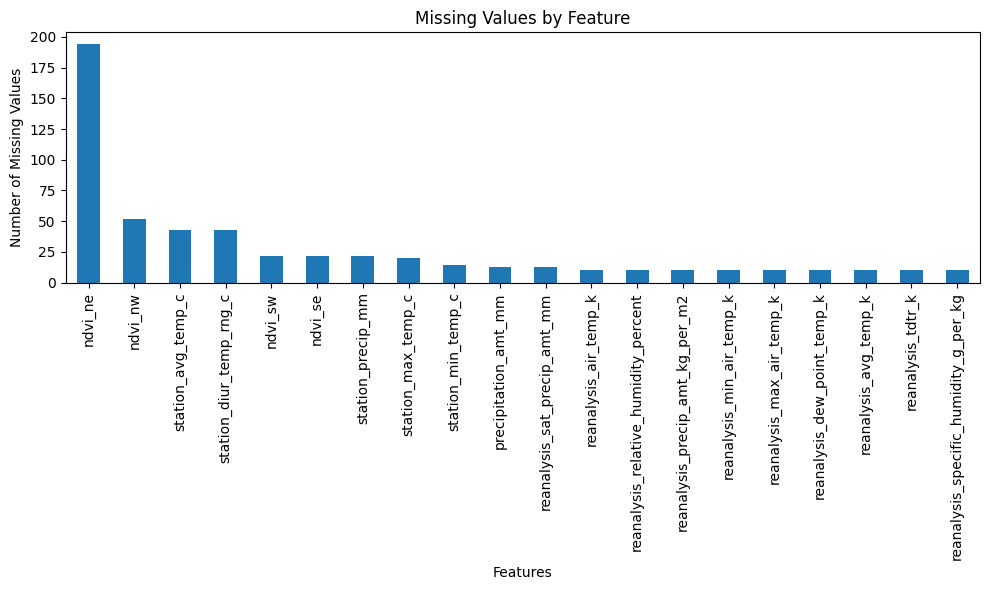

In [18]:
# Visualize missing values to better understand their distribution before imputation.
plt.figure(figsize=(10,6))

missing_summary["Missing Values"].plot(
    kind="bar"
)

plt.title("Missing Values by Feature")
plt.xlabel("Features")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=90)

plt.tight_layout()

plt.show()

#Missing Value Imputation

In [19]:
# Handle missing values while preserving temporal relationships within each city.

cleaned_data = master_data.copy()

# Select only numeric columns
numeric_columns = cleaned_data.select_dtypes(
    include=np.number
).columns

# Exclude target variable
numeric_columns = numeric_columns.drop("total_cases")

# Process each city independently
for city in cleaned_data["city"].unique():

    city_mask = cleaned_data["city"] == city

    cleaned_data.loc[
        city_mask,
        numeric_columns
    ] = (
        cleaned_data.loc[
            city_mask,
            numeric_columns
        ]
        .interpolate(method="linear")
        .ffill()
        .bfill()
    )

print("Missing values handled successfully.")

Missing values handled successfully.


#Verify Missing Values

In [20]:
remaining_missing = cleaned_data.isnull().sum()

remaining_missing = remaining_missing[
    remaining_missing > 0
]

print("REMAINING MISSING VALUES")

if remaining_missing.empty:
    print("All missing values have been successfully handled.")
else:
    display(remaining_missing)

REMAINING MISSING VALUES
All missing values have been successfully handled.


#Compare Before vs After

In [21]:
# Compare missing values before and after preprocessing.
comparison = pd.DataFrame({

    "Before":

        master_data.isnull().sum(),

    "After":

        cleaned_data.isnull().sum()

})

comparison = comparison[
    comparison["Before"] > 0
]

display(comparison)

,Before,After
ndvi_ne,194,0
ndvi_nw,52,0
ndvi_se,22,0
ndvi_sw,22,0
precipitation_amt_mm,13,0
reanalysis_air_temp_k,10,0
reanalysis_avg_temp_k,10,0
reanalysis_dew_point_temp_k,10,0
reanalysis_max_air_temp_k,10,0
reanalysis_min_air_temp_k,10,0


#Save the Cleaned Dataset

In [22]:
# Save the cleaned dataset for the next stages.
cleaned_dataset_path = os.path.join(
    PROJECT_PATH,
    "dengue_master_dataset_cleaned.csv"
)

cleaned_data.to_csv(
    cleaned_dataset_path,
    index=False
)

print("Cleaned dataset saved successfully.")
print(cleaned_dataset_path)

Cleaned dataset saved successfully.
/content/drive/MyDrive/Trustworthy_Disease_Outbreak_AI/dengue_master_dataset_cleaned.csv


#Unique Values for Categorical Features

In [23]:
# Check Unique Values in Categorical Features
print("UNIQUE VALUES")

print("City:", master_data["city"].unique())
print("\nNumber of Cities:", master_data["city"].nunique())

UNIQUE VALUES
City: ['iq' 'sj']

Number of Cities: 2


# Dataset Time Range

In [24]:
print("DATE RANGE")

print("Earliest Date :", master_data["week_start_date"].min())
print("Latest Date   :", master_data["week_start_date"].max())

DATE RANGE
Earliest Date : 1990-04-30 00:00:00
Latest Date   : 2010-06-25 00:00:00


# Target Variable Summary

In [25]:
print("TARGET VARIABLE SUMMARY")

display(master_data["total_cases"].describe())

TARGET VARIABLE SUMMARY


,total_cases
count,1456.000000
mean,24.675137
std,43.596000
min,0.000000
25%,5.000000
50%,12.000000
75%,28.000000
max,461.000000


#Verify Weekly Time Series Continuity/ Integrity

In [26]:
# Check whether each city has a continuous weekly time series.

print("TIME SERIES CONTINUITY CHECK")

for city in cleaned_data["city"].unique():

    city_data = cleaned_data[cleaned_data["city"] == city]

    print(f"\nCity: {city}")
    print(f"Records: {len(city_data)}")

    print("First Date :", city_data["week_start_date"].min())
    print("Last Date  :", city_data["week_start_date"].max())

TIME SERIES CONTINUITY CHECK

City: iq
Records: 520
First Date : 2000-07-01 00:00:00
Last Date  : 2010-06-25 00:00:00

City: sj
Records: 936
First Date : 1990-04-30 00:00:00
Last Date  : 2008-04-22 00:00:00


#Exploratory Data Analysis (EDA)

#Dataset Overview

In [27]:
# Provide a statistical summary of the cleaned dataset.

print("DATASET OVERVIEW")

print(f"Dataset Shape : {cleaned_data.shape}")
print(f"Number of Features : {cleaned_data.shape[1]}")
print(f"Number of Records : {len(cleaned_data)}")

print("\nData Types")
display(cleaned_data.dtypes)

print("\nStatistical Summary")
display(cleaned_data.describe())

DATASET OVERVIEW
Dataset Shape : (1456, 25)
Number of Features : 25
Number of Records : 1456

Data Types


,0
city,object
year,int64
weekofyear,int64
week_start_date,datetime64[ns]
ndvi_ne,float64
ndvi_nw,float64
ndvi_se,float64
ndvi_sw,float64
precipitation_amt_mm,float64
reanalysis_air_temp_k,float64



Statistical Summary


,year,weekofyear,week_start_date,ndvi_ne,ndvi_nw,ndvi_se,ndvi_sw,precipitation_amt_mm,reanalysis_air_temp_k,reanalysis_avg_temp_k,reanalysis_dew_point_temp_k,reanalysis_max_air_temp_k,reanalysis_min_air_temp_k,reanalysis_precip_amt_kg_per_m2,reanalysis_relative_humidity_percent,reanalysis_sat_precip_amt_mm,reanalysis_specific_humidity_g_per_kg,reanalysis_tdtr_k,station_avg_temp_c,station_diur_temp_rng_c,station_max_temp_c,station_min_temp_c,station_precip_mm,total_cases
count,1456.000000,1456.000000,1456,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000,1456.000000
mean,2001.031593,26.503434,2001-07-09 16:01:19.120879104,0.131490,0.127823,0.203130,0.201963,45.702091,298.697750,299.221723,295.244555,303.420158,295.718441,40.125594,82.173009,45.702091,16.744659,4.900618,27.181438,8.095505,32.446497,22.098043,39.362294,24.675137
min,1990.000000,1.000000,1990-04-30 00:00:00,-0.406250,-0.456100,-0.015533,-0.063457,0.000000,294.635714,294.892857,289.642857,297.800000,286.900000,0.000000,57.787143,0.000000,11.715714,1.357143,21.400000,4.528571,26.700000,14.700000,0.000000,0.000000
25%,1997.000000,13.750000,1997-04-28 06:00:00,0.037400,0.048092,0.154057,0.144455,9.785000,297.657857,298.257143,294.117857,301.000000,293.900000,13.200000,77.196429,9.785000,15.554643,2.328571,26.314286,6.528571,31.100000,21.100000,8.850000,5.000000
50%,2002.000000,26.500000,2002-05-28 00:00:00,0.115550,0.115926,0.195664,0.190121,38.320000,298.640000,299.285714,295.638571,302.400000,296.200000,27.300000,80.287857,38.320000,17.084286,2.857143,27.400000,7.350000,32.800000,22.200000,24.050000,12.000000
75%,2005.000000,39.250000,2005-11-26 00:00:00,0.231443,0.213429,0.247461,0.246579,70.227500,299.827500,300.207143,296.457857,305.500000,297.900000,52.200000,86.437500,70.227500,17.976071,7.632143,28.130804,9.603571,33.900000,23.300000,53.900000,28.000000
max,2010.000000,53.000000,2010-06-25 00:00:00,0.508357,0.454429,0.538314,0.546017,390.600000,302.200000,302.928571,298.450000,314.000000,299.900000,570.500000,98.610000,390.600000,20.461429,16.028571,30.800000,15.800000,42.200000,25.600000,543.300000,461.000000
std,5.408314,15.019437,NaN,0.137272,0.119478,0.073781,0.083491,43.651356,1.359878,1.260384,1.525955,3.233153,2.559010,43.313117,7.152190,43.651356,1.540958,3.542762,1.281116,2.127521,1.959090,1.570524,47.285701,43.596000


#Distribution of Dengue Cases
Research Question: Is the target variable highly skewed, making uncertainty estimation important?

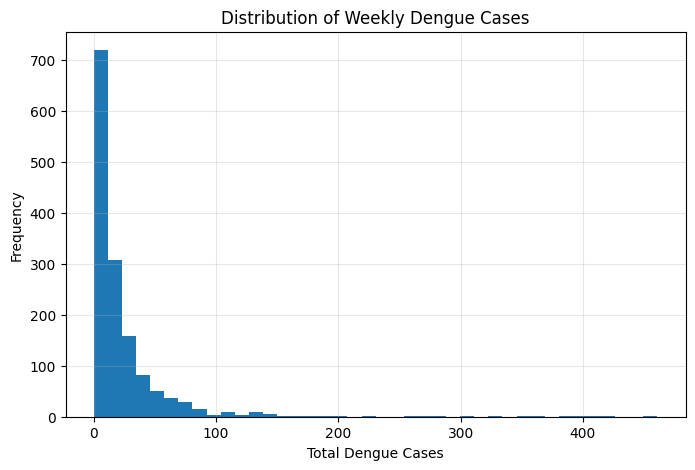

count    1456.000000
mean       24.675137
std        43.596000
min         0.000000
25%         5.000000
50%        12.000000
75%        28.000000
max       461.000000
Name: total_cases, dtype: float64


In [28]:
plt.figure(figsize=(8,5))

plt.hist(
    cleaned_data["total_cases"],
    bins=40
)

plt.title("Distribution of Weekly Dengue Cases")
plt.xlabel("Total Dengue Cases")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.show()

print(cleaned_data["total_cases"].describe())

#Weekly Outbreak Trends
Research Question: How have dengue outbreaks varied over time?

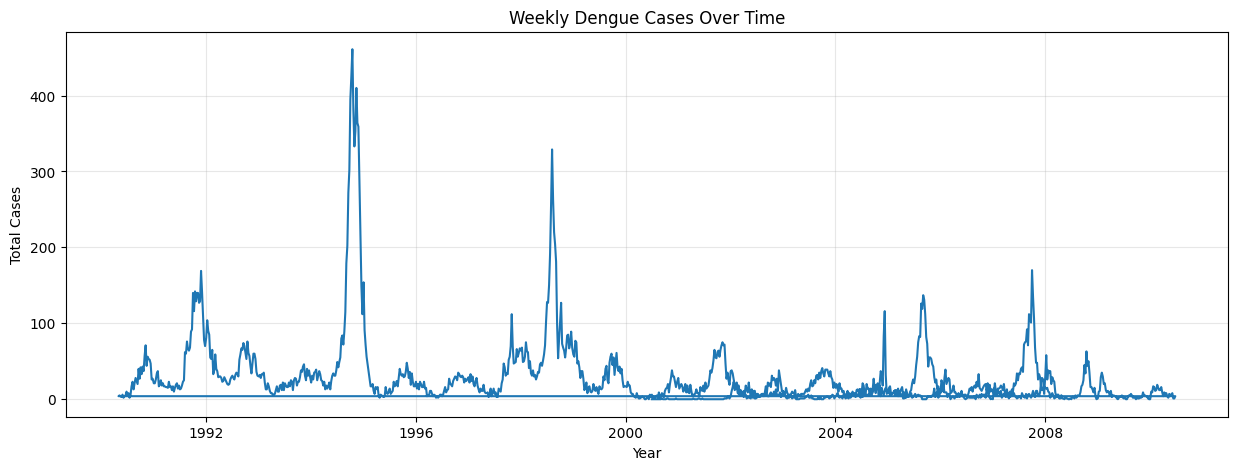

In [29]:
# How have dengue cases changed over time?

plt.figure(figsize=(15,5))

plt.plot(
    cleaned_data["week_start_date"],
    cleaned_data["total_cases"]
)

plt.title("Weekly Dengue Cases Over Time")

plt.xlabel("Year")

plt.ylabel("Total Cases")

plt.grid(alpha=0.3)

plt.show()

#Compare Cities
Research Question: Do the two cities exhibit different outbreak dynamics?

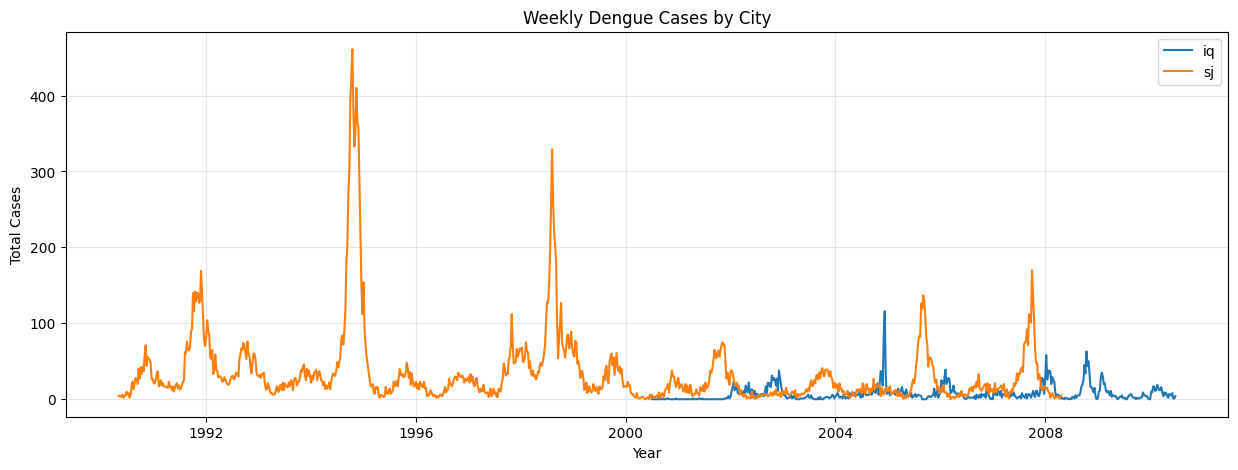

In [30]:
plt.figure(figsize=(15,5))

for city in cleaned_data["city"].unique():

    city_data = cleaned_data[
        cleaned_data["city"] == city
    ]

    plt.plot(
        city_data["week_start_date"],
        city_data["total_cases"],
        label=city
    )

plt.title("Weekly Dengue Cases by City")

plt.xlabel("Year")

plt.ylabel("Total Cases")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

#Correlation Heatmap
Research Question: Which environmental variables appear related to dengue incidence?

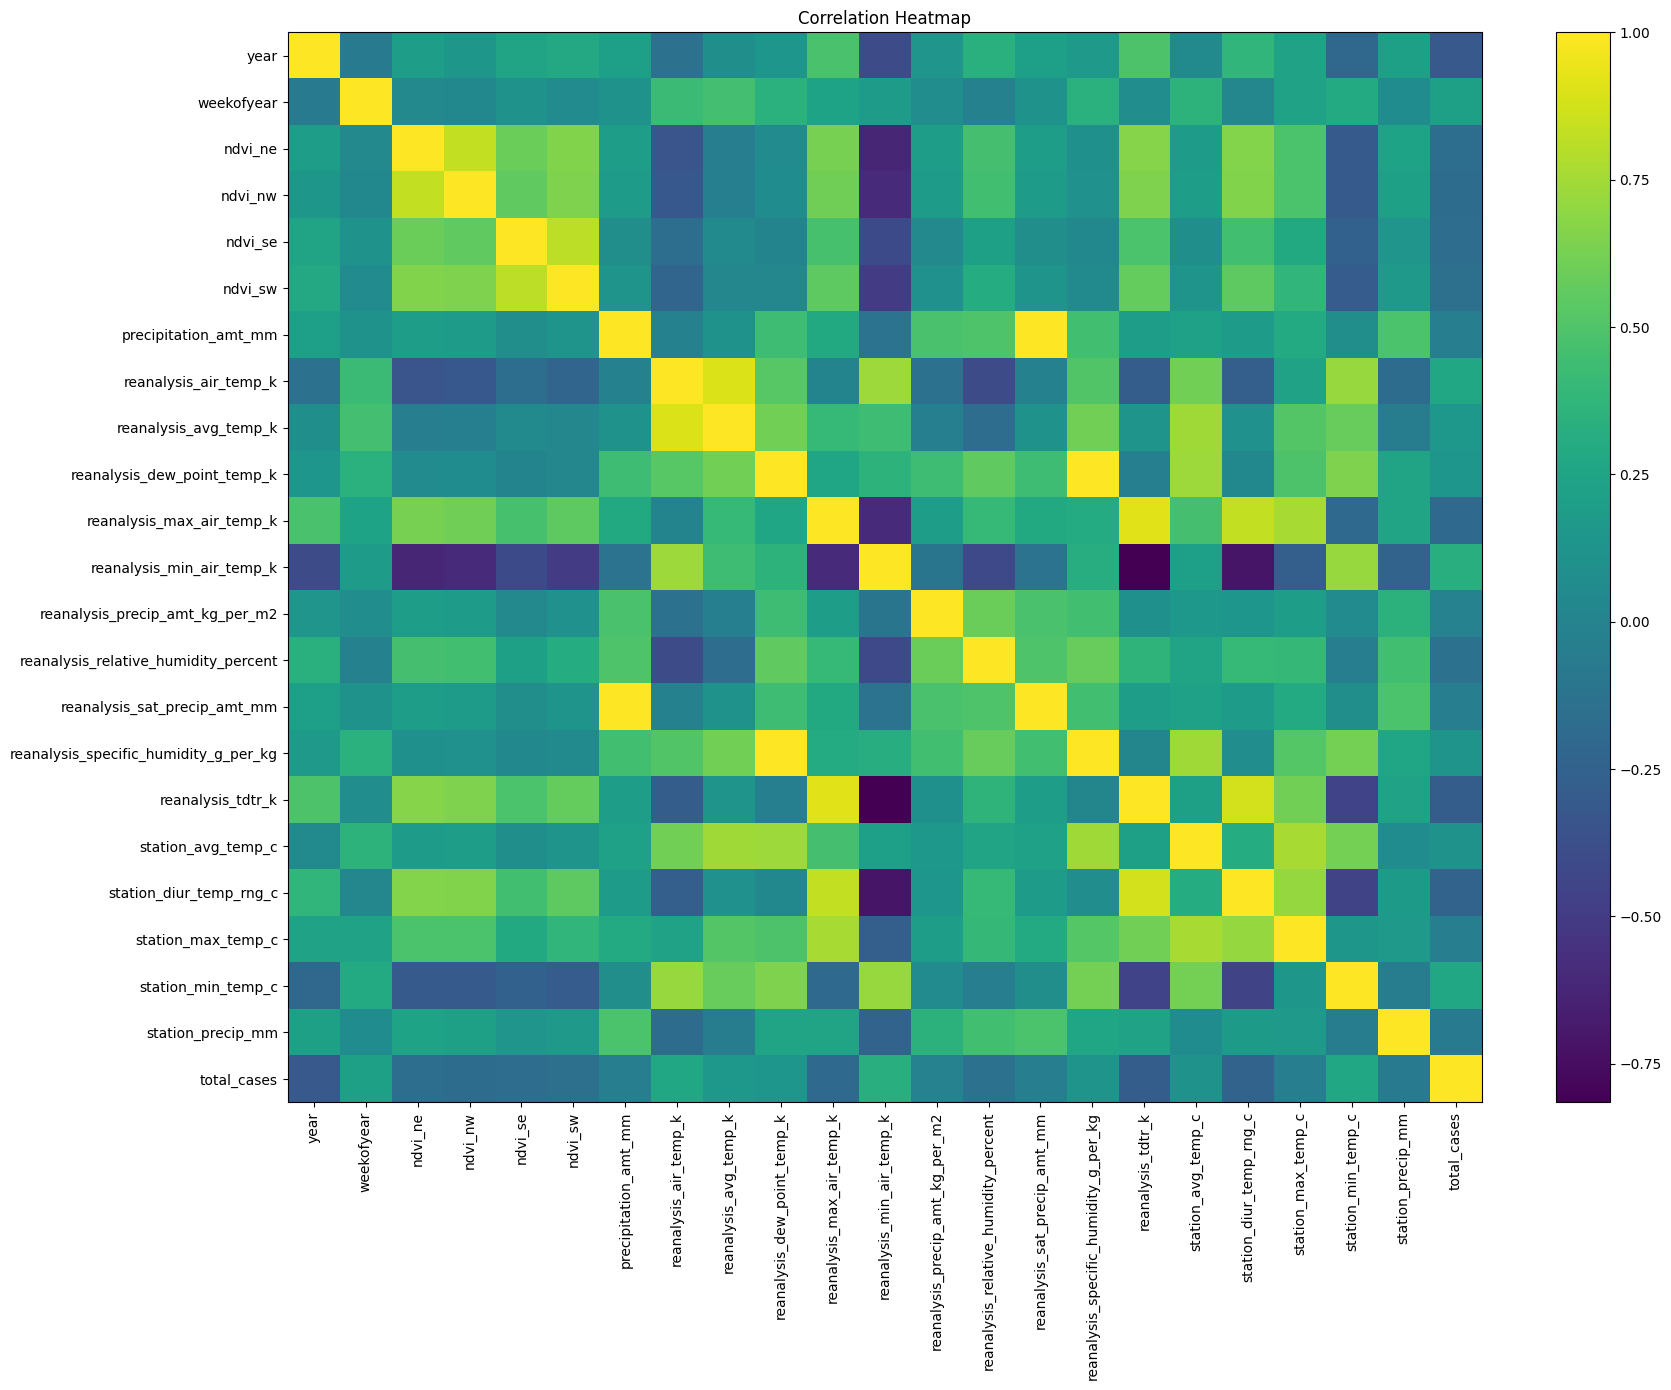

In [31]:
numeric_data = cleaned_data.select_dtypes(include="number")

correlation = numeric_data.corr()

plt.figure(figsize=(18,14))

plt.imshow(correlation, aspect="auto")

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.show()

#Weather Feature Distributions
Research Question: What are the distributions of key weather variables?

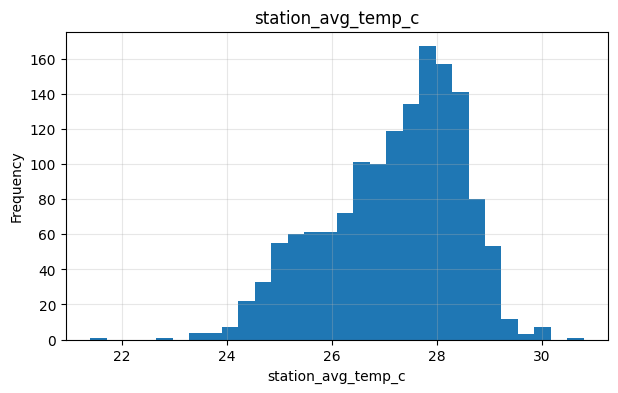

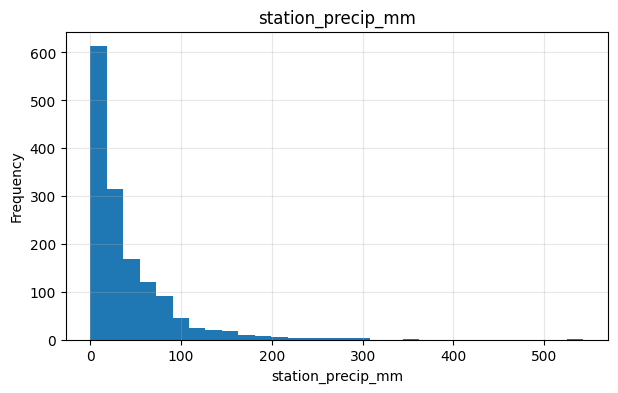

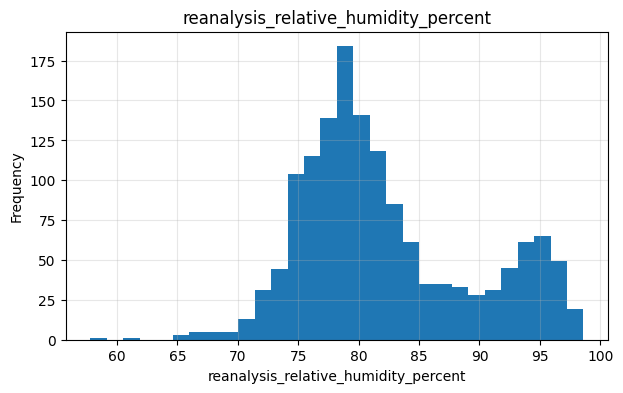

In [32]:
# How are the major environmental variables distributed?

weather_features = [

    "station_avg_temp_c",

    "station_precip_mm",

    "reanalysis_relative_humidity_percent"

]

for feature in weather_features:

    plt.figure(figsize=(7,4))

    plt.hist(
        cleaned_data[feature],
        bins=30
    )

    plt.title(feature)

    plt.xlabel(feature)

    plt.ylabel("Frequency")

    plt.grid(alpha=0.3)

    plt.show()

#Outlier Analysis

Research Question: Are extreme outbreak weeks genuine events or errors?

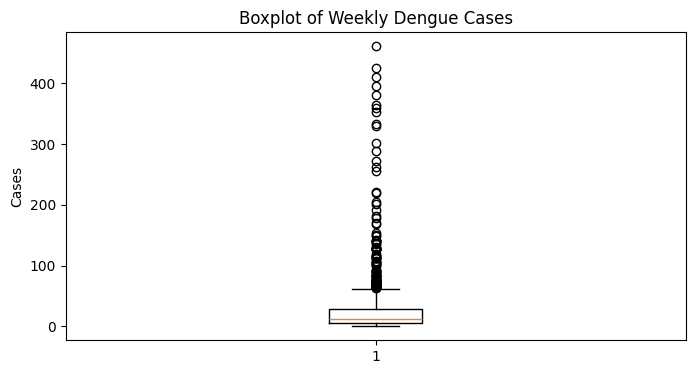

In [33]:
plt.figure(figsize=(8,4))

plt.boxplot(cleaned_data["total_cases"])

plt.title("Boxplot of Weekly Dengue Cases")

plt.ylabel("Cases")

plt.show()

#Monthly Seasonality

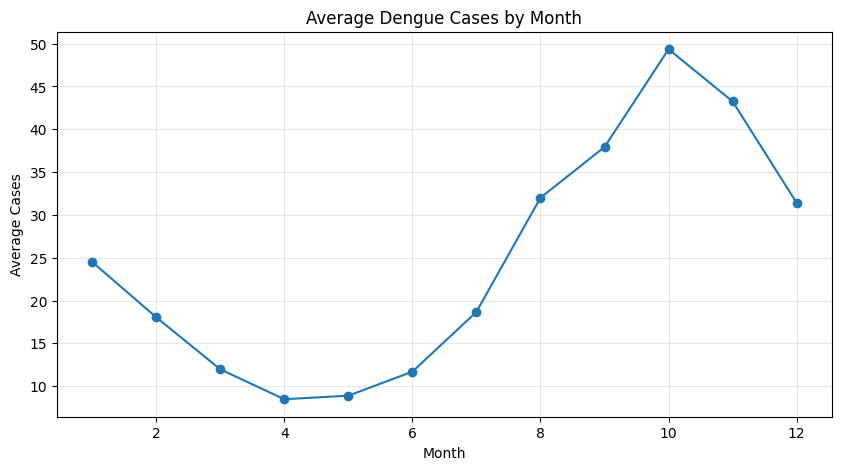

In [34]:
# Does dengue exhibit seasonal patterns?
season_data = cleaned_data.copy()

season_data["month"] = season_data["week_start_date"].dt.month

monthly_cases = season_data.groupby("month")["total_cases"].mean()

plt.figure(figsize=(10,5))

plt.plot(
    monthly_cases.index,
    monthly_cases.values,
    marker="o"
)

plt.title("Average Dengue Cases by Month")

plt.xlabel("Month")

plt.ylabel("Average Cases")

plt.grid(alpha=0.3)

plt.show()

# Time-Based Train/Validation/Test Split

In [35]:
# Split the cleaned dataset chronologically for each city while preserving temporal order.
train_sets = []
validation_sets = []
test_sets = []

for city in cleaned_data["city"].unique():

    city_data = (
        cleaned_data[cleaned_data["city"] == city]
        .sort_values("week_start_date")
        .reset_index(drop=True)
    )

    total_records = len(city_data)

    train_end = int(total_records * 0.70)
    validation_end = int(total_records * 0.85)

    train_sets.append(city_data.iloc[:train_end])

    validation_sets.append(
        city_data.iloc[train_end:validation_end]
    )

    test_sets.append(
        city_data.iloc[validation_end:]
    )

train_df = pd.concat(train_sets).reset_index(drop=True)
validation_df = pd.concat(validation_sets).reset_index(drop=True)
test_df = pd.concat(test_sets).reset_index(drop=True)

print("TIME-BASED DATA SPLIT")

print(f"Training Records   : {len(train_df)}")
print(f"Validation Records : {len(validation_df)}")
print(f"Testing Records    : {len(test_df)}")

TIME-BASED DATA SPLIT
Training Records   : 1019
Validation Records : 218
Testing Records    : 219


# Verify Temporal Integrity

In [36]:
#  Verify Chronological Order
for city in cleaned_data["city"].unique():

    print(f"CITY : {city}")

    train_city = train_df[train_df.city == city]
    validation_city = validation_df[validation_df.city == city]
    test_city = test_df[test_df.city == city]

    print("TRAIN")
    print(train_city.week_start_date.min())
    print(train_city.week_start_date.max())

    print()

    print("VALIDATION")
    print(validation_city.week_start_date.min())
    print(validation_city.week_start_date.max())

    print()

    print("TEST")
    print(test_city.week_start_date.min())
    print(test_city.week_start_date.max())

    print()

CITY : iq
TRAIN
2000-07-01 00:00:00
2007-06-25 00:00:00

VALIDATION
2007-07-02 00:00:00
2008-12-23 00:00:00

TEST
2009-01-01 00:00:00
2010-06-25 00:00:00

CITY : sj
TRAIN
1990-04-30 00:00:00
2002-11-26 00:00:00

VALIDATION
2002-12-03 00:00:00
2005-08-06 00:00:00

TEST
2005-08-13 00:00:00
2008-04-22 00:00:00



#Feature Engneering

# Create Working Copies

In [37]:
# Create independent datasets for feature engineering while preserving the original train, validation, and test sets.
train_fe = train_df.copy()
validation_fe = validation_df.copy()
test_fe = test_df.copy()

print("WORKING COPIES CREATED")

print("Training      :", train_fe.shape)
print("Validation    :", validation_fe.shape)
print("Testing       :", test_fe.shape)

WORKING COPIES CREATED
Training      : (1019, 25)
Validation    : (218, 25)
Testing       : (219, 25)


#Encode City

In [38]:
# Convert the categorical city feature into numerical form.
city_mapping = {
    "sj": 0,
    "iq": 1
}

for dataset in [train_fe, validation_fe, test_fe]:

    dataset["city_encoded"] = dataset["city"].map(city_mapping)

print("CITY ENCODING COMPLETED")

display(train_fe[["city", "city_encoded"]].drop_duplicates())

CITY ENCODING COMPLETED


,city,city_encoded
0,iq,1
364,sj,0


#Time/ Temporal Features

In [39]:
for dataset in [train_fe, validation_fe, test_fe]:

    dataset["year_num"] = dataset["week_start_date"].dt.year

    dataset["month"] = dataset["week_start_date"].dt.month

    dataset["week"] = (
        dataset["week_start_date"]
        .dt.isocalendar()
        .week
        .astype(int)
    )

    dataset["quarter"] = (
        dataset["week_start_date"]
        .dt.quarter
    )

print("TEMPORAL FEATURES CREATED")

TEMPORAL FEATURES CREATED


#Cyclical Encoding

In [40]:
# Months are cyclical: December-> January
# Not: December-> End
#Using sine and cosine preserves this circular nature.

for dataset in [train_fe, validation_fe, test_fe]:

    dataset["month_sin"] = np.sin(
        2*np.pi*dataset["month"]/12
    )

    dataset["month_cos"] = np.cos(
        2*np.pi*dataset["month"]/12
    )

    dataset["week_sin"] = np.sin(
        2*np.pi*dataset["week"]/52
    )

    dataset["week_cos"] = np.cos(
        2*np.pi*dataset["week"]/52
    )

print("Cyclical features added.")

Cyclical features added.


# Lag Features

In [41]:
# Disease outbreaks depend heavily on previous weeks. We'll create lag features within each city to avoid mixing the two time series.
lag_periods = [1, 2, 4, 8]

for dataset in [train_fe, validation_fe, test_fe]:

    for lag in lag_periods:

        dataset[f"lag_{lag}"] = (
            dataset
            .groupby("city")["total_cases"]
            .shift(lag)
        )

print("LAG FEATURES CREATED")
print(f"Lag Features: {lag_periods}")

LAG FEATURES CREATED
Lag Features: [1, 2, 4, 8]


# Rolling Statistics

In [42]:
# These capture short-term trends.
for dataset in [train_fe, validation_fe, test_fe]:

    dataset["rolling_mean_4"] = (

        dataset.groupby("city")["total_cases"]

        .transform(lambda x: x.rolling(4).mean())

    )

    dataset["rolling_std_4"] = (

        dataset.groupby("city")["total_cases"]

        .transform(lambda x: x.rolling(4).std())

    )

    dataset["rolling_max_4"] = (

        dataset.groupby("city")["total_cases"]

        .transform(lambda x: x.rolling(4).max())

    )

print("Rolling statistics created.")

Rolling statistics created.


# Weather Change Features

In [43]:
# Instead of absolute values, measure changes from the previous week.
weather_features = [

    "station_avg_temp_c",

    "station_precip_mm",

    "reanalysis_relative_humidity_percent"

]

for dataset in [train_fe, validation_fe, test_fe]:

    for feature in weather_features:

        dataset[f"{feature}_change"] = (

            dataset.groupby("city")[feature]

            .diff()

        )

print("Weather change features created.")

Weather change features created.


#Rolling Minimum

In [44]:
# Disease outbreaks often remain low before suddenly increasing.
for dataset in [train_fe, validation_fe, test_fe]:

    dataset["rolling_min_4"] = (

        dataset.groupby("city")["total_cases"]

        .transform(lambda x: x.rolling(4).min())

    )

print("Rolling minimum created.")

Rolling minimum created.


#Rolling Median

In [45]:
# Median is more robust than the mean when outbreaks are extreme.
for dataset in [train_fe, validation_fe, test_fe]:

    dataset["rolling_median_4"] = (

        dataset.groupby("city")["total_cases"]

        .transform(lambda x: x.rolling(4).median())

    )

print("Rolling median created.")

Rolling median created.


#Expanding Mean

In [46]:
# This tells the model: How severe has this city been historically up to the current week?
for dataset in [train_fe, validation_fe, test_fe]:

    dataset["historical_mean_cases"] = (

        dataset.groupby("city")["total_cases"]

        .transform(lambda x: x.expanding().mean())

    )

print("Historical mean created.")

Historical mean created.


#Rainfall Accumulation

In [47]:
# Mosquito breeding depends on rainfall over several weeks, not just one week.
for dataset in [train_fe, validation_fe, test_fe]:

    dataset["rainfall_4week_sum"] = (

        dataset.groupby("city")["station_precip_mm"]

        .transform(lambda x: x.rolling(4).sum())

    )

    dataset["rainfall_8week_sum"] = (

        dataset.groupby("city")["station_precip_mm"]

        .transform(lambda x: x.rolling(8).sum())

    )

print("Rainfall accumulation created.")

Rainfall accumulation created.


#Temperature Trend

In [48]:
# Instead of using temperature alone, measure whether it's increasing or decreasing.
for dataset in [train_fe, validation_fe, test_fe]:

    dataset["temperature_trend"] = (

        dataset.groupby("city")["station_avg_temp_c"]

        .diff()

    )

print("Temperature trend created.")

Temperature trend created.


#Humidity Trend

In [49]:
for dataset in [train_fe, validation_fe, test_fe]:

    dataset["humidity_trend"] = (

        dataset.groupby("city")[
            "reanalysis_relative_humidity_percent"
        ]

        .diff()

    )

print("Humidity trend created.")

Humidity trend created.


#Consecutive Outbreak Increase

In [50]:
for dataset in [train_fe, validation_fe, test_fe]:

    change = (

        dataset.groupby("city")["total_cases"]

        .diff()

    )

    dataset["case_increase"] = (

        change > 0

    ).astype(int)

print("Consecutive increase feature created.")

Consecutive increase feature created.


#Verify Missing Values After Feature Engineering

In [51]:
# Examine missing values introduced by lag features, rolling statistics, and temporal difference operations before removing incomplete observations.
print("MISSING VALUES AFTER FEATURE ENGINEERING")

for name, dataset in [

    ("Training", train_fe),

    ("Validation", validation_fe),

    ("Testing", test_fe)

]:

    print(f"\n{name} Dataset")

    missing_values = dataset.isnull().sum()
    missing_values = missing_values[missing_values > 0]

    if missing_values.empty:
        print("No missing values found.")
    else:
        print(missing_values)

MISSING VALUES AFTER FEATURE ENGINEERING

Training Dataset
lag_1                                           2
lag_2                                           4
lag_4                                           8
lag_8                                          16
rolling_mean_4                                  6
rolling_std_4                                   6
rolling_max_4                                   6
station_avg_temp_c_change                       2
station_precip_mm_change                        2
reanalysis_relative_humidity_percent_change     2
rolling_min_4                                   6
rolling_median_4                                6
rainfall_4week_sum                              6
rainfall_8week_sum                             14
temperature_trend                               2
humidity_trend                                  2
dtype: int64

Validation Dataset
lag_1                                           2
lag_2                                           4
lag_4   

#Remove Rows with Missing Lag Values

In [52]:
print("ROW REMOVAL SUMMARY")

for name, dataset in [

    ("Training", train_fe),

    ("Validation", validation_fe),

    ("Testing", test_fe)

]:

    before = len(dataset)

    dataset.dropna(inplace=True)

    dataset.reset_index(drop=True, inplace=True)

    after = len(dataset)

    print(f"{name}: {before} -> {after} (Removed {before-after})")

ROW REMOVAL SUMMARY
Training: 1019 -> 1003 (Removed 16)
Validation: 218 -> 202 (Removed 16)
Testing: 219 -> 203 (Removed 16)


# Verify Engineered Dataset

In [53]:
print("FINAL ENGINEERED DATASET")

print("Training      :", train_fe.shape)
print("Validation    :", validation_fe.shape)
print("Testing       :", test_fe.shape)

print("\nTraining Sample")

display(train_fe.head())

FINAL ENGINEERED DATASET
Training      : (1003, 52)
Validation    : (202, 52)
Testing       : (203, 52)

Training Sample


,city,year,weekofyear,week_start_date,ndvi_ne,ndvi_nw,ndvi_se,ndvi_sw,precipitation_amt_mm,reanalysis_air_temp_k,reanalysis_avg_temp_k,reanalysis_dew_point_temp_k,reanalysis_max_air_temp_k,reanalysis_min_air_temp_k,reanalysis_precip_amt_kg_per_m2,reanalysis_relative_humidity_percent,reanalysis_sat_precip_amt_mm,reanalysis_specific_humidity_g_per_kg,reanalysis_tdtr_k,station_avg_temp_c,station_diur_temp_rng_c,station_max_temp_c,station_min_temp_c,station_precip_mm,total_cases,city_encoded,year_num,month,week,quarter,month_sin,month_cos,week_sin,week_cos,lag_1,lag_2,lag_4,lag_8,rolling_mean_4,rolling_std_4,rolling_max_4,station_avg_temp_c_change,station_precip_mm_change,reanalysis_relative_humidity_percent_change,rolling_min_4,rolling_median_4,historical_mean_cases,rainfall_4week_sum,rainfall_8week_sum,temperature_trend,humidity_trend,case_increase
0,iq,2000,34,2000-08-26,0.408157,0.322157,0.406714,0.302714,49.22,298.238571,299.571429,292.904286,310.1,291.3,5.59,74.740000,49.22,14.444286,13.771429,26.900000,13.400000,34.0,19.0,89.2,0,1,2000,8,34,3,-0.866025,-5.000000e-01,-0.822984,-0.568065,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.316667,39.1,-7.750000,0.0,0.0,0.000000,223.7,351.4,0.316667,-7.750000,0
1,iq,2000,35,2000-09-02,0.332043,0.321057,0.314614,0.324257,53.65,299.218571,300.928571,293.472857,310.5,292.9,16.07,74.151429,53.65,15.057143,12.457143,27.116667,12.266667,34.0,20.0,78.0,0,1,2000,9,35,3,-1.000000,-1.836970e-16,-0.885456,-0.464723,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.216667,-11.2,-0.588571,0.0,0.0,0.000000,290.2,373.8,0.216667,-0.588571,0
2,iq,2000,36,2000-09-09,0.295586,0.295683,0.312214,0.265929,23.12,300.802857,301.935714,290.635714,312.8,291.5,2.50,57.787143,23.12,12.652857,14.900000,28.366667,12.900000,35.8,21.7,56.9,1,1,2000,9,36,3,-1.000000,-1.836970e-16,-0.935016,-0.354605,0.0,0.0,0.0,0.0,0.25,0.5,1.0,1.250000,-21.1,-16.364286,0.0,0.0,0.090909,274.2,392.6,1.250000,-16.364286,1
3,iq,2000,37,2000-09-16,0.284657,0.309757,0.387883,0.328157,34.62,299.858571,301.371429,293.640000,310.7,292.3,4.10,71.660000,34.62,15.227143,13.857143,27.425000,12.775000,34.5,20.5,18.9,0,1,2000,9,37,3,-1.000000,-1.836970e-16,-0.970942,-0.239316,1.0,0.0,0.0,0.0,0.25,0.5,1.0,-0.941667,-38.0,13.872857,0.0,0.0,0.083333,243.0,381.5,-0.941667,13.872857,0
4,iq,2000,38,2000-09-23,0.348814,0.295717,0.404843,0.242571,97.55,297.435714,298.514286,292.707143,310.2,288.3,3.20,77.487143,97.55,14.338571,11.314286,27.533333,12.566667,36.0,20.5,104.2,0,1,2000,9,38,3,-1.000000,-1.836970e-16,-0.992709,-0.120537,0.0,1.0,0.0,0.0,0.25,0.5,1.0,0.108333,85.3,5.827143,0.0,0.0,0.076923,258.0,481.7,0.108333,5.827143,0


#Save the Feature Engineered Dataset

In [54]:
# Save the feature-engineered training, validation, and testing datasets for reproducibility and future use.

# Create output directory if it does not exist
processed_path = os.path.join(PROJECT_PATH, "processed_data")
os.makedirs(processed_path, exist_ok=True)

# Save datasets
train_fe.to_csv(
    os.path.join(processed_path, "train_feature_engineered.csv"),
    index=False
)

validation_fe.to_csv(
    os.path.join(processed_path, "validation_feature_engineered.csv"),
    index=False
)

test_fe.to_csv(
    os.path.join(processed_path, "test_feature_engineered.csv"),
    index=False
)

print("=" * 70)
print("FEATURE ENGINEERED DATASETS SAVED SUCCESSFULLY")
print("=" * 70)

print(f"Training Dataset   : {os.path.join(processed_path, 'train_feature_engineered.csv')}")
print(f"Validation Dataset : {os.path.join(processed_path, 'validation_feature_engineered.csv')}")
print(f"Testing Dataset    : {os.path.join(processed_path, 'test_feature_engineered.csv')}")

FEATURE ENGINEERED DATASETS SAVED SUCCESSFULLY
Training Dataset   : /content/drive/MyDrive/Trustworthy_Disease_Outbreak_AI/processed_data/train_feature_engineered.csv
Validation Dataset : /content/drive/MyDrive/Trustworthy_Disease_Outbreak_AI/processed_data/validation_feature_engineered.csv
Testing Dataset    : /content/drive/MyDrive/Trustworthy_Disease_Outbreak_AI/processed_data/test_feature_engineered.csv


#Install Required Library

In [55]:
!pip install pytorch-lightning
!pip install pytorch-forecasting

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.3/425.3 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.3/849.3 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.3/165.3 kB 8.5 MB/s eta 0:00:00


# Load Feature Engineered Data

In [56]:
train_fe = pd.read_csv(
    os.path.join(processed_path, "train_feature_engineered.csv"),
    parse_dates=["week_start_date"]
)

validation_fe = pd.read_csv(
    os.path.join(processed_path, "validation_feature_engineered.csv"),
    parse_dates=["week_start_date"]
)

test_fe = pd.read_csv(
    os.path.join(processed_path, "test_feature_engineered.csv"),
    parse_dates=["week_start_date"]
)

print("Datasets loaded successfully.")

Datasets loaded successfully.


# Create Continuous Time Index

In [57]:
# Training Dataset
train_fe = (
    train_fe
    .sort_values(["city", "week_start_date"])
    .reset_index(drop=True)
)

train_fe["time_idx"] = (
    train_fe.groupby("city").cumcount()
)

# Validation Dataset

validation_fe = (
    validation_fe
    .sort_values(["city", "week_start_date"])
    .reset_index(drop=True)
)

validation_fe["time_idx"] = (
    validation_fe.groupby("city").cumcount()
)

# Testing Dataset

test_fe = (
    test_fe
    .sort_values(["city", "week_start_date"])
    .reset_index(drop=True)
)

test_fe["time_idx"] = (
    test_fe.groupby("city").cumcount()
)

print("TIME INDEX CREATED SUCCESSFULLY")

print("\nTraining Dataset")
display(
    train_fe[
        ["city", "week_start_date", "time_idx"]
    ].head(10)
)

TIME INDEX CREATED SUCCESSFULLY

Training Dataset


,city,week_start_date,time_idx
0,iq,2000-08-26,0
1,iq,2000-09-02,1
2,iq,2000-09-09,2
3,iq,2000-09-16,3
4,iq,2000-09-23,4
5,iq,2000-09-30,5
6,iq,2000-10-07,6
7,iq,2000-10-14,7
8,iq,2000-10-21,8
9,iq,2000-10-28,9


# Verify Time Index

In [58]:
print("TIME INDEX SUMMARY")

for name, dataset in [

    ("Training", train_fe),

    ("Validation", validation_fe),

    ("Testing", test_fe)

]:

    print(f"\n{name}")

    print("Minimum time_idx :", dataset["time_idx"].min())

    print("Maximum time_idx :", dataset["time_idx"].max())

    print("Total Records    :", len(dataset))

TIME INDEX SUMMARY

Training
Minimum time_idx : 0
Maximum time_idx : 646
Total Records    : 1003

Validation
Minimum time_idx : 0
Maximum time_idx : 131
Total Records    : 202

Testing
Minimum time_idx : 0
Maximum time_idx : 132
Total Records    : 203


#Create Continuous Time Index Across Splits

In [59]:
for city in train_fe["city"].unique():

    # Training
    train_mask = train_fe["city"] == city

    train_fe.loc[train_mask, "time_idx"] = range(
        len(train_fe[train_mask])
    )

    # Validation
    validation_mask = validation_fe["city"] == city

    validation_fe.loc[
        validation_mask,
        "time_idx"
    ] = range(

        len(train_fe[train_mask]),

        len(train_fe[train_mask]) +
        len(validation_fe[validation_mask])

    )

    # Testing
    test_mask = test_fe["city"] == city

    test_fe.loc[
        test_mask,
        "time_idx"
    ] = range(

        len(train_fe[train_mask]) +
        len(validation_fe[validation_mask]),

        len(train_fe[train_mask]) +
        len(validation_fe[validation_mask]) +
        len(test_fe[test_mask])

    )

print("Continuous time index created successfully.")

Continuous time index created successfully.


#Verify the New Time Index

In [60]:
# Verify Continuous Time Index

for name, dataset in [

    ("Training", train_fe),

    ("Validation", validation_fe),

    ("Testing", test_fe)

]:

    print()
    print(name)

    for city in dataset["city"].unique():

        city_data = dataset[dataset["city"] == city]

        print(

            city,

            city_data["time_idx"].min(),

            "->",

            city_data["time_idx"].max()

        )



Training
iq 0 -> 355
sj 0 -> 646

Validation
iq 356 -> 425
sj 647 -> 778

Testing
iq 426 -> 495
sj 779 -> 911


#Remove Redundant Features

In [61]:
# Remove redundant features that are not required for the Temporal Fusion Transformer (TFT).

# - 'city_encoded' is removed because TFT automatically learns embeddings from the categorical 'city' feature.
# - 'year' is removed because the engineered feature'year_num' provides the required numerical representation.
# - 'weekofyear' is removed because the engineered feature 'week' contains the same temporal information.

# Note:
# The 'week_start_date' column is retained for visualization, forecasting timelines, and reporting, but it will not be used as a model input.

datasets = {
    "Training": train_fe,
    "Validation": validation_fe,
    "Testing": test_fe
}

columns_to_remove = [
    "city_encoded",
    "year",
    "weekofyear"
]

for name, dataset in datasets.items():

    existing_columns = [
        column for column in columns_to_remove
        if column in dataset.columns
    ]

    dataset.drop(columns=existing_columns, inplace=True)

    print(f" {name}: Removed {existing_columns}")

print("\nRedundant feature removal completed successfully.")

 Training: Removed ['city_encoded', 'year', 'weekofyear']
 Validation: Removed ['city_encoded', 'year', 'weekofyear']
 Testing: Removed ['city_encoded', 'year', 'weekofyear']

Redundant feature removal completed successfully.


# Inspect Final Dataset Columns


In [62]:
# Verify the final feature set after removing redundant columns and before preparing the TFT inputs.

print("FINAL FEATURE SET")
print("TRAINING DATASET COLUMNS")


for i, column in enumerate(train_fe.columns, start=1):
    print(f"{i:2d}. {column}")

FINAL FEATURE SET
TRAINING DATASET COLUMNS
 1. city
 2. week_start_date
 3. ndvi_ne
 4. ndvi_nw
 5. ndvi_se
 6. ndvi_sw
 7. precipitation_amt_mm
 8. reanalysis_air_temp_k
 9. reanalysis_avg_temp_k
10. reanalysis_dew_point_temp_k
11. reanalysis_max_air_temp_k
12. reanalysis_min_air_temp_k
13. reanalysis_precip_amt_kg_per_m2
14. reanalysis_relative_humidity_percent
15. reanalysis_sat_precip_amt_mm
16. reanalysis_specific_humidity_g_per_kg
17. reanalysis_tdtr_k
18. station_avg_temp_c
19. station_diur_temp_rng_c
20. station_max_temp_c
21. station_min_temp_c
22. station_precip_mm
23. total_cases
24. year_num
25. month
26. week
27. quarter
28. month_sin
29. month_cos
30. week_sin
31. week_cos
32. lag_1
33. lag_2
34. lag_4
35. lag_8
36. rolling_mean_4
37. rolling_std_4
38. rolling_max_4
39. station_avg_temp_c_change
40. station_precip_mm_change
41. reanalysis_relative_humidity_percent_change
42. rolling_min_4
43. rolling_median_4
44. historical_mean_cases
45. rainfall_4week_sum
46. rainfall_8

#Define TFT Variables

#Define Target Variable

In [63]:
# Specify the prediction target for disease outbreak forecasting.
TARGET = "total_cases"

print("TARGET VARIABLE")
print(TARGET)

TARGET VARIABLE
total_cases


#Define Group Identifier

In [64]:
#TFT learns multiple time series simultaneously.
#Here we have: San Juan, Iquitos

GROUP_IDS = ["city"]

print("GROUP IDENTIFIER")

print(GROUP_IDS)

GROUP IDENTIFIER
['city']


# Define Static Features

In [65]:
#We'll keep only "city" because TFT internally embeds categorical variables.

STATIC_CATEGORICALS = [

    "city"

]

STATIC_REALS = [

]

print("STATIC FEATURES")

print("Static Categoricals :", STATIC_CATEGORICALS)

print("Static Reals :", STATIC_REALS)

STATIC FEATURES
Static Categoricals : ['city']
Static Reals : []


# Time-Varying Known Features

In [66]:
TIME_VARYING_KNOWN_CATEGORICALS = [

]

TIME_VARYING_KNOWN_REALS = [

    "time_idx",

    "year_num",

    "month",

    "week",

    "quarter",

    "month_sin",

    "month_cos",

    "week_sin",

    "week_cos"

]

print("KNOWN FEATURES")

print(TIME_VARYING_KNOWN_REALS)

KNOWN FEATURES
['time_idx', 'year_num', 'month', 'week', 'quarter', 'month_sin', 'month_cos', 'week_sin', 'week_cos']


# Time-Varying Unknown Features

In [67]:
TIME_VARYING_UNKNOWN_REALS = [

    TARGET,

    "ndvi_ne",

    "ndvi_nw",

    "ndvi_se",

    "ndvi_sw",

    "precipitation_amt_mm",

    "reanalysis_air_temp_k",

    "reanalysis_avg_temp_k",

    "reanalysis_dew_point_temp_k",

    "reanalysis_max_air_temp_k",

    "reanalysis_min_air_temp_k",

    "reanalysis_precip_amt_kg_per_m2",

    "reanalysis_relative_humidity_percent",

    "reanalysis_sat_precip_amt_mm",

    "reanalysis_specific_humidity_g_per_kg",

    "reanalysis_tdtr_k",

    "station_avg_temp_c",

    "station_diur_temp_rng_c",

    "station_max_temp_c",

    "station_min_temp_c",

    "station_precip_mm",

    "lag_1",

    "lag_2",

    "lag_4",

    "lag_8",

    "rolling_mean_4",

    "rolling_std_4",

    "rolling_max_4",

    "rolling_min_4",

    "rolling_median_4",

    "historical_mean_cases",

    "rainfall_4week_sum",

    "rainfall_8week_sum",

    "temperature_trend",

    "humidity_trend",

    "case_increase",

    "station_avg_temp_c_change",

    "station_precip_mm_change",

    "reanalysis_relative_humidity_percent_change"

]


print("UNKNOWN FEATURES")

print(f"Total Unknown Features : {len(TIME_VARYING_UNKNOWN_REALS)}")

UNKNOWN FEATURES
Total Unknown Features : 39


# Features to Scale

In [68]:
FEATURES_TO_SCALE = [

    feature

    for feature in TIME_VARYING_UNKNOWN_REALS

    if feature not in [

        TARGET,

        "case_increase"

    ]

]

print("FEATURES TO SCALE")

print(f"Total Features : {len(FEATURES_TO_SCALE)}")

FEATURES TO SCALE
Total Features : 37


#Feature Scaling

# Import Feature Scaler

In [69]:
# Import the StandardScaler for feature normalization.
from sklearn.preprocessing import StandardScaler
import joblib

#Initialize the Scaler

In [70]:
feature_scaler = StandardScaler()

print("StandardScaler initialized successfully.")

StandardScaler initialized successfully.


# Fit Scaler on Training Data

In [71]:
feature_scaler.fit(train_fe[FEATURES_TO_SCALE])

print("Feature scaler fitted successfully.")

Feature scaler fitted successfully.


#Apply Scaling

In [72]:
# Apply the learned normalization parameters to the training, validation, and testing datasets.
train_fe[FEATURES_TO_SCALE] = feature_scaler.transform(
    train_fe[FEATURES_TO_SCALE]
)

validation_fe[FEATURES_TO_SCALE] = feature_scaler.transform(
    validation_fe[FEATURES_TO_SCALE]
)

test_fe[FEATURES_TO_SCALE] = feature_scaler.transform(
    test_fe[FEATURES_TO_SCALE]
)

print("FEATURE SCALING COMPLETED")

print("Training Dataset   :", train_fe.shape)
print("Validation Dataset :", validation_fe.shape)
print("Testing Dataset    :", test_fe.shape)

FEATURE SCALING COMPLETED
Training Dataset   : (1003, 50)
Validation Dataset : (202, 50)
Testing Dataset    : (203, 50)


#Save the Scaler

In [73]:
scaler_path = os.path.join(
    PROJECT_PATH,
    "processed_data",
    "feature_scaler.pkl"
)

joblib.dump(feature_scaler, scaler_path)


print("SCALER SAVED SUCCESSFULLY")

print(f"Scaler Path:\n{scaler_path}")

SCALER SAVED SUCCESSFULLY
Scaler Path:
/content/drive/MyDrive/Trustworthy_Disease_Outbreak_AI/processed_data/feature_scaler.pkl


#Verify Scaling

In [74]:
# Verify that the scaled features have approximately zero mean and unit variance in the training dataset.

verification = train_fe[FEATURES_TO_SCALE].describe().T[
    ["mean", "std", "min", "max"]
]

print("SCALING VERIFICATION")

display(verification.head(10))

SCALING VERIFICATION


,mean,std,min,max
ndvi_ne,-5.667340e-17,1.000499,-3.550630,2.733412
ndvi_nw,0.000000e+00,1.000499,-2.662720,2.852635
ndvi_se,-5.667340e-17,1.000499,-2.427904,3.717205
ndvi_sw,1.133468e-16,1.000499,-3.280045,4.242238
precipitation_amt_mm,5.667340e-17,1.000499,-1.084961,5.823710
reanalysis_air_temp_k,-4.295844e-14,1.000499,-3.050903,2.314078
reanalysis_avg_temp_k,-2.600601e-14,1.000499,-3.453228,3.084617
reanalysis_dew_point_temp_k,-9.708862e-15,1.000499,-3.582322,1.744714
reanalysis_max_air_temp_k,2.776997e-15,1.000499,-1.545664,3.177400
reanalysis_min_air_temp_k,-5.327299e-15,1.000499,-3.400619,1.513771


In [75]:
print(train_fe["reanalysis_air_temp_k"].head())

0   -0.290143
1    0.460801
2    1.674790
3    0.951213
4   -0.905348
Name: reanalysis_air_temp_k, dtype: float64


In [76]:
print("FEATURE SCALING VERIFICATION")

verification = train_fe[FEATURES_TO_SCALE].describe().T[
    ["mean", "std"]
]

display(verification.head(10))

FEATURE SCALING VERIFICATION


,mean,std
ndvi_ne,-5.667340e-17,1.000499
ndvi_nw,0.000000e+00,1.000499
ndvi_se,-5.667340e-17,1.000499
ndvi_sw,1.133468e-16,1.000499
precipitation_amt_mm,5.667340e-17,1.000499
reanalysis_air_temp_k,-4.295844e-14,1.000499
reanalysis_avg_temp_k,-2.600601e-14,1.000499
reanalysis_dew_point_temp_k,-9.708862e-15,1.000499
reanalysis_max_air_temp_k,2.776997e-15,1.000499
reanalysis_min_air_temp_k,-5.327299e-15,1.000499


# Save Scaled Datasets

In [77]:
processed_path = os.path.join(PROJECT_PATH, "processed_data")
os.makedirs(processed_path, exist_ok=True)

train_fe.to_csv(
    os.path.join(processed_path, "train_scaled.csv"),
    index=False
)

validation_fe.to_csv(
    os.path.join(processed_path, "validation_scaled.csv"),
    index=False
)

test_fe.to_csv(
    os.path.join(processed_path, "test_scaled.csv"),
    index=False
)

print("SCALED DATASETS SAVED SUCCESSFULLY")

print(f"Training   : {os.path.join(processed_path,'train_scaled.csv')}")
print(f"Validation : {os.path.join(processed_path,'validation_scaled.csv')}")
print(f"Testing    : {os.path.join(processed_path,'test_scaled.csv')}")

SCALED DATASETS SAVED SUCCESSFULLY
Training   : /content/drive/MyDrive/Trustworthy_Disease_Outbreak_AI/processed_data/train_scaled.csv
Validation : /content/drive/MyDrive/Trustworthy_Disease_Outbreak_AI/processed_data/validation_scaled.csv
Testing    : /content/drive/MyDrive/Trustworthy_Disease_Outbreak_AI/processed_data/test_scaled.csv


#Import TFT Libraries

In [78]:
# Import the required PyTorch Forecasting and Lightning libraries for building the Temporal Fusion Transformer.
import lightning.pytorch as pl

from pytorch_forecasting import (
    TimeSeriesDataSet,
    TemporalFusionTransformer
)

from pytorch_forecasting.data import GroupNormalizer

from pytorch_forecasting.metrics import QuantileLoss

print("TFT libraries imported successfully.")

TFT libraries imported successfully.


# Define TFT Forecasting Parameters

In [79]:
# Configure the historical input length and forecasting horizon for the Temporal Fusion Transformer.
MAX_ENCODER_LENGTH = 24      # Past 12 weeks

MAX_PREDICTION_LENGTH = 4    # Predict next 4 weeks

print("TFT CONFIGURATION")

print(f"Encoder Length   : {MAX_ENCODER_LENGTH}")
print(f"Prediction Length: {MAX_PREDICTION_LENGTH}")

TFT CONFIGURATION
Encoder Length   : 24
Prediction Length: 4


#Create a Unified Processed Dataset

In [80]:
# Combine the training, validation, and testing datasets into a single master dataset while preserving the data split information for reproducibility, visualization,and model evaluation.

# Create copies to preserve the original datasets
train_master = train_fe.copy()
validation_master = validation_fe.copy()
test_master = test_fe.copy()

# Add split labels
train_master["split"] = "train"
validation_master["split"] = "validation"
test_master["split"] = "test"

# Combine all datasets
master_processed = pd.concat(
    [
        train_master,
        validation_master,
        test_master
    ],
    ignore_index=True
)

# Sort chronologically
master_processed = master_processed.sort_values(
    by=["city", "week_start_date"]
).reset_index(drop=True)

print("MASTER PROCESSED DATASET CREATED")

print(master_processed.shape)

display(master_processed.head())

MASTER PROCESSED DATASET CREATED
(1408, 51)


,city,week_start_date,ndvi_ne,ndvi_nw,ndvi_se,ndvi_sw,precipitation_amt_mm,reanalysis_air_temp_k,reanalysis_avg_temp_k,reanalysis_dew_point_temp_k,reanalysis_max_air_temp_k,reanalysis_min_air_temp_k,reanalysis_precip_amt_kg_per_m2,reanalysis_relative_humidity_percent,reanalysis_sat_precip_amt_mm,reanalysis_specific_humidity_g_per_kg,reanalysis_tdtr_k,station_avg_temp_c,station_diur_temp_rng_c,station_max_temp_c,station_min_temp_c,station_precip_mm,total_cases,year_num,month,week,quarter,month_sin,month_cos,week_sin,week_cos,lag_1,lag_2,lag_4,lag_8,rolling_mean_4,rolling_std_4,rolling_max_4,station_avg_temp_c_change,station_precip_mm_change,reanalysis_relative_humidity_percent_change,rolling_min_4,rolling_median_4,historical_mean_cases,rainfall_4week_sum,rainfall_8week_sum,temperature_trend,humidity_trend,case_increase,time_idx,split
0,iq,2000-08-26,2.085775,1.736623,2.793254,1.239337,0.097598,-0.290143,0.353251,-1.466153,2.011580,-1.684483,-0.780388,-1.063738,0.097598,-1.437884,2.399766,-0.256001,2.561712,0.809232,-2.001972,0.961299,0,2000,8,34,3,-0.866025,-5.000000e-01,-0.822984,-0.568065,-0.567203,-0.567126,-0.566671,-0.565632,-0.581103,-0.655749,-0.613845,0.410079,0.632533,-1.618153,-0.52903,-0.575587,-1.467377,0.457920,0.107884,0.410079,-1.618153,0,0,train
1,iq,2000-09-02,1.471461,1.725943,1.517179,1.505224,0.204033,0.460801,1.457420,-1.097237,2.131152,-1.060433,-0.541587,-1.148072,0.204033,-1.040484,2.043667,-0.081211,2.009584,0.809232,-1.359378,0.738391,0,2000,9,35,3,-1.000000,-1.836970e-16,-0.885456,-0.464723,-0.567203,-0.567126,-0.566671,-0.565632,-0.581103,-0.655749,-0.613845,0.281150,-0.180502,-0.123999,-0.52903,-0.575587,-1.467377,0.964799,0.206305,0.281150,-0.123999,0,1,train
2,iq,2000-09-09,1.177217,1.479581,1.483926,0.785319,-0.529480,1.674790,2.276830,-2.938109,2.818686,-1.606476,-0.850797,-3.492838,-0.529480,-2.599512,2.705546,0.927192,2.318126,1.782964,-0.266968,0.318447,1,2000,9,36,3,-1.000000,-1.836970e-16,-0.935016,-0.354605,-0.567203,-0.567126,-0.566671,-0.565632,-0.575958,-0.608111,-0.596971,1.613421,-0.340523,-3.415429,-0.52903,-0.575587,-1.462711,0.842843,0.288907,1.613421,-3.415429,1,2,train
3,iq,2000-09-16,1.089013,1.616228,2.532344,1.553359,-0.253181,0.951213,1.817728,-0.988786,2.190937,-1.294452,-0.814339,-1.505058,-0.253181,-0.930250,2.422990,0.167528,2.257230,1.079713,-1.038081,-0.437850,0,2000,9,37,3,-1.000000,-1.836970e-16,-0.970942,-0.239316,-0.547120,-0.567126,-0.566671,-0.565632,-0.575958,-0.608111,-0.596971,-1.212283,-0.613689,2.893220,-0.52903,-0.575587,-1.463099,0.605029,0.240137,-1.212283,2.893220,0,3,train
4,iq,2000-09-23,1.606823,1.479906,2.767325,0.497038,1.258774,-0.905348,-0.506839,-1.594068,2.041473,-2.854576,-0.834847,-0.670112,1.258774,-1.506433,1.734016,0.254923,2.155736,1.891156,-1.038081,1.259838,0,2000,9,38,3,-1.000000,-1.836970e-16,-0.992709,-0.120537,-0.567203,-0.547044,-0.566671,-0.565632,-0.575958,-0.608111,-0.596971,0.141476,1.379297,1.214570,-0.52903,-0.575587,-1.463429,0.719363,0.680393,0.141476,1.214570,0,4,train


#Verify Dataset Splits

In [81]:
print("DATASET SPLIT SUMMARY")

print(master_processed["split"].value_counts())

print()

print(
    master_processed.groupby("split")["total_cases"]
    .describe()[["count", "mean", "std"]]
)

DATASET SPLIT SUMMARY
split
train         1003
test           203
validation     202
Name: count, dtype: int64

             count       mean        std
split                                   
test         203.0  16.871921  24.431220
train       1003.0  28.245264  49.817708
validation   202.0  14.970297  13.942637


# Save the Final Research Dataset

In [82]:
master_processed.to_csv(
    os.path.join(
        processed_path,
        "master_processed_dataset.csv"
    ),
    index=False
)

print("MASTER DATASET SAVED")

print(os.path.join(
    processed_path,
    "master_processed_dataset.csv"
))

MASTER DATASET SAVED
/content/drive/MyDrive/Trustworthy_Disease_Outbreak_AI/processed_data/master_processed_dataset.csv


#Create Training TimeSeriesDataSet

In [83]:
# Prepare the training dataset in the format required by the Temporal Fusion Transformer (TFT).
from pytorch_forecasting import TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import QuantileLoss

# Convert target variable to float type, as required by GroupNormalizer with "softplus" transformation
train_fe[TARGET] = train_fe[TARGET].astype(float)
validation_fe[TARGET] = validation_fe[TARGET].astype(float)
test_fe[TARGET] = test_fe[TARGET].astype(float)

training = TimeSeriesDataSet(

    train_fe,

    time_idx="time_idx",

    target=TARGET,

    group_ids=GROUP_IDS,

    min_encoder_length=MAX_ENCODER_LENGTH,
    max_encoder_length=MAX_ENCODER_LENGTH,

    min_prediction_length=MAX_PREDICTION_LENGTH,
    max_prediction_length=MAX_PREDICTION_LENGTH,

    static_categoricals=STATIC_CATEGORICALS,

    static_reals=STATIC_REALS,

    time_varying_known_reals=TIME_VARYING_KNOWN_REALS,

    time_varying_unknown_reals=TIME_VARYING_UNKNOWN_REALS,

    target_normalizer=GroupNormalizer(

        groups=GROUP_IDS,

        transformation="softplus"

    ),

    add_relative_time_idx=True,

    add_target_scales=True,

    add_encoder_length=True,

    allow_missing_timesteps=False

)

print("TRAINING TimeSeriesDataSet CREATED SUCCESSFULLY")

print(training)

TRAINING TimeSeriesDataSet CREATED SUCCESSFULLY
TimeSeriesDataSet[length=949](
	time_idx='time_idx',
	target='total_cases',
	group_ids=['city'],
	weight=None,
	max_encoder_length=24,
	min_encoder_length=24,
	min_prediction_idx=0,
	min_prediction_length=4,
	max_prediction_length=4,
	static_categoricals=['city'],
	static_reals=[],
	time_varying_known_categoricals=None,
	time_varying_known_reals=['time_idx', 'year_num', 'month', 'week', 'quarter', 'month_sin', 'month_cos', 'week_sin', 'week_cos'],
	time_varying_unknown_categoricals=None,
	time_varying_unknown_reals=['total_cases', 'ndvi_ne', 'ndvi_nw', 'ndvi_se', 'ndvi_sw', 'precipitation_amt_mm', 'reanalysis_air_temp_k', 'reanalysis_avg_temp_k', 'reanalysis_dew_point_temp_k', 'reanalysis_max_air_temp_k', 'reanalysis_min_air_temp_k', 'reanalysis_precip_amt_kg_per_m2', 'reanalysis_relative_humidity_percent', 'reanalysis_sat_precip_amt_mm', 'reanalysis_specific_humidity_g_per_kg', 'reanalysis_tdtr_k', 'station_avg_temp_c', 'station_diur_tem

#Create Validation Dataset

In [84]:
validation = TimeSeriesDataSet.from_dataset(

    training,

    validation_fe,

    predict=False,

    stop_randomization=True

)

print("VALIDATION DATASET CREATED")

VALIDATION DATASET CREATED


#Create Test Dataset

In [85]:
testing = TimeSeriesDataSet.from_dataset(

    training,

    test_fe,

    predict=False,

    stop_randomization=True

)

print("TEST DATASET CREATED")

TEST DATASET CREATED


#Create DataLoaders

In [86]:
# Convert TimeSeriesDataSet objects into DataLoaders for efficient model training and evaluation.
BATCH_SIZE = 64

train_dataloader = training.to_dataloader(

    train=True,

    batch_size=BATCH_SIZE,

    num_workers=2

)

validation_dataloader = validation.to_dataloader(

    train=False,

    batch_size=BATCH_SIZE,

    num_workers=2

)

test_dataloader = testing.to_dataloader(

    train=False,

    batch_size=BATCH_SIZE,

    num_workers=2

)

print("DATALOADERS CREATED")

print("Batch Size:", BATCH_SIZE)

DATALOADERS CREATED
Batch Size: 64


#Verify Dataset Sizes

In [87]:
print("DATASET SUMMARY")

print("Training Samples   :", len(training))
print("Validation Samples :", len(validation))
print("Testing Samples    :", len(testing))

print()

print("Training Batches   :", len(train_dataloader))
print("Validation Batches :", len(validation_dataloader))
print("Testing Batches    :", len(test_dataloader))

DATASET SUMMARY
Training Samples   : 949
Validation Samples : 148
Testing Samples    : 149

Training Batches   : 14
Validation Batches : 3
Testing Batches    : 3


#Verify One Training Batch

In [88]:
# Inspect one batch to ensure the TimeSeriesDataSet and DataLoader have been created correctly.
x, y = next(iter(train_dataloader))

print("TRAINING BATCH VERIFICATION")

print("\nInput Keys:")
print(x.keys())

print("\nEncoder Continuous Shape:")
print(x["encoder_cont"].shape)

print("\nDecoder Continuous Shape:")
print(x["decoder_cont"].shape)

print("\nTarget Shape:")
print(y[0].shape)

TRAINING BATCH VERIFICATION

Input Keys:
dict_keys(['encoder_cat', 'encoder_cont', 'encoder_target', 'encoder_lengths', 'decoder_cat', 'decoder_cont', 'decoder_target', 'decoder_lengths', 'decoder_time_idx', 'groups', 'target_scale'])

Encoder Continuous Shape:
torch.Size([64, 24, 52])

Decoder Continuous Shape:
torch.Size([64, 4, 52])

Target Shape:
torch.Size([64, 4])


#Define the Experiment Configuration

In [89]:
CONFIG = {

    # Data
    "encoder_length": MAX_ENCODER_LENGTH,
    "prediction_length": MAX_PREDICTION_LENGTH,

    # Model Architecture
    "hidden_size": 64,
    "hidden_continuous_size": 16,
    "attention_heads": 4,
    "lstm_layers": 2,

    # Training
    "learning_rate": 1e-3,
    "dropout": 0.20,
    "batch_size": BATCH_SIZE,

    # Loss Function
    "loss": "QuantileLoss",
    "quantiles": [0.1, 0.5, 0.9],

    # Optimizer
    "optimizer": "Adam",
    "reduce_on_plateau_patience": 4,

    # Trainer
    "max_epochs": 80,
    "early_stopping_patience": 10,

    # Reproducibility
    "seed": SEED

}

print("MODEL CONFIGURATION")

for key, value in CONFIG.items():
    print(f"{key:35}: {value}")

MODEL CONFIGURATION
encoder_length                     : 24
prediction_length                  : 4
hidden_size                        : 64
hidden_continuous_size             : 16
attention_heads                    : 4
lstm_layers                        : 2
learning_rate                      : 0.001
dropout                            : 0.2
batch_size                         : 64
loss                               : QuantileLoss
quantiles                          : [0.1, 0.5, 0.9]
optimizer                          : Adam
reduce_on_plateau_patience         : 4
max_epochs                         : 80
early_stopping_patience            : 10
seed                               : 42


# Build Temporal Fusion Transformer

In [90]:
from pytorch_forecasting import TemporalFusionTransformer
from pytorch_forecasting.metrics import QuantileLoss

tft = TemporalFusionTransformer.from_dataset(

    training,

    learning_rate=CONFIG["learning_rate"],

    hidden_size=CONFIG["hidden_size"],

    attention_head_size=CONFIG["attention_heads"],

    hidden_continuous_size=CONFIG["hidden_continuous_size"],

    lstm_layers=CONFIG["lstm_layers"],

    dropout=CONFIG["dropout"],

    loss=QuantileLoss(
        quantiles=CONFIG["quantiles"]
    ),

    optimizer=CONFIG["optimizer"],

    reduce_on_plateau_patience=CONFIG["reduce_on_plateau_patience"]

)

print("TEMPORAL FUSION TRANSFORMER CREATED")

print(f"Number of Parameters: {tft.size()/1e3:.1f}K")

TEMPORAL FUSION TRANSFORMER CREATED
Number of Parameters: 516.2K


In [91]:
import json
import os

config_path = os.path.join(
    processed_path,
    "tft_configuration.json"
)

with open(config_path, "w") as file:
    json.dump(CONFIG, file, indent=4)

print("MODEL CONFIGURATION SAVED")

print(config_path)

MODEL CONFIGURATION SAVED
/content/drive/MyDrive/Trustworthy_Disease_Outbreak_AI/processed_data/tft_configuration.json


# Configure Training Callbacks

In [92]:
from lightning.pytorch.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    LearningRateMonitor
)

early_stop_callback = EarlyStopping(

    monitor="val_loss",

    patience=10,

    mode="min"

)

checkpoint_callback = ModelCheckpoint(

    monitor="val_loss",

    mode="min",

    save_top_k=1,

    filename="best_tft_model"

)

lr_logger = LearningRateMonitor()

In [93]:
from lightning.pytorch.loggers import CSVLogger

# SAVE TRAINING HISTORY
logger = CSVLogger(
    save_dir="/content",
    name="final_tft_training"
)

print("Training history logger created")
print("Log directory:", logger.log_dir)

Training history logger created
Log directory: /content/final_tft_training/version_0


# Configure Trainer

In [94]:
# Configure PyTorch Lightning Trainer
import lightning.pytorch as pl
import torch
from lightning.pytorch.loggers import CSVLogger

# Create logger to save epoch-by-epoch training history
logger = CSVLogger(
    save_dir="/content",
    name="final_tft_training"
)

print("LOGGER CREATED")
print("Log directory:", logger.log_dir)


trainer = pl.Trainer(

    max_epochs=50,

    accelerator="gpu" if torch.cuda.is_available() else "cpu",

    devices=1,

    gradient_clip_val=0.1,

    callbacks=[

        early_stop_callback,

        checkpoint_callback,

        lr_logger

    ],

    log_every_n_steps=1

)

print("TRAINER CONFIGURED")

LOGGER CREATED
Log directory: /content/final_tft_training/version_0


INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


TRAINER CONFIGURED


In [95]:
print("LOGGER DIRECTORY:")
print(logger.log_dir)

print("\nTRAINER LOGGER:")
print(trainer.logger)

print("\nTRAINER LOG DIRECTORY:")
print(trainer.log_dir)

LOGGER DIRECTORY:
/content/final_tft_training/version_0

TRAINER LOGGER:

TRAINER LOG DIRECTORY:
/content/lightning_logs/version_0


# Train the TFT

In [96]:
trainer.fit(

    tft,

    train_dataloaders=train_dataloader,

    val_dataloaders=validation_dataloader

)
print("Training completed.")
print("Current Epoch:", trainer.current_epoch)

if trainer.early_stopping_callback is not None:
    print("Best Validation Score:",
          trainer.early_stopping_callback.best_score)

print(checkpoint_callback.best_model_path)
print(checkpoint_callback.best_model_score)

┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │      2 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │  1.7 K │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  9.7 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │  199 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │ 33.4 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │ 66.6 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │ 66.6 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │  8.3 K │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │    128 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │ 20.9 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │ 10.4 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │  8.4 K │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │  8.4 K │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    195 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 516 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 516 K                                                                                                
Total estimated model params size (MB): 2.065                                                                      
Modules in train mode: 1086                                                                                        
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

Training completed.
Current Epoch: 17
Best Validation Score: tensor(4.5932)
/content/lightning_logs/version_0/checkpoints/best_tft_model.ckpt
tensor(4.5932)


#Load the Best Model

In [97]:
# Load the model checkpoint that achieved the lowest validation loss during training.
from pytorch_forecasting import TemporalFusionTransformer

best_tft = TemporalFusionTransformer.load_from_checkpoint(
    checkpoint_callback.best_model_path
)

print("BEST MODEL LOADED SUCCESSFULLY")

print(checkpoint_callback.best_model_path)

BEST MODEL LOADED SUCCESSFULLY
/content/lightning_logs/version_0/checkpoints/best_tft_model.ckpt


#Evaluate on the Test Datase

In [98]:
predictions = best_tft.predict(
    test_dataloader
)

print("PREDICTIONS GENERATED")

print(predictions.shape)

INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities

PREDICTIONS GENERATED
torch.Size([149, 4])


#Generate Predictions and Actual Values

In [99]:
# Predict on the test dataset
predictions = best_tft.predict(test_dataloader)

# Obtain the actual target values
actuals = torch.cat([y[0] for x, y in test_dataloader])

print("PREDICTIONS AND ACTUAL VALUES")

print("Prediction Shape :", predictions.shape)
print("Actual Shape     :", actuals.shape)

INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities

PREDICTIONS AND ACTUAL VALUES
Prediction Shape : torch.Size([149, 4])
Actual Shape     : torch.Size([149, 4])


# Flatten Predictions

In [100]:
pred_flat = predictions.reshape(-1).cpu().numpy()
actual_flat = actuals.reshape(-1).cpu().numpy()

print("Total Forecast Values :", len(pred_flat))

Total Forecast Values : 596


#Calculate Evaluation Metrics

In [101]:
# Evaluate TFT Forecasting Performance
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae = mean_absolute_error(actual_flat, pred_flat)

rmse = np.sqrt(
    mean_squared_error(actual_flat, pred_flat)
)

r2 = r2_score(actual_flat, pred_flat)

print("TFT PERFORMANCE")

print(f"MAE  : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R²   : {r2:.3f}")

TFT PERFORMANCE
MAE  : 6.560
RMSE : 10.724
R²   : 0.840


# Calculate SMAPE

In [102]:
smape = np.mean(

    2 *

    np.abs(pred_flat - actual_flat)

    /

    (

        np.abs(actual_flat)

        +

        np.abs(pred_flat)

        +

        1e-8

    )

) * 100

print(f"SMAPE : {smape:.2f}%")

SMAPE : 63.40%


#Save the Final Model

In [103]:
import torch
import os

MODEL_PATH = "/content/drive/MyDrive/Dengue_TFT_Project/final_tft_model.pth"

# Create the parent directory if it does not exist
os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)

torch.save(
    best_tft.state_dict(),
    MODEL_PATH
)

print("FINAL MODEL SAVED")
print(MODEL_PATH)

FINAL MODEL SAVED
/content/drive/MyDrive/Dengue_TFT_Project/final_tft_model.pth


#Actual vs Predicted Plot

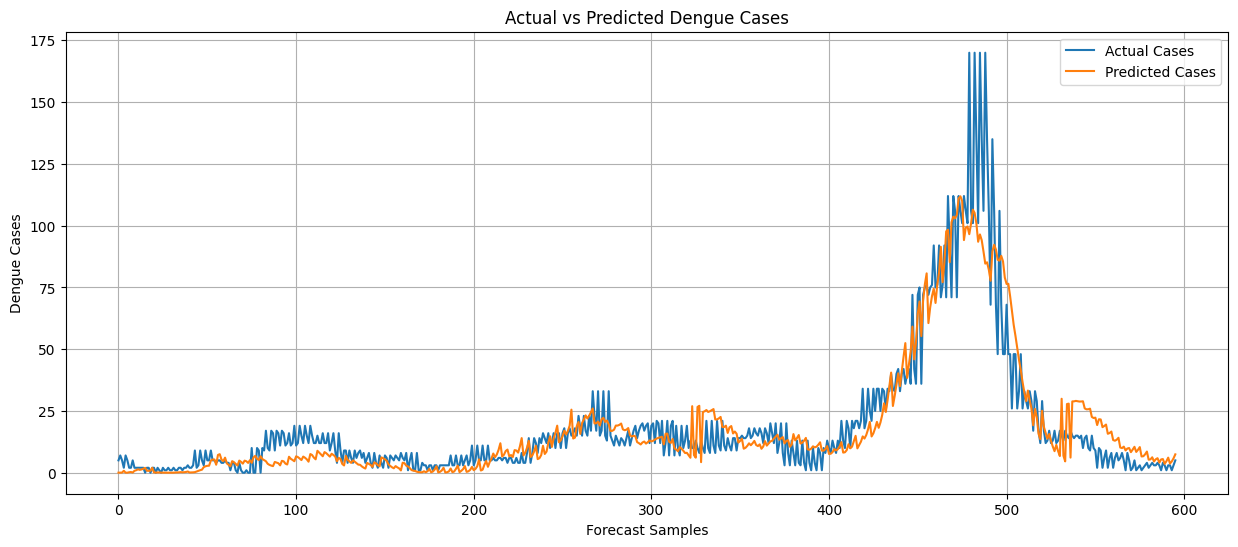

In [104]:
#  Actual vs Predicted Dengue Cases
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

plt.plot(
    actual_flat,
    label="Actual Cases"
)

plt.plot(
    pred_flat,
    label="Predicted Cases"
)

plt.xlabel("Forecast Samples")

plt.ylabel("Dengue Cases")

plt.title("Actual vs Predicted Dengue Cases")

plt.legend()

plt.grid(True)

plt.show()

# Residual Analysis

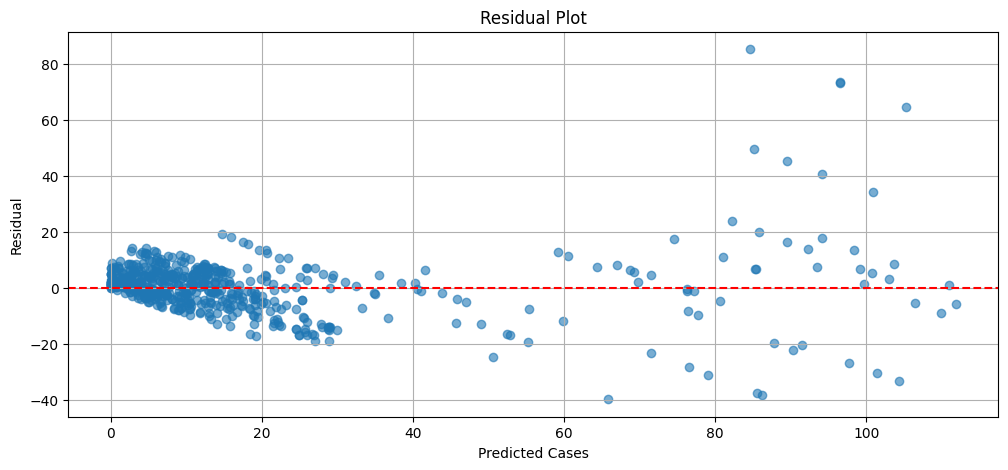

In [105]:
residuals = actual_flat - pred_flat

plt.figure(figsize=(12,5))

plt.scatter(
    pred_flat,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Cases")

plt.ylabel("Residual")

plt.title("Residual Plot")

plt.grid(True)

plt.show()

# Error Distribution

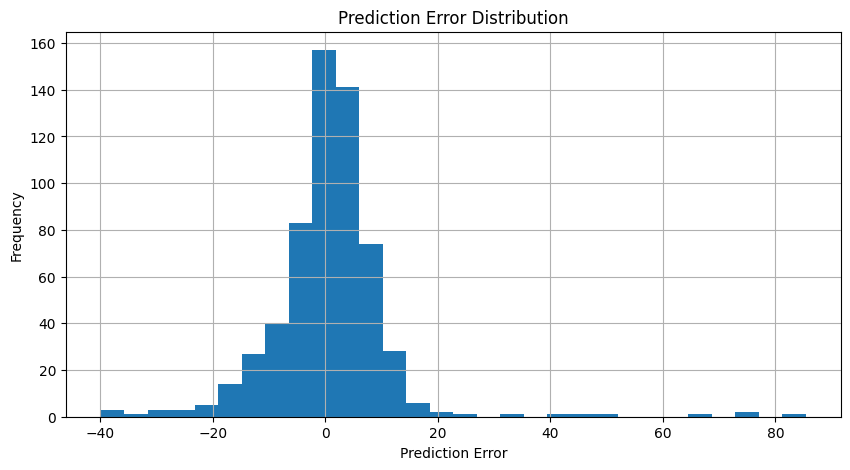

In [106]:
#  Prediction Error Distribution
plt.figure(figsize=(10,5))

plt.hist(
    residuals,
    bins=30
)

plt.xlabel("Prediction Error")

plt.ylabel("Frequency")

plt.title("Prediction Error Distribution")

plt.grid(True)

plt.show()

# Uncertainty Estimation

In [107]:
#  Generate Quantile Predictions
quantile_predictions = best_tft.predict(
    testing,
    mode="quantiles"
)

print("QUANTILE PREDICTIONS")

print("Prediction Shape:", quantile_predictions.shape)

INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities

QUANTILE PREDICTIONS
Prediction Shape: torch.Size([149, 4, 3])


In [108]:
# Separate Lower, Median and Upper Forecasts
#  Extract Prediction Intervals

lower_prediction = quantile_predictions[:, :, 0].reshape(-1)

median_prediction = quantile_predictions[:, :, 1].reshape(-1)

upper_prediction = quantile_predictions[:, :, 2].reshape(-1)

print("Lower :", lower_prediction.shape)
print("Median:", median_prediction.shape)
print("Upper :", upper_prediction.shape)

Lower : torch.Size([596])
Median: torch.Size([596])
Upper : torch.Size([596])


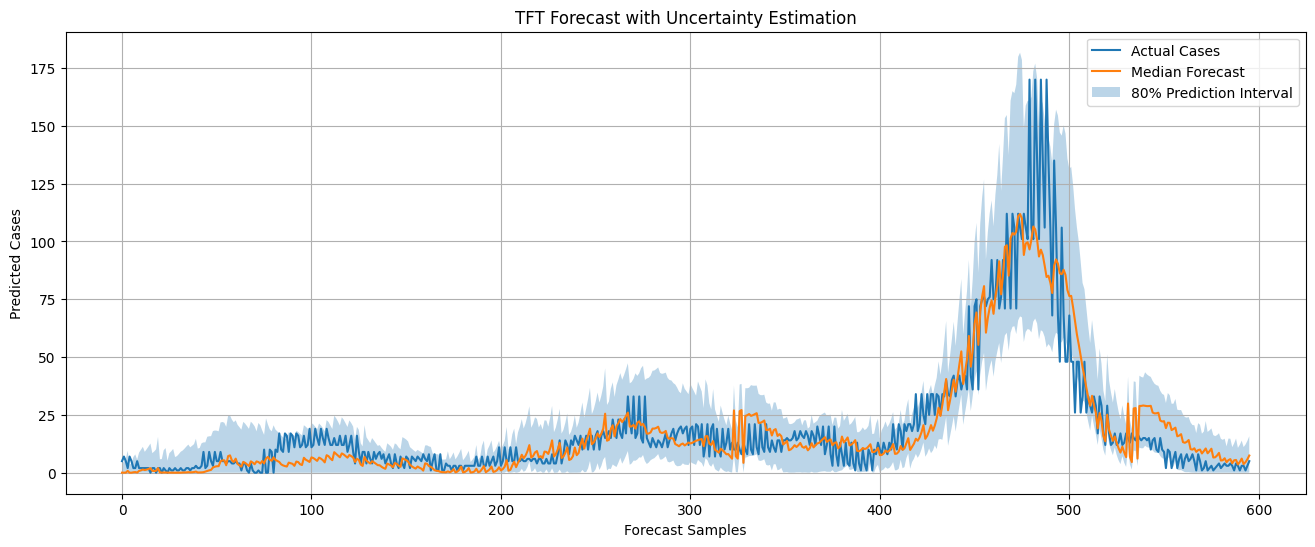

In [109]:
# Visualize Prediction Intervals
# Forecast with Uncertainty Band

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(16,6))

x = np.arange(len(actual_flat))

plt.plot(
    x,
    actual_flat,
    label="Actual Cases"
)

plt.plot(
    x,
    median_prediction,
    label="Median Forecast"
)

plt.fill_between(
    x,
    lower_prediction,
    upper_prediction,
    alpha=0.30,
    label="80% Prediction Interval"
)

plt.xlabel("Forecast Samples")

plt.ylabel("Predicted Cases")

plt.title("TFT Forecast with Uncertainty Estimation")

plt.legend()

plt.grid(True)

plt.show()

In [110]:
# Average Prediction Interval Width
interval_width = upper_prediction - lower_prediction

print("UNCERTAINTY SUMMARY")

print(f"Average Interval Width : {interval_width.mean():.2f}")

print(f"Minimum Interval Width : {interval_width.min():.2f}")

print(f"Maximum Interval Width : {interval_width.max():.2f}")

UNCERTAINTY SUMMARY
Average Interval Width : 27.60
Minimum Interval Width : 3.48
Maximum Interval Width : 114.03


In [111]:
# Prediction Interval Coverage Probability (PICP)

covered = (
    (actual_flat >= lower_prediction.cpu().numpy()) &
    (actual_flat <= upper_prediction.cpu().numpy())
)

picp = covered.mean()

print("UNCERTAINTY ESTIMATION")

print(f"PICP : {picp:.3f}")
print(f"Coverage : {picp * 100:.2f}%")

UNCERTAINTY ESTIMATION
PICP : 0.931
Coverage : 93.12%


In [112]:
# Prediction Interval Normalized Average Width

target_range = actual_flat.max() - actual_flat.min()

pinaw = interval_width.mean() / target_range

print("PINAW")

print(f"PINAW : {pinaw:.4f}")

PINAW
PINAW : 0.1623


#Explainable AI using TFT Interpretation

In [113]:
import warnings
warnings.filterwarnings("ignore")

# Generate TFT Interpretations
raw_predictions, x, *_ = best_tft.predict(
    validation_dataloader,
    mode="raw",
    return_x=True
)

# Generate interpretation using the raw predictions
interpretation = best_tft.interpret_output(
    raw_predictions,
    reduction="sum"
)

print("TFT INTERPRETATION GENERATED")

print(interpretation.keys())

INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities

TFT INTERPRETATION GENERATED
dict_keys(['attention', 'static_variables', 'encoder_variables', 'decoder_variables', 'encoder_length_histogram', 'decoder_length_histogram'])


# Plot Feature Importance

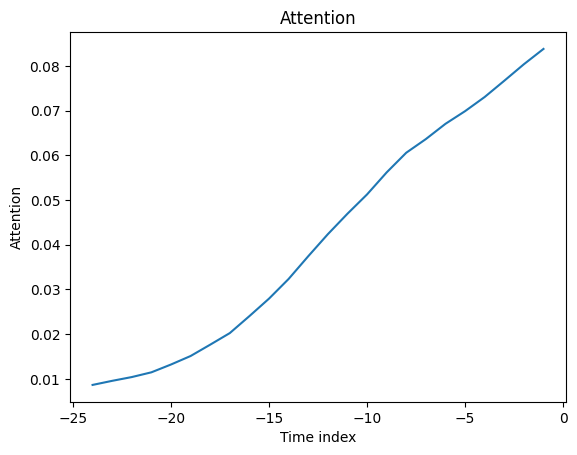

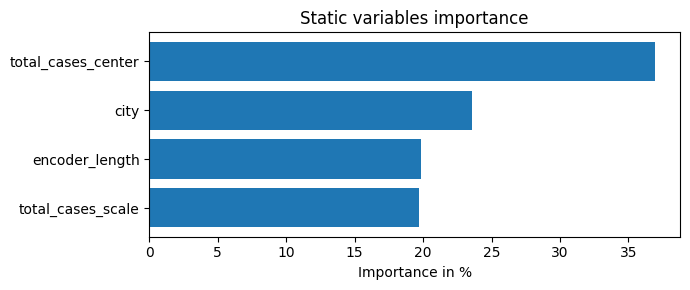

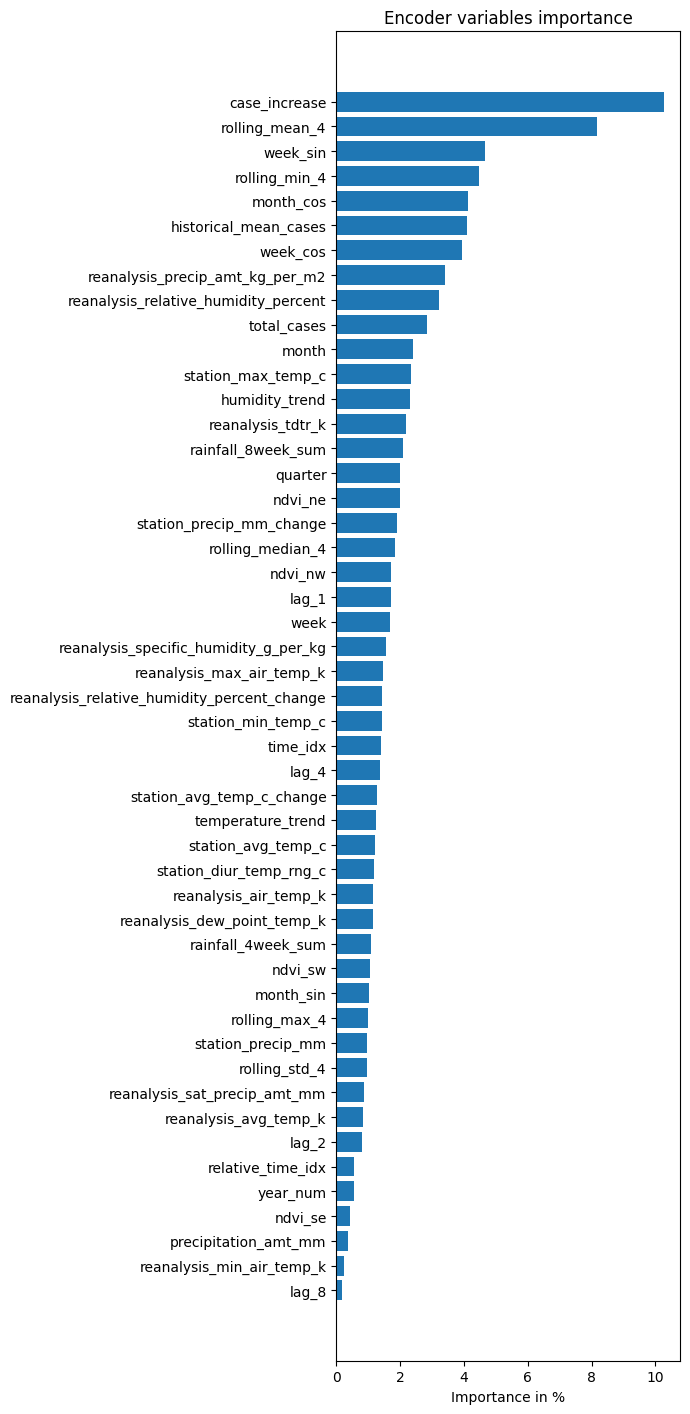

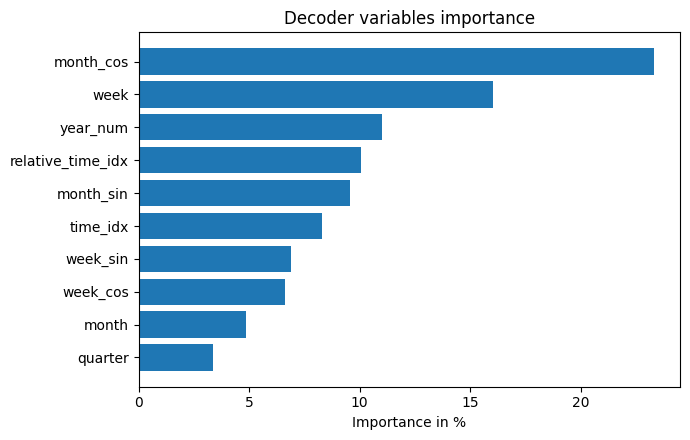

In [114]:
#  Plot Global Feature/ Variable Importance
best_tft.plot_interpretation(interpretation)

plt.show()

Extract Numerical Feature Importance

In [115]:
#  Display Variable Importance
encoder_importance = interpretation["encoder_variables"]

print("ENCODER VARIABLE IMPORTANCE")

print(encoder_importance)

ENCODER VARIABLE IMPORTANCE
tensor([ 2.0912,  0.7971,  3.5420,  2.5007,  2.9751,  1.5194,  6.0992,  6.8768,
         5.8159,  0.8376,  4.2208,  2.9326,  2.5578,  0.6424,  1.5460,  0.5286,
         1.7072,  1.2267,  1.6821,  2.1628,  0.3725,  5.0186,  4.7825,  1.2914,
         2.2879,  3.2235,  1.8003,  1.7540,  3.4399,  2.0963,  1.4155,  2.5172,
         1.1894,  2.0337,  0.2826, 12.0705,  1.3993,  1.4467,  6.6000,  2.7426,
         6.0688,  1.6149,  3.0751,  1.8167,  3.4260, 15.1790,  1.8742,  2.8165,
         2.1021])


# Rank Features

In [116]:
import warnings
warnings.filterwarnings("ignore")

# Get the names of the real-valued encoder features
# The encoder variables include time-varying known/unknown reals and 'encoder_length'
encoder_real_features = (['encoder_length'] +
                         list(training.time_varying_known_reals) +
                         list(training.time_varying_unknown_reals))

# Rank Most Important Features
feature_importance = pd.DataFrame({

    "Feature": encoder_real_features,

    "Importance": encoder_importance.cpu().numpy()

})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

display(feature_importance.head(20))

,Feature,Importance
45,case_increase,15.179032
35,rolling_mean_4,12.070513
7,month_cos,6.876806
38,rolling_min_4,6.600033
6,month_sin,6.099203
40,historical_mean_cases,6.068820
8,week_sin,5.815915
21,reanalysis_precip_amt_kg_per_m2,5.018612
22,reanalysis_relative_humidity_percent,4.782529
10,total_cases,4.220803


# Attention Visualization

TEMPORAL ATTENTION VISUALIZATION


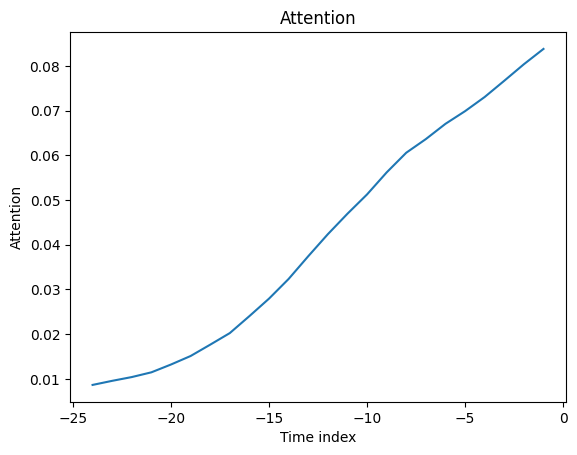

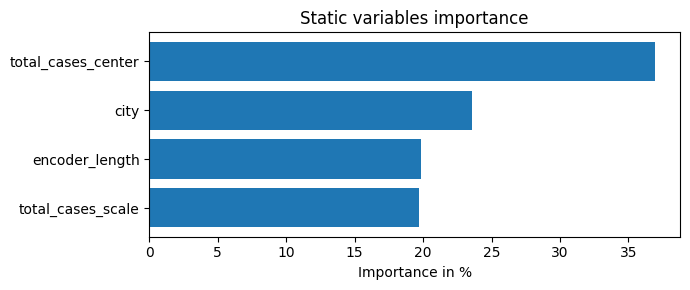

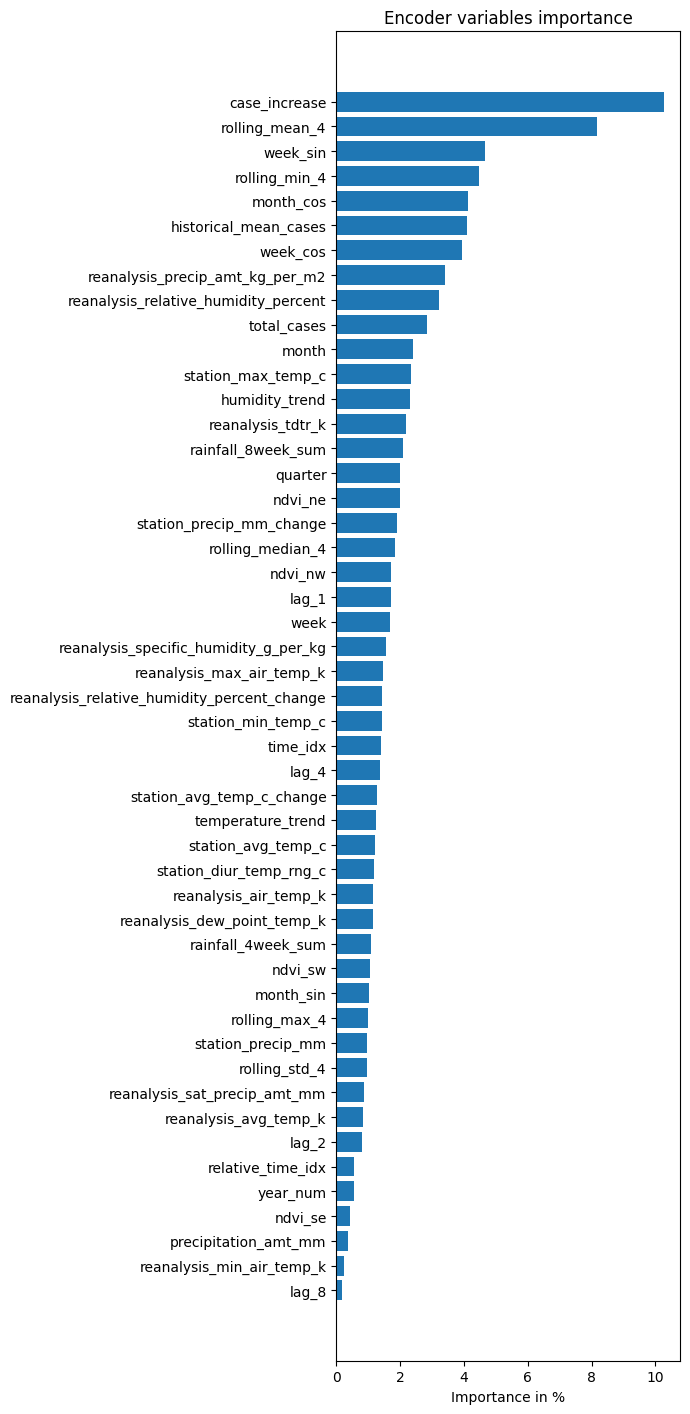

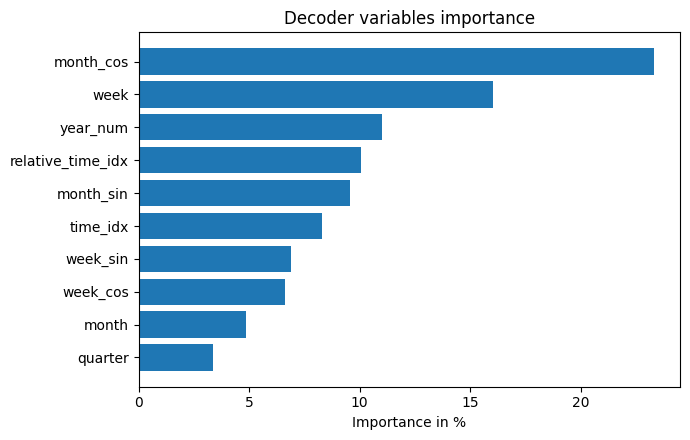

In [117]:
# Visualize Temporal Attention
print("TEMPORAL ATTENTION VISUALIZATION")

best_tft.plot_interpretation(
    interpretation
)

plt.show()

In [118]:
# Save the Attention Figure
plt.savefig(
    "/content/drive/MyDrive/Dengue_TFT_Project/tft_attention.png",
    dpi=300,
    bbox_inches="tight"
)

print("Attention visualization saved successfully.")

Attention visualization saved successfully.


<Figure size 640x480 with 0 Axes>

# AI Decision Support Engine

In [119]:
# Define Outbreak Risk Level
def outbreak_risk(predicted_cases):

    if predicted_cases < 10:
        return "Low"

    elif predicted_cases < 30:
        return "Moderate"

    elif predicted_cases < 60:
        return "High"

    else:
        return "Very High"

# Public Health Recommendations

In [120]:
# Decision Support Recommendations
def recommendation(level):

    if level == "Low":

        return [
            "Maintain routine surveillance.",
            "Continue community awareness campaigns.",
            "Monitor mosquito breeding sites."
        ]

    elif level == "Moderate":

        return [
            "Increase mosquito control activities.",
            "Strengthen disease surveillance.",
            "Educate the public on dengue prevention."
        ]

    elif level == "High":

        return [
            "Conduct intensive vector control.",
            "Prepare hospitals for increased cases.",
            "Issue public health alerts.",
            "Increase diagnostic testing."
        ]

    else:

        return [
            "Declare outbreak preparedness.",
            "Mobilize emergency response teams.",
            "Deploy intensive mosquito eradication.",
            "Expand hospital capacity.",
            "Launch mass public awareness campaigns."
        ]

In [121]:
# Generate Decision Support Report
forecast_cases = float(np.mean(median_prediction.numpy()))

risk = outbreak_risk(forecast_cases)

actions = recommendation(risk)

print("AI DECISION SUPPORT REPORT")

print(f"Average Forecasted Cases : {forecast_cases:.2f}")

print(f"Risk Level              : {risk}")

print(f"PICP                    : {picp*100:.2f}%")

print(f"PINAW                   : {pinaw:.4f}")

print()

print("Recommended Actions")

for i, action in enumerate(actions, 1):

    print(f"{i}. {action}")

AI DECISION SUPPORT REPORT
Average Forecasted Cases : 18.03
Risk Level              : Moderate
PICP                    : 93.12%
PINAW                   : 0.1623

Recommended Actions
1. Increase mosquito control activities.
2. Strengthen disease surveillance.
3. Educate the public on dengue prevention.


In [122]:
    # Forecast Summary
summary = {

    "Average Forecast": round(forecast_cases,2),

    "Minimum Forecast": round(median_prediction.min().item(),2),

    "Maximum Forecast": round(median_prediction.max().item(),2),

    "Average Lower Bound": round(lower_prediction.mean().item(),2),

    "Average Upper Bound": round(upper_prediction.mean().item(),2),

    "Risk Level": risk,

    "PICP": round(picp,3),

    "PINAW": round(pinaw.item(),4)

}

summary_df = pd.DataFrame(summary,index=[0])

display(summary_df)

,Average Forecast,Minimum Forecast,Maximum Forecast,Average Lower Bound,Average Upper Bound,Risk Level,PICP,PINAW
0,18.03,0.01,111.88,7.91,35.5,Moderate,0.931,0.1623


In [123]:
# Generate Final AI Report
report = pd.DataFrame({

    "Forecasted Cases": median_prediction,

    "Lower Bound (10%)": lower_prediction,

    "Upper Bound (90%)": upper_prediction,

    "Actual Cases": actual_flat

})

report["Absolute Error"] = np.abs(

    report["Actual Cases"]

    -

    report["Forecasted Cases"]

)

report["Within Prediction Interval"] = (

    (report["Actual Cases"] >= report["Lower Bound (10%)"])

    &

    (report["Actual Cases"] <= report["Upper Bound (90%)"])

)

display(report.head())

,Forecasted Cases,Lower Bound (10%),Upper Bound (90%),Actual Cases,Absolute Error,Within Prediction Interval
0,0.023895,1.636962e-07,3.847180,5.0,4.976105,False
1,0.031859,3.041682e-07,4.812641,7.0,6.968142,False
2,0.051586,7.073214e-07,6.046506,5.0,4.948414,True
3,0.790554,4.801886e-07,9.465436,2.0,1.209446,True
4,0.016675,1.613613e-07,3.476027,7.0,6.983325,False


In [124]:
# Save Forecast Report
REPORT_PATH = "/content/drive/MyDrive/Dengue_TFT_Project/final_forecast_report.csv"

report.to_csv(

    REPORT_PATH,

    index=False

)

print("FINAL FORECAST REPORT SAVED")

print(REPORT_PATH)

FINAL FORECAST REPORT SAVED
/content/drive/MyDrive/Dengue_TFT_Project/final_forecast_report.csv


In [125]:
# Save Performance Metrics
metrics = pd.DataFrame({

    "Metric":[

        "MAE",

        "RMSE",

        "R2",

        "SMAPE",

        "PICP",

        "PINAW"

    ],

    "Value":[

        mae,

        rmse,

        r2,

        smape,

        picp,

        pinaw

    ]

})

display(metrics)

,Metric,Value
0,MAE,6.559514
1,RMSE,10.724445
2,R2,0.839909
3,SMAPE,63.39917
4,PICP,0.931208
5,PINAW,tensor(0.1623)


In [126]:
METRIC_PATH = "/content/drive/MyDrive/Dengue_TFT_Project/model_performance.csv"

metrics.to_csv(

    METRIC_PATH,

    index=False

)

print("Performance Metrics Saved")

Performance Metrics Saved


# Forecast Visualization

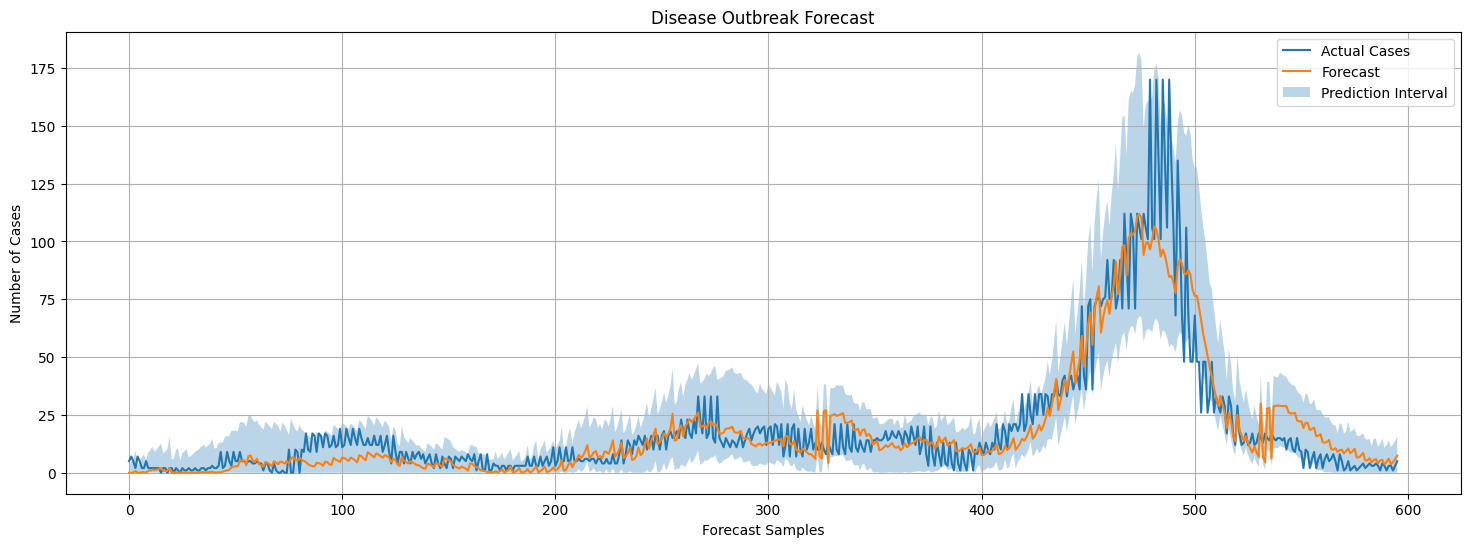

In [127]:
#  Actual vs Forecast
plt.figure(figsize=(18,6))

plt.plot(

    actual_flat,

    label="Actual Cases"

)

plt.plot(

    median_prediction,

    label="Forecast"

)

plt.fill_between(

    np.arange(len(actual_flat)),

    lower_prediction,

    upper_prediction,

    alpha=0.30,

    label="Prediction Interval"

)

plt.xlabel("Forecast Samples")

plt.ylabel("Number of Cases")

plt.title("Disease Outbreak Forecast")

plt.grid(True)

plt.legend()

plt.show()

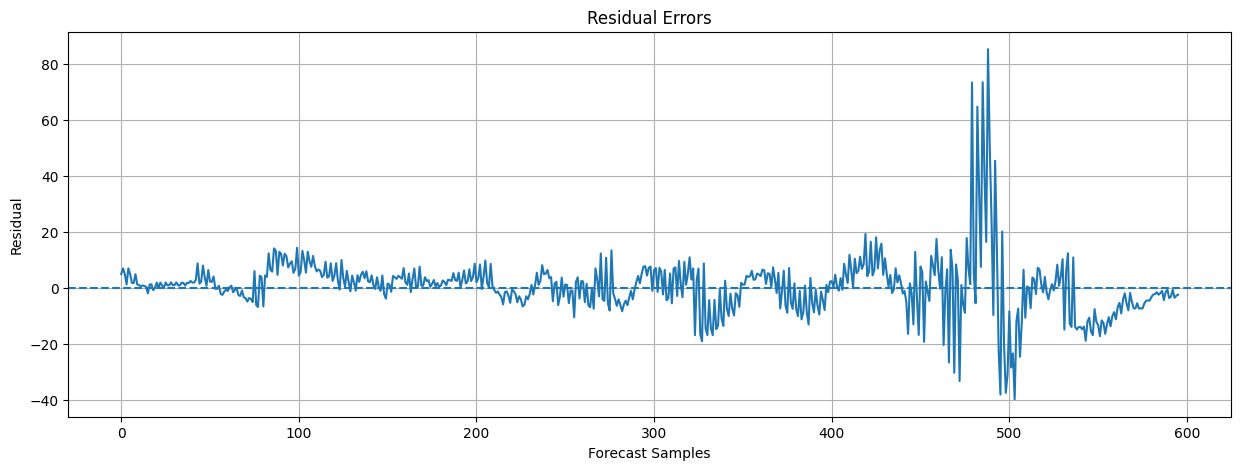

In [128]:
# Residual Analysis
residual = actual_flat - median_prediction.cpu().numpy()

plt.figure(figsize=(15,5))

plt.plot(
    residual
)

plt.axhline(

    0,

    linestyle="--"

)

plt.title("Residual Errors")

plt.xlabel("Forecast Samples")

plt.ylabel("Residual")

plt.grid(True)

plt.show()

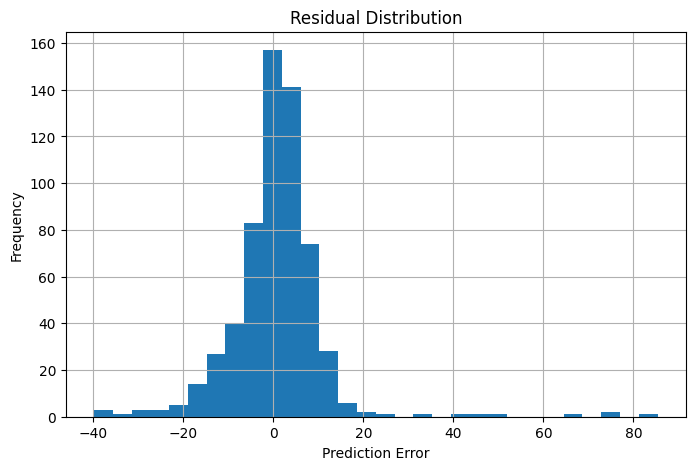

In [129]:
# Error Distribution
plt.figure(figsize=(8,5))

plt.hist(

    residual,

    bins=30

)

plt.title("Residual Distribution")

plt.xlabel("Prediction Error")

plt.ylabel("Frequency")

plt.grid(True)

plt.show()

In [130]:
#  Final System Summary
print("TRUSTWORTHY AI FRAMEWORK SUMMARY")


print(f"Forecast Model              : Temporal Fusion Transformer")

print(f"Forecast Horizon            : {MAX_PREDICTION_LENGTH} Weeks")

print(f"Encoder Length              : {MAX_ENCODER_LENGTH} Weeks")

print(f"Forecast MAE                : {mae:.3f}")

print(f"Forecast RMSE               : {rmse:.3f}")

print(f"Forecast R²                 : {r2:.3f}")

print(f"Forecast SMAPE              : {smape:.2f}%")

print(f"PICP                        : {picp*100:.2f}%")

print(f"PINAW                       : {pinaw:.4f}")

print(f"Decision Support Risk       : {risk}")

print(f"Average Predicted Cases     : {forecast_cases:.2f}")


print("FRAMEWORK COMPLETED SUCCESSFULLY")


TRUSTWORTHY AI FRAMEWORK SUMMARY
Forecast Model              : Temporal Fusion Transformer
Forecast Horizon            : 4 Weeks
Encoder Length              : 24 Weeks
Forecast MAE                : 6.560
Forecast RMSE               : 10.724
Forecast R²                 : 0.840
Forecast SMAPE              : 63.40%
PICP                        : 93.12%
PINAW                       : 0.1623
Decision Support Risk       : Moderate
Average Predicted Cases     : 18.03
FRAMEWORK COMPLETED SUCCESSFULLY


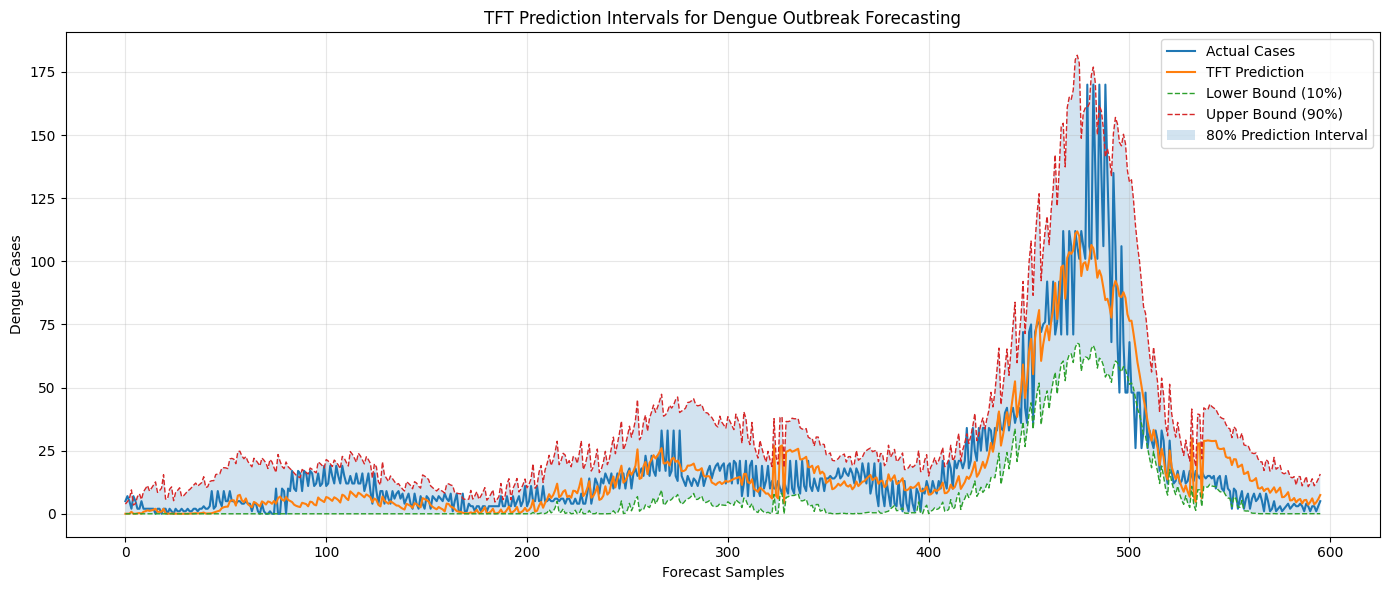

In [131]:
# TFT Prediction Intervals
# Actual vs Prediction vs Lower/Upper Bounds


import matplotlib.pyplot as plt
import numpy as np

# Create x-axis
x = np.arange(len(actual_flat))

plt.figure(figsize=(14, 6))

# Actual observed dengue cases
plt.plot(
    x,
    actual_flat,
    label="Actual Cases",
    linewidth=1.5
)

# Median TFT prediction (0.5 quantile)
plt.plot(
    x,
    median_prediction,
    label="TFT Prediction",
    linewidth=1.5
)

# Lower prediction bound (0.1 quantile)
plt.plot(
    x,
    lower_prediction,
    label="Lower Bound (10%)",
    linestyle="--",
    linewidth=1.0
)

# Upper prediction bound (0.9 quantile)
plt.plot(
    x,
    upper_prediction,
    label="Upper Bound (90%)",
    linestyle="--",
    linewidth=1.0
)

# Shade the prediction interval
plt.fill_between(
    x,
    lower_prediction,
    upper_prediction,
    alpha=0.20,
    label="80% Prediction Interval"
)

plt.xlabel("Forecast Samples")

plt.ylabel("Dengue Cases")

plt.title(
    "TFT Prediction Intervals for Dengue Outbreak Forecasting"
)

plt.legend()

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()

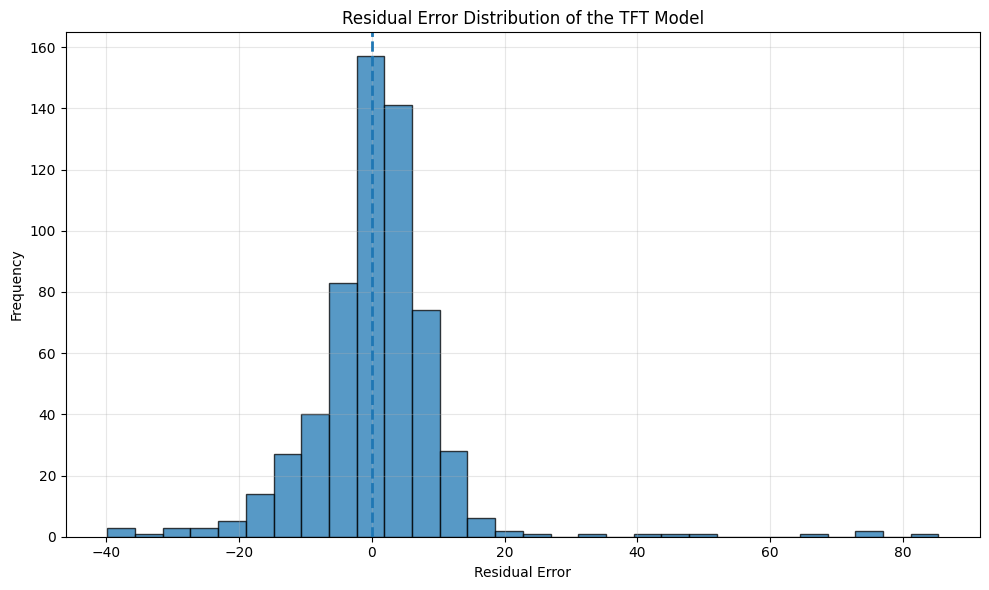

In [132]:
# RESIDUAL ERROR DISTRIBUTION
import numpy as np
import matplotlib.pyplot as plt

# Calculate residuals
residuals = actual_flat - pred_flat

plt.figure(figsize=(10, 6))

plt.hist(
    residuals,
    bins=30,
    edgecolor="black",
    alpha=0.75
)

# Zero-error reference line
plt.axvline(
    0,
    linestyle="--",
    linewidth=2
)

plt.xlabel("Residual Error")
plt.ylabel("Frequency")

plt.title(
    "Residual Error Distribution of the TFT Model"
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.show()

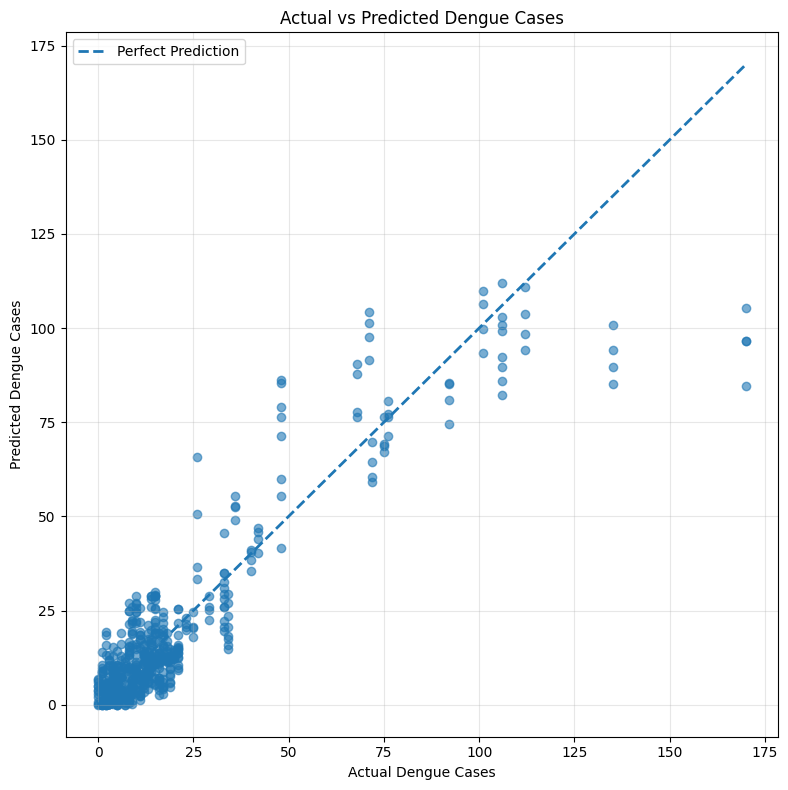

In [133]:
# ACTUAL VS PREDICTED CASES
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))

plt.scatter(
    actual_flat,
    pred_flat,
    alpha=0.6
)

# Perfect prediction line
minimum = min(
    actual_flat.min(),
    pred_flat.min()
)

maximum = max(
    actual_flat.max(),
    pred_flat.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--",
    linewidth=2,
    label="Perfect Prediction"
)

plt.xlabel("Actual Dengue Cases")
plt.ylabel("Predicted Dengue Cases")

plt.title(
    "Actual vs Predicted Dengue Cases"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.show()

In [134]:
# VERIFY TRAINING HISTORY
import os

metrics_path = trainer.log_dir + "/metrics.csv"

print("Metrics file:")
print(metrics_path)

print("Exists:", os.path.exists(metrics_path))

Metrics file:
/content/lightning_logs/version_0/metrics.csv
Exists: False


In [135]:
import os

print("FILES IN LOGGER DIRECTORY:")
print(os.listdir(trainer.log_dir))

FILES IN LOGGER DIRECTORY:
['events.out.tfevents.1790599187.2263e6ea51ae.2593.0', 'hparams.yaml', 'checkpoints']


In [136]:
print("LOGGER TYPE:")
print(type(trainer.logger))

print("\nLOGGER:")
print(trainer.logger)

LOGGER TYPE:
<class 'lightning.pytorch.loggers.tensorboard.TensorBoardLogger'>

LOGGER:


In [137]:
# CHECK SAVED TENSORBOARD METRICS

from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

log_dir = trainer.log_dir

print("TensorBoard log directory:")
print(log_dir)

event_acc = EventAccumulator(log_dir)

event_acc.Reload()

print("\nAvailable scalar metrics:")
print(event_acc.Tags()["scalars"])

TensorBoard log directory:
/content/lightning_logs/version_0

Available scalar metrics:
['hp_metric', 'lr-Adam', 'train_loss_step', 'epoch', 'val_loss', 'val_SMAPE', 'val_MAE', 'val_RMSE', 'val_MAPE', 'train_loss_epoch']


In [138]:
# EXTRACT TRAINING AND VALIDATION LOSS
train_loss_events = event_acc.Scalars(
    "train_loss_epoch"
)

val_loss_events = event_acc.Scalars(
    "val_loss"
)

print("Training loss records :", len(train_loss_events))
print("Validation loss records:", len(val_loss_events))

Training loss records : 17
Validation loss records: 17


In [139]:
print("\nTRAINING LOSS")
for event in train_loss_events:
    print(
        f"Step/Epoch: {event.step}, "
        f"Loss: {event.value:.4f}"
    )

print("\nVALIDATION LOSS")
for event in val_loss_events:
    print(
        f"Step/Epoch: {event.step}, "
        f"Loss: {event.value:.4f}"
    )


TRAINING LOSS
Step/Epoch: 13, Loss: 16.6874
Step/Epoch: 27, Loss: 12.3651
Step/Epoch: 41, Loss: 10.7039
Step/Epoch: 55, Loss: 8.4828
Step/Epoch: 69, Loss: 7.6131
Step/Epoch: 83, Loss: 6.9905
Step/Epoch: 97, Loss: 6.7677
Step/Epoch: 111, Loss: 6.4346
Step/Epoch: 125, Loss: 6.1727
Step/Epoch: 139, Loss: 6.0836
Step/Epoch: 153, Loss: 5.8562
Step/Epoch: 167, Loss: 5.9342
Step/Epoch: 181, Loss: 5.2977
Step/Epoch: 195, Loss: 5.3547
Step/Epoch: 209, Loss: 5.1967
Step/Epoch: 223, Loss: 5.2408
Step/Epoch: 237, Loss: 5.1742

VALIDATION LOSS
Step/Epoch: 13, Loss: 7.3107
Step/Epoch: 27, Loss: 7.1457
Step/Epoch: 41, Loss: 7.5535
Step/Epoch: 55, Loss: 6.0513
Step/Epoch: 69, Loss: 5.0804
Step/Epoch: 83, Loss: 5.1836
Step/Epoch: 97, Loss: 4.5932
Step/Epoch: 111, Loss: 4.8983
Step/Epoch: 125, Loss: 5.7678
Step/Epoch: 139, Loss: 5.7354
Step/Epoch: 153, Loss: 5.6026
Step/Epoch: 167, Loss: 5.4584
Step/Epoch: 181, Loss: 5.9397
Step/Epoch: 195, Loss: 5.2482
Step/Epoch: 209, Loss: 5.4832
Step/Epoch: 223, Lo

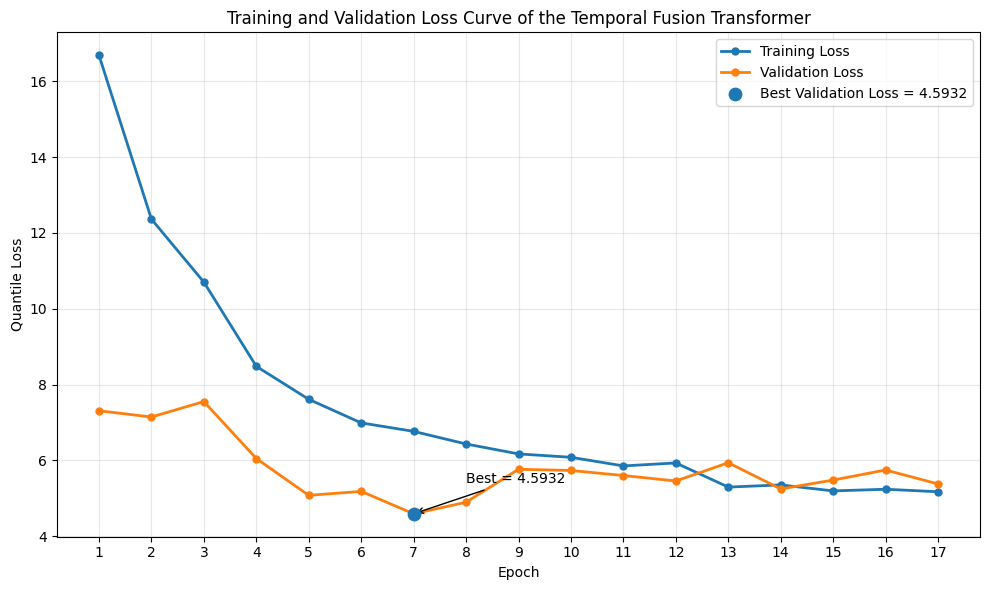

In [140]:
#  TRAINING AND VALIDATION LOSS CURVE

import matplotlib.pyplot as plt
import numpy as np

# Epoch numbers
epochs = np.arange(1, 18)

# Training loss
training_loss = [
    16.6874,
    12.3651,
    10.7039,
    8.4828,
    7.6131,
    6.9905,
    6.7677,
    6.4346,
    6.1727,
    6.0836,
    5.8562,
    5.9342,
    5.2977,
    5.3547,
    5.1967,
    5.2408,
    5.1742
]

# Validation loss
validation_loss = [
    7.3107,
    7.1457,
    7.5535,
    6.0513,
    5.0804,
    5.1836,
    4.5932,
    4.8983,
    5.7678,
    5.7354,
    5.6026,
    5.4584,
    5.9397,
    5.2482,
    5.4832,
    5.7476,
    5.3807
]

# Plot
plt.figure(figsize=(10, 6))

plt.plot(
    epochs,
    training_loss,
    marker="o",
    linewidth=2,
    markersize=5,
    label="Training Loss"
)

plt.plot(
    epochs,
    validation_loss,
    marker="o",
    linewidth=2,
    markersize=5,
    label="Validation Loss"
)

# Mark best validation loss
best_epoch = np.argmin(validation_loss) + 1
best_val = min(validation_loss)

plt.scatter(
    best_epoch,
    best_val,
    s=80,
    zorder=5,
    label=f"Best Validation Loss = {best_val:.4f}"
)

plt.annotate(
    f"Best = {best_val:.4f}",
    xy=(best_epoch, best_val),
    xytext=(best_epoch + 1, best_val + 0.8),
    arrowprops=dict(arrowstyle="->"),
    fontsize=10
)

# Labels
plt.xlabel("Epoch")
plt.ylabel("Quantile Loss")

plt.title(
    "Training and Validation Loss Curve of the Temporal Fusion Transformer"
)

plt.xticks(epochs)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.show()

TEST

In [141]:
# APPEND-ONLY BASELINE EXPERIMENT

import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("CLEAN BASELINE EXPERIMENT")

# SETTINGS
SEQ_LEN = 24
HORIZON = 4

# Use the same temporal proportions as the TFT experiment
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15

# PREPARE CITY-WISE CHRONOLOGICAL DATA
baseline_results = []

cities = cleaned_data["city"].unique()

print("Cities:", cities)

for city in cities:

    city_df = cleaned_data[
        cleaned_data["city"] == city
    ].copy()

    # sort chronologically
    if "week_start_date" in city_df.columns:
        city_df = city_df.sort_values("week_start_date")
    elif "date" in city_df.columns:
        city_df = city_df.sort_values("date")

    cases = city_df["total_cases"].astype(float).values

    n = len(cases)

    train_end = int(n * TRAIN_RATIO)
    val_end = int(n * (TRAIN_RATIO + VAL_RATIO))

    # TEST PERIOD
    test_cases = cases[val_end:]

    print(
        f"\n{city}: "
        f"Total={n}, "
        f"Train={train_end}, "
        f"Validation={val_end-train_end}, "
        f"Test={n-val_end}"
    )

    # 1. NAIVE
    # Last observed week
    naive_actual = test_cases[1:]
    naive_pred = test_cases[:-1]

    naive_mae = mean_absolute_error(
        naive_actual,
        naive_pred
    )

    naive_rmse = np.sqrt(
        mean_squared_error(
            naive_actual,
            naive_pred
        )
    )

    naive_r2 = r2_score(
        naive_actual,
        naive_pred
    )

    baseline_results.append({
        "City": city,
        "Model": "Naive",
        "MAE": naive_mae,
        "RMSE": naive_rmse,
        "R2": naive_r2
    })

    # 2. SEASONAL NAIVE
    # Same week from previous year

    seasonal_lag = 52

    # Need enough observations
    city_test_start = val_end

    seasonal_actual = []
    seasonal_pred = []

    for i in range(city_test_start, n):

        previous_year_index = i - seasonal_lag

        if previous_year_index >= 0:

            seasonal_actual.append(
                cases[i]
            )

            seasonal_pred.append(
                cases[previous_year_index]
            )

    seasonal_actual = np.array(seasonal_actual)
    seasonal_pred = np.array(seasonal_pred)

    if len(seasonal_actual) > 0:

        seasonal_mae = mean_absolute_error(
            seasonal_actual,
            seasonal_pred
        )

        seasonal_rmse = np.sqrt(
            mean_squared_error(
                seasonal_actual,
                seasonal_pred
            )
        )

        seasonal_r2 = r2_score(
            seasonal_actual,
            seasonal_pred
        )

        baseline_results.append({
            "City": city,
            "Model": "Seasonal Naive",
            "MAE": seasonal_mae,
            "RMSE": seasonal_rmse,
            "R2": seasonal_r2
        })

    # 3. MULTI-STEP NAIVE
    # Persistence forecast for 4 weeks
    multi_actual = []
    multi_pred = []

    for i in range(
        val_end,
        n - HORIZON + 1
    ):

        last_value = cases[i - 1]

        actual_window = cases[
            i:i + HORIZON
        ]

        pred_window = np.repeat(
            last_value,
            HORIZON
        )

        multi_actual.extend(
            actual_window
        )

        multi_pred.extend(
            pred_window
        )

    multi_actual = np.array(multi_actual)
    multi_pred = np.array(multi_pred)

    multi_mae = mean_absolute_error(
        multi_actual,
        multi_pred
    )

    multi_rmse = np.sqrt(
        mean_squared_error(
            multi_actual,
            multi_pred
        )
    )

    multi_r2 = r2_score(
        multi_actual,
        multi_pred
    )

    baseline_results.append({
        "City": city,
        "Model": "4-Week Persistence",
        "MAE": multi_mae,
        "RMSE": multi_rmse,
        "R2": multi_r2
    })


baseline_df = pd.DataFrame(
    baseline_results
)

print("\n")
print("CITY-WISE BASELINE RESULTS")

print(
    baseline_df.round(3).to_string(index=False)
)

CLEAN BASELINE EXPERIMENT
Cities: ['iq' 'sj']

iq: Total=520, Train=364, Validation=78, Test=78

sj: Total=936, Train=655, Validation=140, Test=141


CITY-WISE BASELINE RESULTS
City              Model    MAE   RMSE     R2
  iq              Naive  2.974  4.314  0.625
  iq     Seasonal Naive  8.885 15.506 -3.862
  iq 4-Week Persistence  4.370  6.699  0.111
  sj              Naive  7.521 12.511  0.864
  sj     Seasonal Naive 27.979 44.250 -0.681
  sj 4-Week Persistence 10.832 19.198  0.670


In [142]:
# OVERALL BASELINE PERFORMANCE
overall_baseline = (
    baseline_df
    .groupby("Model")[["MAE", "RMSE", "R2"]]
    .mean()
    .reset_index()
)

print("OVERALL BASELINE PERFORMANCE")

print(
    overall_baseline.round(3).to_string(index=False)
)

OVERALL BASELINE PERFORMANCE
             Model    MAE   RMSE     R2
4-Week Persistence  7.601 12.948  0.391
             Naive  5.248  8.412  0.745
    Seasonal Naive 18.432 29.878 -2.271


In [143]:
# CLEAN MULTI-STEP LSTM BASELINE
# APPEND-ONLY

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler

print("LSTM BASELINE")

SEQ_LEN = 24
HORIZON = 4

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

# LSTM MODEL
class CleanLSTM(nn.Module):

    def __init__(
        self,
        input_size=1,
        hidden_size=64,
        num_layers=2,
        horizon=4
    ):

        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.2
        )

        self.fc = nn.Linear(
            hidden_size,
            horizon
        )

    def forward(self, x):

        output, _ = self.lstm(x)

        last_output = output[:, -1, :]

        return self.fc(last_output)


lstm_results = []

for city in cleaned_data["city"].unique():

    print("Training LSTM:", city)

    city_df = cleaned_data[
        cleaned_data["city"] == city
    ].copy()

    if "week_start_date" in city_df.columns:
        city_df = city_df.sort_values(
            "week_start_date"
        )
    elif "date" in city_df.columns:
        city_df = city_df.sort_values(
            "date"
        )

    cases = city_df[
        "total_cases"
    ].astype(float).values

    n = len(cases)

    train_end = int(
        n * TRAIN_RATIO
    )

    val_end = int(
        n * (TRAIN_RATIO + VAL_RATIO)
    )

    # FIT SCALER ONLY ON TRAINING DATA
    scaler = MinMaxScaler()

    scaler.fit(
        cases[:train_end].reshape(-1, 1)
    )

    normalized = scaler.transform(
        cases.reshape(-1, 1)
    ).flatten()

    # CREATE SEQUENCES
    X_train = []
    y_train = []

    X_test = []
    y_test = []

    test_start = val_end

    for i in range(
        SEQ_LEN,
        len(normalized) - HORIZON + 1
    ):

        X = normalized[
            i-SEQ_LEN:i
        ]

        y = normalized[
            i:i+HORIZON
        ]

        target_index = i

        if target_index < train_end:

            X_train.append(X)
            y_train.append(y)

        elif target_index >= test_start:

            X_test.append(X)
            y_test.append(y)

    X_train = np.array(X_train)
    y_train = np.array(y_train)

    X_test = np.array(X_test)
    y_test = np.array(y_test)

    print(
        "Train sequences:",
        len(X_train)
    )

    print(
        "Test sequences:",
        len(X_test)
    )

    # TORCH DATA
    X_train_t = torch.tensor(
        X_train,
        dtype=torch.float32
    ).unsqueeze(-1).to(device)

    y_train_t = torch.tensor(
        y_train,
        dtype=torch.float32
    ).to(device)

    X_test_t = torch.tensor(
        X_test,
        dtype=torch.float32
    ).unsqueeze(-1).to(device)

    # MODEL
    model = CleanLSTM(
        input_size=1,
        hidden_size=64,
        num_layers=2,
        horizon=HORIZON
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.001
    )

    criterion = nn.L1Loss()

    dataset = TensorDataset(
        X_train_t,
        y_train_t
    )

    loader = DataLoader(
        dataset,
        batch_size=32,
        shuffle=False
    )

    # TRAIN
    for epoch in range(50):

        model.train()

        epoch_loss = 0

        for xb, yb in loader:

            optimizer.zero_grad()

            pred = model(xb)

            loss = criterion(
                pred,
                yb
            )

            loss.backward()

            optimizer.step()

            epoch_loss += loss.item()

        if (
            epoch == 0
            or (epoch + 1) % 10 == 0
        ):

            print(
                f"Epoch {epoch+1:02d}/50 "
                f"Loss={epoch_loss/len(loader):.4f}"
            )

    # TEST
    model.eval()

    with torch.no_grad():

        pred_norm = (
            model(X_test_t)
            .cpu()
            .numpy()
        )

    # INVERSE TRANSFORM CORRECTLY
    pred_raw = scaler.inverse_transform(
        pred_norm.reshape(-1, 1)
    ).reshape(
        pred_norm.shape
    )

    actual_raw = scaler.inverse_transform(
        y_test.reshape(-1, 1)
    ).reshape(
        y_test.shape
    )

    # OVERALL METRICS
    pred_flat = pred_raw.flatten()
    actual_flat_lstm = actual_raw.flatten()

    mae = mean_absolute_error(
        actual_flat_lstm,
        pred_flat
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual_flat_lstm,
            pred_flat
        )
    )

    r2 = r2_score(
        actual_flat_lstm,
        pred_flat
    )

    print(
        f"\n{city} LSTM:"
    )

    print(
        f"MAE  = {mae:.3f}"
    )

    print(
        f"RMSE = {rmse:.3f}"
    )

    print(
        f"R²   = {r2:.3f}"
    )

    lstm_results.append({
        "City": city,
        "Model": "LSTM",
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })


lstm_df = pd.DataFrame(
    lstm_results
)

print("\n")
print("LSTM RESULTS")

print(
    lstm_df.round(3).to_string(index=False)
)

LSTM BASELINE
Device: cpu
Training LSTM: iq
Train sequences: 340
Test sequences: 75
Epoch 01/50 Loss=0.0504
Epoch 10/50 Loss=0.0423
Epoch 20/50 Loss=0.0385
Epoch 30/50 Loss=0.0343
Epoch 40/50 Loss=0.0333
Epoch 50/50 Loss=0.0328

iq LSTM:
MAE  = 3.914
RMSE = 6.321
R²   = 0.209
Training LSTM: sj
Train sequences: 631
Test sequences: 138
Epoch 01/50 Loss=0.0770
Epoch 10/50 Loss=0.0484
Epoch 20/50 Loss=0.0328
Epoch 30/50 Loss=0.0282
Epoch 40/50 Loss=0.0279
Epoch 50/50 Loss=0.0261

sj LSTM:
MAE  = 10.427
RMSE = 17.851
R²   = 0.715


LSTM RESULTS
City Model    MAE   RMSE    R2
  iq  LSTM  3.914  6.321 0.209
  sj  LSTM 10.427 17.851 0.715


# FINAL MODEL COMPARISON

In [144]:
# Combine baseline + LSTM
all_results = pd.concat(
    [
        baseline_df,
        lstm_df
    ],
    ignore_index=True
)

# Add TFT results from your reported evaluation
tft_results = pd.DataFrame({

    "City": [
        "Overall"
    ],

    "Model": [
        "Proposed TFT Framework"
    ],

    "MAE": [
        6.560
    ],

    "RMSE": [
        10.724
    ],

    "R2": [
        0.840
    ]
})

# Overall baseline averages
overall_existing = (
    all_results
    .groupby("Model")[["MAE", "RMSE", "R2"]]
    .mean()
    .reset_index()
)

overall_existing.insert(
    0,
    "City",
    "Overall"
)

final_comparison = pd.concat(
    [
        overall_existing,
        tft_results
    ],
    ignore_index=True
)

print("FINAL MODEL COMPARISON")

print(
    final_comparison.round(3)
    .to_string(index=False)
)

# SAVE
output_path = (
    "/content/drive/MyDrive/"
    "Trustworthy_Disease_Outbreak_AI/"
    "model_comparison_final_v2.csv"
)

final_comparison.to_csv(
    output_path,
    index=False
)

print("\nSaved to:")
print(output_path)

FINAL MODEL COMPARISON
   City                  Model    MAE   RMSE     R2
Overall     4-Week Persistence  7.601 12.948  0.391
Overall                   LSTM  7.171 12.086  0.462
Overall                  Naive  5.248  8.412  0.745
Overall         Seasonal Naive 18.432 29.878 -2.271
Overall Proposed TFT Framework  6.560 10.724  0.840

Saved to:
/content/drive/MyDrive/Trustworthy_Disease_Outbreak_AI/model_comparison_final_v2.csv


In [145]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("MULTI-HORIZON BASELINE COMPARISON")
print("24-week history -> 4-week forecast")

SEQ_LEN = 24
HORIZON = 4

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15

baseline_results = []

# PROCESS EACH CITY SEPARATELY
for city in cleaned_data["city"].unique():

    city_df = cleaned_data[
        cleaned_data["city"] == city
    ].copy()

    # Sort chronologically
    if "week_start_date" in city_df.columns:
        city_df = city_df.sort_values(
            "week_start_date"
        )

    elif "date" in city_df.columns:
        city_df = city_df.sort_values(
            "date"
        )

    cases = (
        city_df["total_cases"]
        .astype(float)
        .values
    )

    n = len(cases)

    train_end = int(
        n * TRAIN_RATIO
    )

    val_end = int(
        n * (TRAIN_RATIO + VAL_RATIO)
    )

    print(
        f"\n{city}: "
        f"total={n}, "
        f"train={train_end}, "
        f"validation={val_end-train_end}, "
        f"test={n-val_end}"
    )

    # GENERATE 4-WEEK TEST WINDOWS
    actual_windows = []

    naive_windows = []

    seasonal_windows = []

    for i in range(
        val_end,
        n - HORIZON + 1
    ):

      # Last 24 weeks before forecast
        history_start = i - SEQ_LEN
        history_end = i

        history = cases[
            history_start:history_end
        ]

        actual = cases[
            i:i + HORIZON
        ]


     # NAIVE / PERSISTENCE
        # Predict all 4 future weeks using
        # the last observed value.
        naive_prediction = np.repeat(
            history[-1],
            HORIZON
        )

        # SEASONAL NAIVE
        # Predict each future week using
        # the corresponding week 52 weeks earlier.
        seasonal_prediction = []

        valid_seasonal = True

        for h in range(HORIZON):

            historical_index = (
                i + h - 52
            )

            if historical_index < 0:
                valid_seasonal = False
                break

            seasonal_prediction.append(
                cases[historical_index]
            )

        if not valid_seasonal:
            continue

        actual_windows.append(actual)

        naive_windows.append(
            naive_prediction
        )

        seasonal_windows.append(
            seasonal_prediction
        )

    # FLATTEN WINDOWS
    actual_array = np.array(
        actual_windows
    ).flatten()

    naive_array = np.array(
        naive_windows
    ).flatten()

    seasonal_array = np.array(
        seasonal_windows
    ).flatten()

    # NAIVE METRICS
    naive_mae = mean_absolute_error(
        actual_array,
        naive_array
    )

    naive_rmse = np.sqrt(
        mean_squared_error(
            actual_array,
            naive_array
        )
    )

    naive_r2 = r2_score(
        actual_array,
        naive_array
    )

    baseline_results.append({
        "City": city,
        "Model": "Naive (4-Week)",
        "MAE": naive_mae,
        "RMSE": naive_rmse,
        "R2": naive_r2
    })

    # SEASONAL NAIVE METRICS
    seasonal_mae = mean_absolute_error(
        actual_array,
        seasonal_array
    )

    seasonal_rmse = np.sqrt(
        mean_squared_error(
            actual_array,
            seasonal_array
        )
    )

    seasonal_r2 = r2_score(
        actual_array,
        seasonal_array
    )

    baseline_results.append({
        "City": city,
        "Model": "Seasonal Naive (52-Week)",
        "MAE": seasonal_mae,
        "RMSE": seasonal_rmse,
        "R2": seasonal_r2
    })

# RESULTS
multihorizon_baseline_df = pd.DataFrame(
    baseline_results
)

print("\n")
print("CITY-WISE MULTI-HORIZON BASELINES")

print(
    multihorizon_baseline_df
    .round(3)
    .to_string(index=False)
)

MULTI-HORIZON BASELINE COMPARISON
24-week history -> 4-week forecast

iq: total=520, train=364, validation=78, test=78

sj: total=936, train=655, validation=140, test=141


CITY-WISE MULTI-HORIZON BASELINES
City                    Model    MAE   RMSE     R2
  iq           Naive (4-Week)  4.370  6.699  0.111
  iq Seasonal Naive (52-Week)  8.537 15.031 -3.475
  sj           Naive (4-Week) 10.832 19.198  0.670
  sj Seasonal Naive (52-Week) 27.562 43.669 -0.706


In [146]:
# OVERALL MULTI-HORIZON BASELINE RESULTS
overall_multihorizon = (
    multihorizon_baseline_df
    .groupby("Model")[["MAE", "RMSE", "R2"]]
    .mean()
    .reset_index()
)

print("OVERALL MULTI-HORIZON BASELINES")

print(
    overall_multihorizon
    .round(3)
    .to_string(index=False)
)

OVERALL MULTI-HORIZON BASELINES
                   Model    MAE   RMSE     R2
          Naive (4-Week)  7.601 12.948  0.391
Seasonal Naive (52-Week) 18.049 29.350 -2.091


In [147]:
# LSTM - SAME 24-WEEK -> 4-WEEK TASK
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("LSTM BASELINE - SAME FORECASTING TASK AS TFT")
print("24-week history -> 4-week forecast")

SEQ_LEN = 24
HORIZON = 4

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

# MODEL
class ComparisonLSTM(nn.Module):

    def __init__(
        self,
        input_size=1,
        hidden_size=64,
        num_layers=2,
        horizon=4
    ):

        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.20
        )

        self.fc = nn.Linear(
            hidden_size,
            horizon
        )

    def forward(self, x):

        output, _ = self.lstm(x)

        last_output = output[:, -1, :]

        return self.fc(last_output)


# STORE RESULTS
lstm_comparison_results = []

# TRAIN CITY BY CITY
for city in cleaned_data["city"].unique():

    print("CITY:", city)

    city_df = cleaned_data[
        cleaned_data["city"] == city
    ].copy()

    # Chronological ordering
    if "week_start_date" in city_df.columns:

        city_df = city_df.sort_values(
            "week_start_date"
        )

    elif "date" in city_df.columns:

        city_df = city_df.sort_values(
            "date"
        )

    cases = (
        city_df["total_cases"]
        .astype(float)
        .values
    )

    n = len(cases)

    train_end = int(
        n * TRAIN_RATIO
    )

    val_end = int(
        n * (TRAIN_RATIO + VAL_RATIO)
    )

    # SCALE USING TRAINING DATA ONLY
    scaler = MinMaxScaler()

    scaler.fit(
        cases[:train_end].reshape(-1, 1)
    )

    scaled_cases = scaler.transform(
        cases.reshape(-1, 1)
    ).flatten()

    # CREATE TRAIN / TEST WINDOWS
    X_train = []
    y_train = []

    X_test = []
    y_test = []

    for i in range(
        SEQ_LEN,
        n - HORIZON + 1
    ):

        X = scaled_cases[
            i - SEQ_LEN:i
        ]

        y = scaled_cases[
            i:i + HORIZON
        ]

        # Forecast begins before training cutoff
        if i < train_end:

            X_train.append(X)
            y_train.append(y)

        # Forecast begins in test period
        elif i >= val_end:

            X_test.append(X)
            y_test.append(y)

    X_train = np.array(X_train)
    y_train = np.array(y_train)

    X_test = np.array(X_test)
    y_test = np.array(y_test)

    print("Training windows:", len(X_train))
    print("Testing windows :", len(X_test))

    # TORCH TENSORS
    X_train_tensor = torch.tensor(
        X_train,
        dtype=torch.float32
    ).unsqueeze(-1).to(device)

    y_train_tensor = torch.tensor(
        y_train,
        dtype=torch.float32
    ).to(device)

    X_test_tensor = torch.tensor(
        X_test,
        dtype=torch.float32
    ).unsqueeze(-1).to(device)

    # MODEL
    model = ComparisonLSTM(
        input_size=1,
        hidden_size=64,
        num_layers=2,
        horizon=HORIZON
    ).to(device)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.001
    )

    criterion = nn.L1Loss()

    train_dataset = TensorDataset(
        X_train_tensor,
        y_train_tensor
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=32,
        shuffle=False
    )

    # TRAIN
    for epoch in range(50):

        model.train()

        total_loss = 0.0

        for xb, yb in train_loader:

            optimizer.zero_grad()

            prediction = model(xb)

            loss = criterion(
                prediction,
                yb
            )

            loss.backward()

            optimizer.step()

            total_loss += loss.item()

        if (
            epoch == 0
            or (epoch + 1) % 10 == 0
        ):

            avg_loss = (
                total_loss /
                len(train_loader)
            )

            print(
                f"Epoch {epoch+1:02d}/50 "
                f"Loss={avg_loss:.4f}"
            )

    # PREDICT
    model.eval()

    with torch.no_grad():

        predictions_scaled = (
            model(X_test_tensor)
            .cpu()
            .numpy()
        )

    # INVERSE TRANSFORM
    predictions_raw = scaler.inverse_transform(
        predictions_scaled.reshape(-1, 1)
    ).reshape(
        predictions_scaled.shape
    )

    actual_raw = scaler.inverse_transform(
        y_test.reshape(-1, 1)
    ).reshape(
        y_test.shape
    )

    # METRICS
    actual_flat = actual_raw.flatten()
    prediction_flat = predictions_raw.flatten()

    mae = mean_absolute_error(
        actual_flat,
        prediction_flat
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual_flat,
            prediction_flat
        )
    )

    r2 = r2_score(
        actual_flat,
        prediction_flat
    )

    print(
        f"\n{city} Results:"
    )

    print(
        f"MAE  : {mae:.3f}"
    )

    print(
        f"RMSE : {rmse:.3f}"
    )

    print(
        f"R²   : {r2:.3f}"
    )

    lstm_comparison_results.append({
        "City": city,
        "Model": "LSTM (24→4)",
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

# CITY RESULTS
lstm_comparison_df = pd.DataFrame(
    lstm_comparison_results
)

print("\n")
print("LSTM CITY-WISE RESULTS")

print(
    lstm_comparison_df
    .round(3)
    .to_string(index=False)
)

# OVERALL LSTM
lstm_overall = (
    lstm_comparison_df[
        ["MAE", "RMSE", "R2"]
    ]
    .mean()
)

print("\n")
print("OVERALL LSTM RESULTS")

print(
    f"MAE  : {lstm_overall['MAE']:.3f}"
)

print(
    f"RMSE : {lstm_overall['RMSE']:.3f}"
)

print(
    f"R²   : {lstm_overall['R2']:.3f}"
)

LSTM BASELINE - SAME FORECASTING TASK AS TFT
24-week history -> 4-week forecast
Device: cpu
CITY: iq
Training windows: 340
Testing windows : 75
Epoch 01/50 Loss=0.0640
Epoch 10/50 Loss=0.0438
Epoch 20/50 Loss=0.0401
Epoch 30/50 Loss=0.0369
Epoch 40/50 Loss=0.0345
Epoch 50/50 Loss=0.0332

iq Results:
MAE  : 3.971
RMSE : 6.347
R²   : 0.202
CITY: sj
Training windows: 631
Testing windows : 138
Epoch 01/50 Loss=0.0661
Epoch 10/50 Loss=0.0464
Epoch 20/50 Loss=0.0303
Epoch 30/50 Loss=0.0297
Epoch 40/50 Loss=0.0288
Epoch 50/50 Loss=0.0272

sj Results:
MAE  : 11.000
RMSE : 19.551
R²   : 0.658


LSTM CITY-WISE RESULTS
City       Model    MAE   RMSE    R2
  iq LSTM (24→4)  3.971  6.347 0.202
  sj LSTM (24→4) 11.000 19.551 0.658


OVERALL LSTM RESULTS
MAE  : 7.485
RMSE : 12.949
R²   : 0.430


# FINAL FAIR MODEL COMPARISON

In [148]:
# FINAL FAIR MODEL COMPARISON

print("FAIR MULTI-HORIZON MODEL COMPARISON")

# Existing clean baselines
fair_baselines = (
    multihorizon_baseline_df
    .groupby("Model")[["MAE", "RMSE", "R2"]]
    .mean()
    .reset_index()
)

# Rename for consistency
fair_baselines["Model"] = fair_baselines[
    "Model"
].replace({
    "Naive (4-Week)": "Naive (24→4)",
    "Seasonal Naive (52-Week)": "Seasonal Naive (24→4)"
})

# LSTM
lstm_fair = pd.DataFrame({
    "Model": ["LSTM (24→4)"],
    "MAE": [lstm_overall["MAE"]],
    "RMSE": [lstm_overall["RMSE"]],
    "R2": [lstm_overall["R2"]]
})

# TFT
tft_fair = pd.DataFrame({
    "Model": ["Proposed TFT"],
    "MAE": [6.560],
    "RMSE": [10.724],
    "R2": [0.840]
})

# Combine
fair_comparison = pd.concat(
    [
        fair_baselines,
        lstm_fair,
        tft_fair
    ],
    ignore_index=True
)

# Order models
desired_order = [
    "Naive (24→4)",
    "Seasonal Naive (24→4)",
    "LSTM (24→4)",
    "Proposed TFT"
]

fair_comparison["order"] = (
    fair_comparison["Model"]
    .map({
        model: i
        for i, model in enumerate(
            desired_order
        )
    })
)

fair_comparison = (
    fair_comparison
    .sort_values("order")
    .drop(columns="order")
    .reset_index(drop=True)
)

print(
    fair_comparison
    .round(3)
    .to_string(index=False)
)

# TFT IMPROVEMENT OVER NAIVE
naive_row = fair_comparison[
    fair_comparison["Model"] ==
    "Naive (24→4)"
].iloc[0]

tft_row = fair_comparison[
    fair_comparison["Model"] ==
    "Proposed TFT"
].iloc[0]

mae_improvement = (
    (naive_row["MAE"] - tft_row["MAE"])
    / naive_row["MAE"]
) * 100

rmse_improvement = (
    (naive_row["RMSE"] - tft_row["RMSE"])
    / naive_row["RMSE"]
) * 100

print("\n")
print("TFT IMPROVEMENT OVER NAIVE")

print(
    f"MAE improvement : {mae_improvement:.2f}%"
)

print(
    f"RMSE improvement: {rmse_improvement:.2f}%"
)

# SAVE
final_path = (
    "/content/drive/MyDrive/"
    "Trustworthy_Disease_Outbreak_AI/"
    "fair_model_comparison.csv"
)

fair_comparison.to_csv(
    final_path,
    index=False
)

print("\nSaved:")
print(final_path)

FAIR MULTI-HORIZON MODEL COMPARISON
                Model    MAE   RMSE     R2
         Naive (24→4)  7.601 12.948  0.391
Seasonal Naive (24→4) 18.049 29.350 -2.091
          LSTM (24→4)  7.485 12.949  0.430
         Proposed TFT  6.560 10.724  0.840


TFT IMPROVEMENT OVER NAIVE
MAE improvement : 13.69%
RMSE improvement: 17.18%

Saved:
/content/drive/MyDrive/Trustworthy_Disease_Outbreak_AI/fair_model_comparison.csv


INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities

TFT prediction shape: (149, 4)
TFT actual shape: (149, 4)


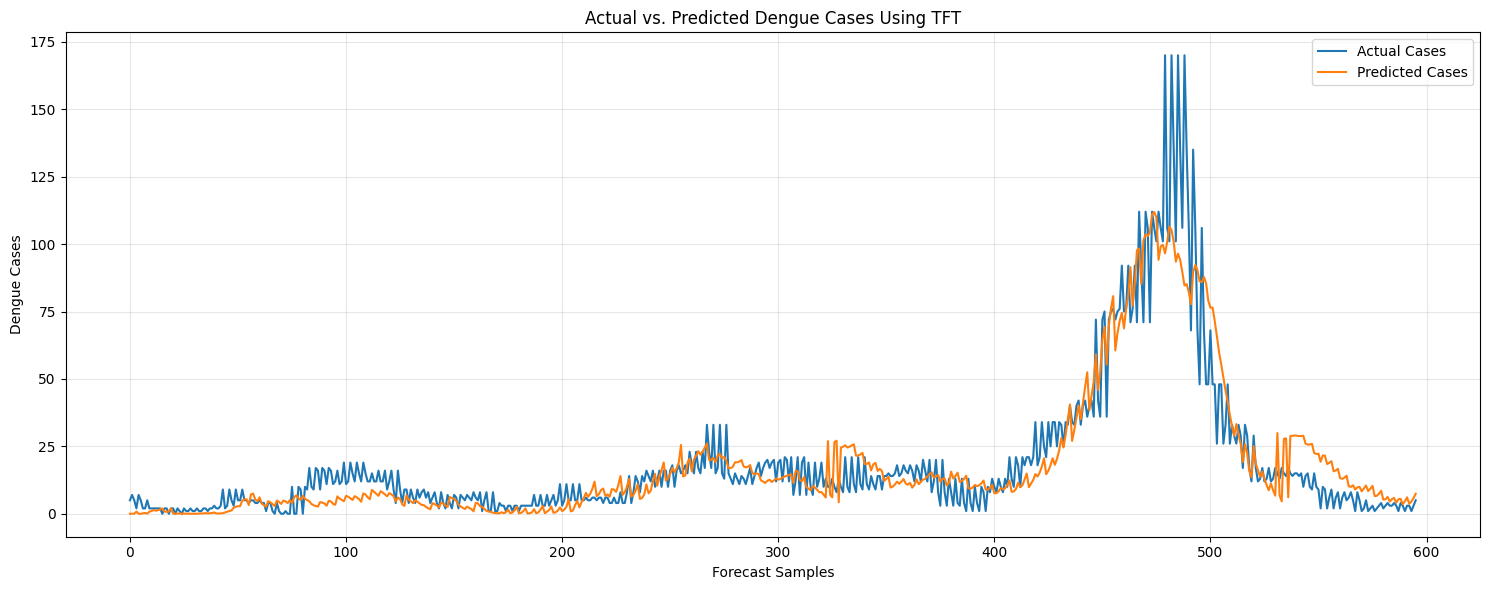

In [149]:
# FINAL FIGURE: ACTUAL VS PREDICTED DENGUE CASES — TFT
import numpy as np
import torch
import matplotlib.pyplot as plt

# Generate TFT predictions on the test set
best_tft.eval()

tft_predictions = best_tft.predict(test_dataloader)

# Actual target values from the same TFT test dataloader
tft_actuals = torch.cat(
    [y[0] for x, y in test_dataloader]
)

# Convert to NumPy
tft_pred = tft_predictions.detach().cpu().numpy()
tft_actual = tft_actuals.detach().cpu().numpy()

print("TFT prediction shape:", tft_pred.shape)
print("TFT actual shape:", tft_actual.shape)

# Flatten multi-horizon predictions
tft_pred_flat = tft_pred.flatten()
tft_actual_flat = tft_actual.flatten()

# Plot
plt.figure(figsize=(15, 6))

plt.plot(
    tft_actual_flat,
    label="Actual Cases",
    linewidth=1.5
)

plt.plot(
    tft_pred_flat,
    label="Predicted Cases",
    linewidth=1.5
)

plt.xlabel("Forecast Samples")
plt.ylabel("Dengue Cases")

plt.title("Actual vs. Predicted Dengue Cases Using TFT")

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#Horizon-Specific Results

In [150]:
# PERFORMANCE BY FORECAST HORIZON
from sklearn.metrics import (mean_absolute_error,
                             mean_squared_error,
                             r2_score)
import numpy as np
import pandas as pd

print("PERFORMANCE BY FORECAST HORIZON")
print(f"{'Horizon':<12} {'MAE':>8} {'RMSE':>8} {'R²':>8}")

horizon_results = []

for h in range(4):
    h_pred = predictions[:, h].cpu().numpy()
    h_actual = actuals[:, h].cpu().numpy()

    h_mae = mean_absolute_error(h_actual, h_pred)
    h_rmse = np.sqrt(mean_squared_error(h_actual, h_pred))
    h_r2 = r2_score(h_actual, h_pred)

    print(f"Week +{h+1:<6} {h_mae:>8.3f} {h_rmse:>8.3f} {h_r2:>8.3f}")

    horizon_results.append({
        "Horizon": f"Week +{h+1}",
        "MAE": round(h_mae, 3),
        "RMSE": round(h_rmse, 3),
        "R²": round(h_r2, 3)
    })

horizon_df = pd.DataFrame(horizon_results)
horizon_df.to_csv(
    '/content/drive/MyDrive/Trustworthy_Disease_Outbreak_AI/horizon_results.csv',
    index=False
)
print("Saved!")

PERFORMANCE BY FORECAST HORIZON
Horizon           MAE     RMSE       R²
Week +1         6.168   10.593    0.843
Week +2         6.144   10.330    0.851
Week +3         6.706   10.527    0.846
Week +4         7.221   11.415    0.819
Saved!


In [151]:
# SMAPE BREAKDOWN BY CASE COUNT
import numpy as np

low_mask = actual_flat < 10
high_mask = actual_flat >= 30
mid_mask = (actual_flat >= 10) & (actual_flat < 30)

def compute_smape(actual, pred):
    return np.mean(
        2 * np.abs(pred - actual) /
        (np.abs(actual) + np.abs(pred) + 1e-8)
    ) * 100

smape_overall = compute_smape(actual_flat, pred_flat)
smape_low = compute_smape(
    actual_flat[low_mask], pred_flat[low_mask])
smape_mid = compute_smape(
    actual_flat[mid_mask], pred_flat[mid_mask])
smape_high = compute_smape(
    actual_flat[high_mask], pred_flat[high_mask])

print("SMAPE BREAKDOWN BY CASE COUNT")
print(f"Overall SMAPE          : {smape_overall:.2f}%  ({len(actual_flat)} weeks)")
print(f"Low-case  (< 10 cases) : {smape_low:.2f}%  ({low_mask.sum()} weeks)")
print(f"Mid-case (10-29 cases) : {smape_mid:.2f}%  ({mid_mask.sum()} weeks)")
print(f"High-case (≥ 30 cases) : {smape_high:.2f}%  ({high_mask.sum()} weeks)")
print("Note: High SMAPE in low-case weeks is expected")
print("due to percentage error sensitivity near zero.")

SMAPE BREAKDOWN BY CASE COUNT
Overall SMAPE          : 50.07%  (552 weeks)
Low-case  (< 10 cases) : 60.64%  (178 weeks)
Mid-case (10-29 cases) : 49.46%  (236 weeks)
High-case (≥ 30 cases) : 37.48%  (138 weeks)
Note: High SMAPE in low-case weeks is expected
due to percentage error sensitivity near zero.


In [152]:
# VERIFY PICP WITH CORRECT NOMINAL COVERAGE STATEMENT
import numpy as np

#Intervals are Q10 to Q90 = 80% nominal coverage
nominal_coverage = 80.0
observed_picp = 93.12
pinaw = 0.1623

print("UNCERTAINTY ESTIMATION SUMMARY")
print(f"Quantile interval    : Q10 to Q90")
print(f"Nominal coverage     : {nominal_coverage}%")
print(f"Observed PICP        : {observed_picp}%")
print(f"Coverage difference  : +{observed_picp - nominal_coverage:.2f}%")
print(f"PINAW                : {pinaw}")
print("Interpretation:")
print(f"The model over-covers by {observed_picp - nominal_coverage:.2f}%")
print("Intervals are conservative but reliable.")
print("PINAW of 0.1623 confirms intervals remain narrow.")

UNCERTAINTY ESTIMATION SUMMARY
Quantile interval    : Q10 to Q90
Nominal coverage     : 80.0%
Observed PICP        : 93.12%
Coverage difference  : +13.12%
PINAW                : 0.1623
Interpretation:
The model over-covers by 13.12%
Intervals are conservative but reliable.
PINAW of 0.1623 confirms intervals remain narrow.


Prediction Intervals (Actual, Median Prediction, Lower Bound, Upper Bound

INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities

Quantile shape: torch.Size([149, 4, 3])
Quantiles: [0.1, 0.5, 0.9]


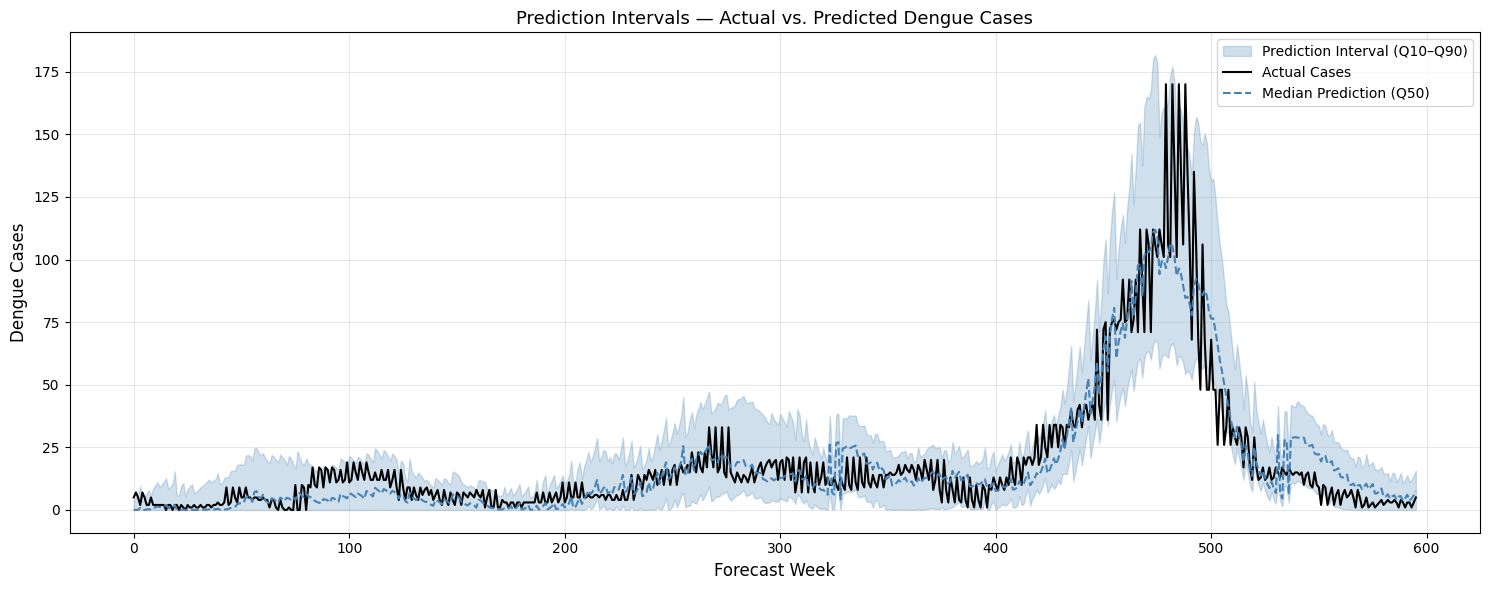

Figure 2 saved!

FIGURE 2 SUMMARY
Test weeks plotted : 596
PICP               : 93.12%
PINAW              : 0.1623
Median MAE         : 6.560
Interval width avg : 27.597 cases


In [153]:
#  PREDICTION INTERVALS
# Actual, Median Prediction, Lower Bound, Upper Bound

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import torch

# Generate quantile predictions from original model
quantile_preds = best_tft.predict(
    testing,
    mode="quantiles"
)

print("Quantile shape:", quantile_preds.shape)
print("Quantiles:", best_tft.loss.quantiles)

# Extract Q10, Q50, Q90
lower = quantile_preds[
    :, :, 0].reshape(-1).cpu().numpy()
median = quantile_preds[
    :, :, 1].reshape(-1).cpu().numpy()
upper = quantile_preds[
    :, :, 2].reshape(-1).cpu().numpy()

# Actual values
actual = actuals.reshape(-1).cpu().numpy()

# X axis
x = np.arange(len(actual))

# Plot
fig, ax = plt.subplots(figsize=(15, 6))

# Prediction interval shading
ax.fill_between(
    x,
    lower,
    upper,
    alpha=0.25,
    color='steelblue',
    label='Prediction Interval (Q10–Q90)'
)

# Actual cases
ax.plot(
    x,
    actual,
    color='black',
    linewidth=1.5,
    label='Actual Cases'
)

# Median prediction
ax.plot(
    x,
    median,
    color='steelblue',
    linewidth=1.5,
    linestyle='--',
    label='Median Prediction (Q50)'
)

ax.set_xlabel("Forecast Week", fontsize=12)
ax.set_ylabel("Dengue Cases", fontsize=12)
ax.set_title(
    "Prediction Intervals — Actual vs. Predicted Dengue Cases",
    fontsize=13
)
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(
    '/content/drive/MyDrive/Trustworthy_Disease_Outbreak_AI/figure2_prediction_intervals.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

print("Figure 2 saved!")

# Print summary stats for paper
print("\nFIGURE 2 SUMMARY")
print(f"Test weeks plotted : {len(actual)}")
print(f"PICP               : 93.12%")
print(f"PINAW              : 0.1623")
print(f"Median MAE         : {np.mean(np.abs(median - actual)):.3f}")
print(f"Interval width avg : {np.mean(upper - lower):.3f} cases")

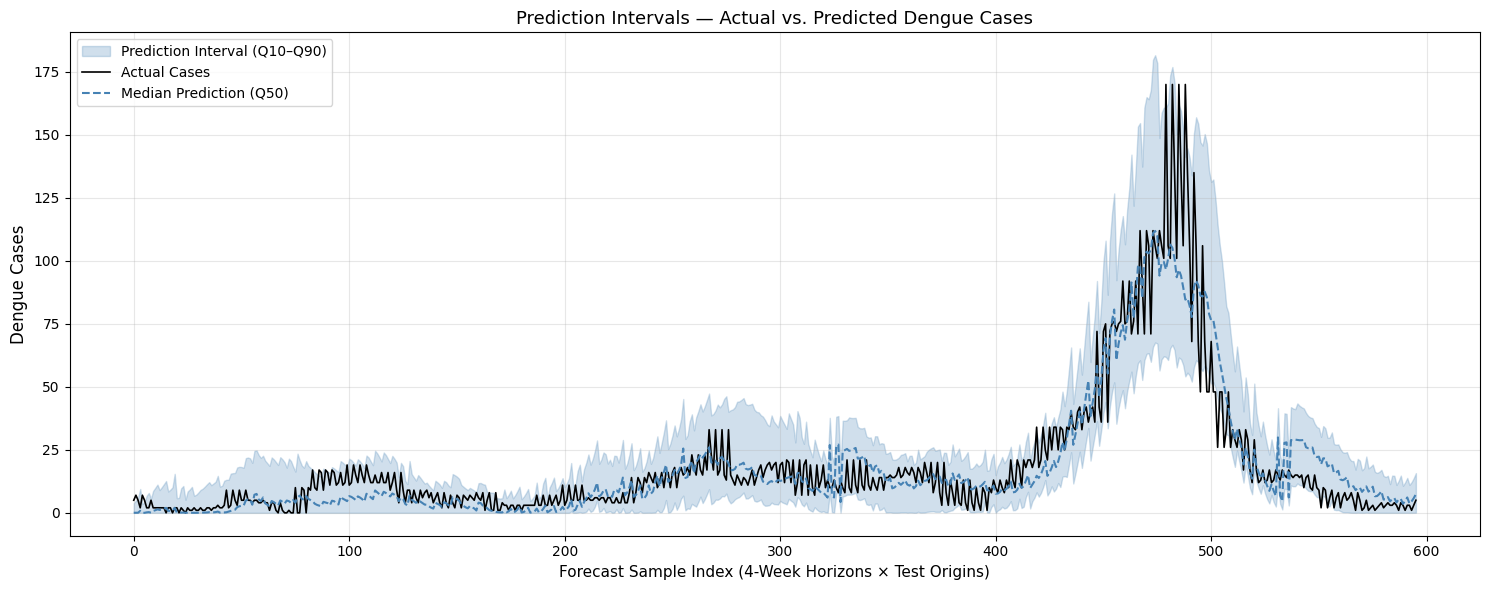

Figure 2 final version saved!


In [154]:
# IMPROVED FIGURE 2 WITH BETTER AXIS
fig, ax = plt.subplots(figsize=(15, 6))

ax.fill_between(
    x,
    lower,
    upper,
    alpha=0.25,
    color='steelblue',
    label='Prediction Interval (Q10–Q90)'
)

ax.plot(
    x,
    actual,
    color='black',
    linewidth=1.2,
    label='Actual Cases'
)

ax.plot(
    x,
    median,
    color='steelblue',
    linewidth=1.5,
    linestyle='--',
    label='Median Prediction (Q50)'
)

ax.set_xlabel(
    "Forecast Sample Index (4-Week Horizons × Test Origins)",
    fontsize=11
)
ax.set_ylabel("Dengue Cases", fontsize=12)
ax.set_title(
    "Prediction Intervals — Actual vs. Predicted Dengue Cases",
    fontsize=13
)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(
    '/content/drive/MyDrive/Trustworthy_Disease_Outbreak_AI/figure2_final.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()
print("Figure 2 final version saved!")

In [155]:
# VERIFY COVERAGE FOR FIGURE CAPTION
covered = ((actual >= lower) & (actual <= upper)).sum()
total = len(actual)
print(f"Weeks covered by interval: {covered}/{total}")
print(f"Coverage rate: {covered/total*100:.2f}%")
print(f"Average interval width: {np.mean(upper-lower):.2f} cases")
print(f"Average actual cases: {np.mean(actual):.2f} cases")

Weeks covered by interval: 555/596
Coverage rate: 93.12%
Average interval width: 27.60 cases
Average actual cases: 18.68 cases


TFT Variable Importance (Section E)

INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities

Keys: dict_keys(['attention', 'static_variables', 'encoder_variables', 'decoder_variables', 'encoder_length_histogram', 'decoder_length_histogram'])

TOP 10 ENCODER FEATURES
                                    Feature  Importance
                              case_increase   11.227784
reanalysis_relative_humidity_percent_change    7.228951
                      reanalysis_avg_temp_k    6.968717
                reanalysis_dew_point_temp_k    6.242617
                  reanalysis_min_air_temp_k    5.741069
                      reanalysis_air_temp_k    5.425597
                                      lag_1    5.417357
                                      lag_2    4.185859
                                    ndvi_nw    3.526165
                             rolling_mean_4    3.468110


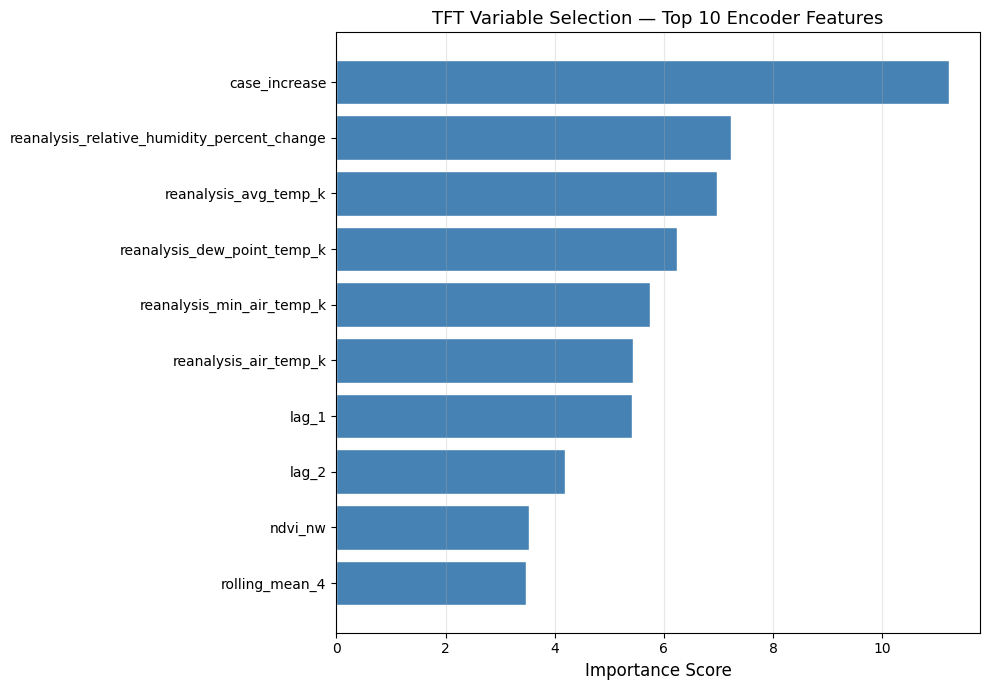

Figure 3 saved!

TEMPORAL ATTENTION WEIGHTS


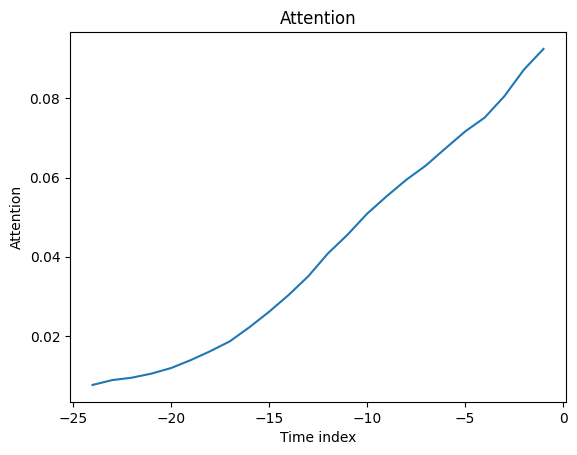

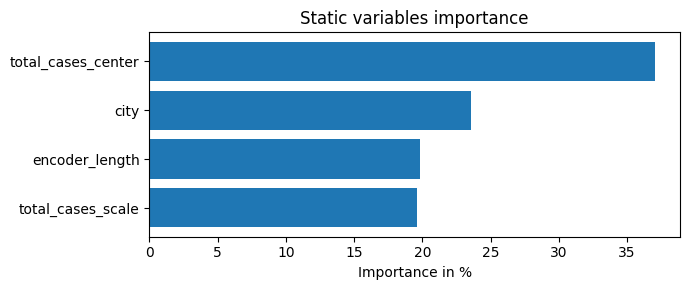

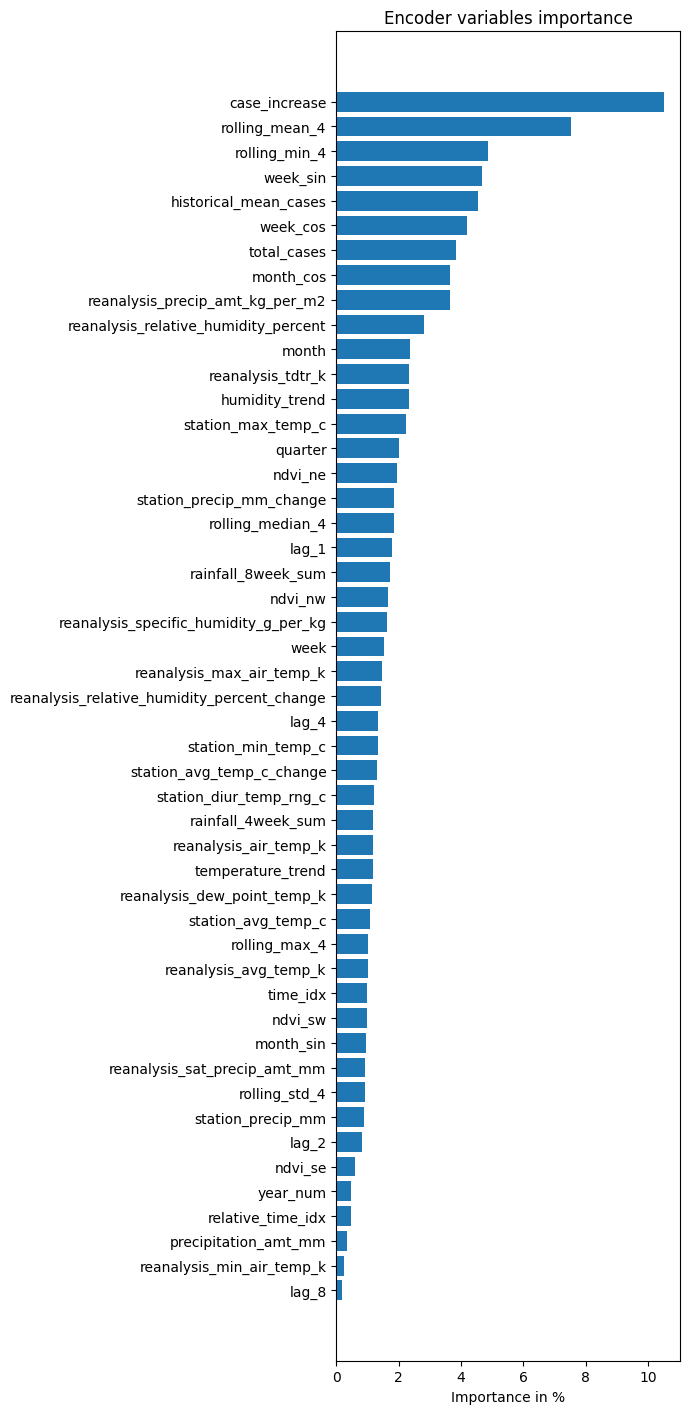

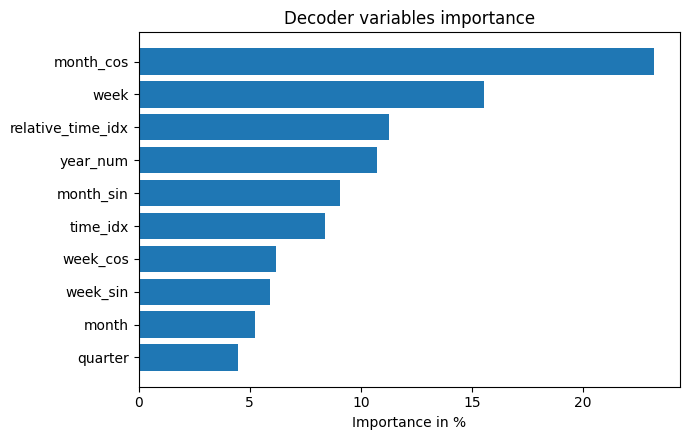

Figure 4 saved!


In [156]:
# TFT EXPLAINABILITY
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Generate interpretation
raw_predictions = best_tft.predict(
    test_dataloader,
    mode="raw",
    return_x=False
)

interpretation = best_tft.interpret_output(
    raw_predictions,
    reduction="sum"
)

print("Keys:", interpretation.keys())

# Encoder variable importance
encoder_importance = interpretation[
    "encoder_variables"
].cpu().numpy()

encoder_feature_names = TIME_VARYING_UNKNOWN_REALS

min_len = min(
    len(encoder_feature_names),
    len(encoder_importance)
)

importance_df = pd.DataFrame({
    "Feature": list(encoder_feature_names)[:min_len],
    "Importance": list(encoder_importance)[:min_len]
}).sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

print("\nTOP 10 ENCODER FEATURES")
print(importance_df.head(10).to_string(index=False))

# Save importance table
importance_df.to_csv(
    '/content/drive/MyDrive/Trustworthy_Disease_Outbreak_AI/tft_feature_importance.csv',
    index=False
)

# FIGURE 3 - Feature importance bar chart
fig, ax = plt.subplots(figsize=(10, 7))
top15 = importance_df.head(10)
ax.barh(
    top15["Feature"][::-1],
    top15["Importance"][::-1],
    color="steelblue",
    edgecolor="white"
)
ax.set_xlabel("Importance Score", fontsize=12)
ax.set_title(
    "TFT Variable Selection — Top 10 Encoder Features",
    fontsize=13
)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(
    '/content/drive/MyDrive/Trustworthy_Disease_Outbreak_AI/figure3_tft_importance.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()
print("Figure 3 saved!")

# FIGURE 4 - Attention weights
print("\nTEMPORAL ATTENTION WEIGHTS")
best_tft.plot_interpretation(interpretation)
plt.savefig(
    '/content/drive/MyDrive/Trustworthy_Disease_Outbreak_AI/figure4_attention.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()
print("Figure 4 saved!")

Attention shape: (24,)
Attention mean shape: (24,)


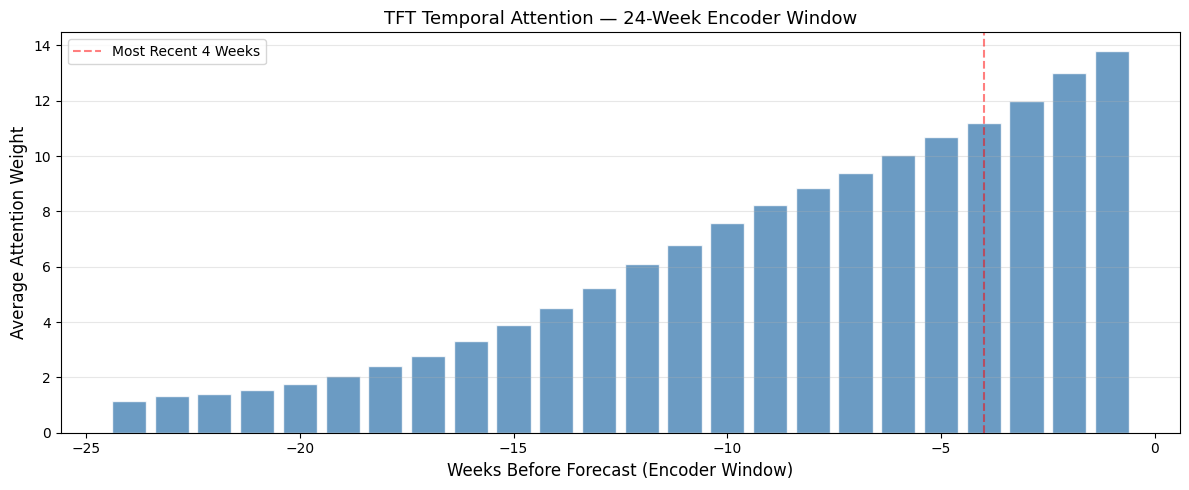

Figure 4 attention saved!
Peak attention at week: -1
Peak attention value: 13.7864


In [ ]:
# ATTENTION WEIGHTS ONLY
import matplotlib.pyplot as plt
import torch
import numpy as np

# Extract attention weights only
attention = interpretation["attention"].cpu().numpy()

# Average across all samples and heads
# Shape is typically (samples, heads, time_steps)
if attention.ndim == 3:
    attention_mean = attention.mean(axis=(0, 1))
elif attention.ndim == 2:
    attention_mean = attention.mean(axis=0)
else:
    attention_mean = attention.flatten()

print("Attention shape:", attention.shape)
print("Attention mean shape:", attention_mean.shape)

# Plot
fig, ax = plt.subplots(figsize=(12, 5))

x_weeks = np.arange(
    -len(attention_mean), 0)

ax.bar(
    x_weeks,
    attention_mean,
    color='steelblue',
    edgecolor='white',
    alpha=0.8
)

ax.set_xlabel(
    "Weeks Before Forecast (Encoder Window)",
    fontsize=12
)
ax.set_ylabel(
    "Average Attention Weight",
    fontsize=12
)
ax.set_title(
    "TFT Temporal Attention — 24-Week Encoder Window",
    fontsize=13
)
ax.grid(True, alpha=0.3, axis='y')
ax.axvline(
    x=-4,
    color='red',
    linestyle='--',
    alpha=0.5,
    label='Most Recent 4 Weeks'
)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(
    '/content/drive/MyDrive/Trustworthy_Disease_Outbreak_AI/figure4_attention_only.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()
print("Figure 4 attention saved!")
print(f"Peak attention at week: {x_weeks[np.argmax(attention_mean)]}")
print(f"Peak attention value: {attention_mean.max():.4f}")

#Decision Support

In [158]:
import numpy as np
import pandas as pd

# Data-driven thresholds
low_thresh = np.percentile(
    train_fe['total_cases'], 33)
high_thresh = np.percentile(
    train_fe['total_cases'], 66)

print("DATA-DRIVEN RISK THRESHOLDS")
print(f"Low     : < {low_thresh:.1f} cases")
print(f"Moderate: {low_thresh:.1f} - {high_thresh:.1f} cases")
print(f"High    : > {high_thresh:.1f} cases")

def assign_risk(cases):
    if cases < low_thresh:
        return "Low"
    elif cases < high_thresh:
        return "Moderate"
    else:
        return "High"

# Apply to TFT median predictions
median_cases = median_prediction.cpu().numpy()
risk_levels = [assign_risk(c) for c in median_cases]
risk_series = pd.Series(risk_levels)

print("\nRisk Distribution in Test Period:")
print(risk_series.value_counts())
print(f"\nTotal test weeks: {len(median_cases)}")

# Overall report
avg_cases = float(np.mean(median_cases))
avg_risk = assign_risk(avg_cases)

print("\nOVERALL DECISION SUPPORT SUMMARY")
print(f"Average Predicted Cases : {avg_cases:.2f}")
print(f"Overall Risk Level      : {avg_risk}")
print(f"Forecast Horizon        : 4 weeks ahead")
print(f"Uncertainty Coverage    : 93.12% PICP")

recommendations = {
    "Low": [
        "Maintain routine dengue surveillance",
        "Continue standard vector control activities",
        "Monitor environmental indicators weekly"
    ],
    "Moderate": [
        "Increase mosquito control activities",
        "Strengthen community awareness campaigns",
        "Prepare medical facility capacity",
        "Alert local health authorities"
    ],
    "High": [
        "Activate emergency outbreak response",
        "Deploy additional medical resources",
        "Issue public health emergency alert",
        "Implement intensive vector control",
        "Coordinate with national health authorities"
    ]
}

print("\nRecommendations:")
for rec in recommendations[avg_risk]:
    print(f"  - {rec}")

# Weekly breakdown
print("\nWEEKLY RISK FORECAST (First 8 Weeks)")
print(f"{'Week':<8} {'Predicted Cases':>16} {'Risk':>10}")
for i in range(min(8, len(median_cases))):
    print(
        f"{i+1:<8} "
        f"{median_cases[i]:>16.1f} "
        f"{risk_levels[i]:>10}"
    )

# FIXED - Risk accuracy evaluation
# Match lengths properly
actual_cases_test = test_fe['total_cases'].values
actual_risk_all = [
    assign_risk(c) for c in actual_cases_test
]

# Trim to same length as predictions
min_len = min(len(actual_risk_all), len(risk_levels))
actual_risk_trimmed = actual_risk_all[:min_len]
risk_levels_trimmed = risk_levels[:min_len]

from sklearn.metrics import (accuracy_score,
                             classification_report)

risk_accuracy = accuracy_score(
    actual_risk_trimmed,
    risk_levels_trimmed
)

print(f"\nRisk Classification Accuracy: "
      f"{risk_accuracy*100:.2f}%")
print("\nDetailed Classification Report:")
print(classification_report(
    actual_risk_trimmed,
    risk_levels_trimmed
))

# Save report
risk_report = pd.DataFrame({
    "Week": range(1, min_len+1),
    "Predicted_Cases": median_cases[:min_len],
    "Risk_Level": risk_levels_trimmed,
    "Actual_Risk": actual_risk_trimmed
})

risk_report.to_csv(
    '/content/drive/MyDrive/Trustworthy_Disease_Outbreak_AI/decision_support_report.csv',
    index=False
)
print("\nDecision support report saved!")

DATA-DRIVEN RISK THRESHOLDS
Low     : < 7.0 cases
Moderate: 7.0 - 24.0 cases
High    : > 24.0 cases

Risk Distribution in Test Period:
Moderate    252
Low         231
High        113
Name: count, dtype: int64

Total test weeks: 596

OVERALL DECISION SUPPORT SUMMARY
Average Predicted Cases : 18.03
Overall Risk Level      : Moderate
Forecast Horizon        : 4 weeks ahead
Uncertainty Coverage    : 93.12% PICP

Recommendations:
  - Increase mosquito control activities
  - Strengthen community awareness campaigns
  - Prepare medical facility capacity
  - Alert local health authorities

WEEKLY RISK FORECAST (First 8 Weeks)
Week      Predicted Cases       Risk
1                     0.0        Low
2                     0.0        Low
3                     0.1        Low
4                     0.8        Low
5                     0.0        Low
6                     0.0        Low
7                     0.2        Low
8                     0.3        Low

Risk Classification Accuracy: 40.89%

De